# Network — 가입자는 실제 관계망에 연결됐는가

정제된 바이럴·학교 확산 마트로 가입 후 친구요청과 관계망 편입을 분석한다.

- 학교별 40번째 가입일을 기능 활성화 기준일 D0로 사용한다.
- 요청 상태는 추출 시점의 최종 상태이며 요청 당시 상태가 아니다.
- 학교·학년·반·친구 수는 현재 스냅샷이다.
- 친구요청은 가입 이후 행동이므로 초대 전환이나 K-Factor로 해석하지 않는다.


In [1]:
from pathlib import Path
from collections import deque
import json
import math
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from scipy.sparse.linalg import eigsh
from scipy.special import expit
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
COLORS = {"navy": "#244A73", "blue": "#4E83B6", "orange": "#F28E5B", "green": "#4E9F78", "gray": "#8A96A3", "red": "#C94C4C"}

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path("C:/Users/lucy5/Desktop/team7")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "viral_school").exists():
            return candidate.resolve()
    raise FileNotFoundError("data/processed/viral_school 폴더를 찾을 수 없습니다.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "viral_school"
ANALYSIS_DIR = PROJECT_ROOT / "analysis" / "network_deep_dive"
OUTPUT_DIR = ANALYSIS_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "event": DATA_DIR / "mart_friend_request_event_v2_clean.csv.gz",
    "pair": DATA_DIR / "mart_friend_request_pair_summary_v2_clean.csv.gz",
    "school_daily": DATA_DIR / "mart_school_viral_daily_v2_clean.csv.gz",
    "acquisition": DATA_DIR / "mart_user_acquisition_profile_v2_clean.csv.gz",
    "contact": DATA_DIR / "mart_user_contact_record_v2_clean.csv.gz",
    "profile": DATA_DIR / "mart_user_viral_profile_v2_clean.csv.gz",
}
missing = [str(p) for p in FILES.values() if not p.exists()]
assert not missing, f"누락 파일: {missing}"

con = duckdb.connect()
con.execute("SET threads=8")
con.execute("SET memory_limit='12GB'")
con.execute("PRAGMA disable_progress_bar")

def csv_sql(path):
    return f"read_csv_auto('{path.as_posix()}', header=true, sample_size=200000, nullstr='\\N')"

for name, path in FILES.items():
    con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM {csv_sql(path)}")

def show(df, n=20):
    display(df.head(n).round(4))
    return df

def save_table(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=160)
    plt.show()
    return path

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"결과 저장 폴더: {OUTPUT_DIR}")

프로젝트 루트: C:\Users\lucy5\Desktop\team7
결과 저장 폴더: C:\Users\lucy5\Desktop\team7\analysis\network_deep_dive\outputs


## 1. 분석 범위와 데이터 품질

사용자·학교·친구요청의 모집단, 기간, 키 품질을 확인한다.


In [2]:
scope = con.execute('''
SELECT '사용자 프로필' AS object,
       COUNT(*) AS row_count,
       SUM(analysis_eligible_nonstaff_flag) AS eligible_count,
       MIN(signup_at) AS min_datetime,
       MAX(signup_at) AS max_datetime,
       COUNT(DISTINCT TRY_CAST(current_school_id AS BIGINT)) AS school_count
FROM profile
UNION ALL
SELECT '친구요청 이벤트', COUNT(*), SUM(analysis_eligible_request_flag),
       MIN(request_created_at_raw), MAX(request_created_at_raw),
       COUNT(DISTINCT sender_current_school_id)
FROM event
UNION ALL
SELECT '학교×일 패널', COUNT(*), SUM(analysis_eligible_school_day_flag),
       MIN(activity_date), MAX(activity_date), COUNT(DISTINCT school_id)
FROM school_daily
UNION ALL
SELECT '연락처 스냅샷', COUNT(*), SUM(analysis_eligible_nonstaff_flag),
       NULL, NULL, COUNT(DISTINCT contact_owner_current_school_id)
FROM contact
''').fetchdf()

qa = con.execute('''
SELECT
    COUNT(*) AS request_rows,
    SUM(self_request_flag) AS self_requests,
    SUM(CASE WHEN status_code_valid_flag <> 1 THEN 1 ELSE 0 END) AS invalid_status,
    SUM(CASE WHEN request_timestamp_valid_flag <> 1 THEN 1 ELSE 0 END) AS invalid_timestamp,
    SUM(CASE WHEN negative_update_interval_flag = 1 THEN 1 ELSE 0 END) AS negative_update_interval,
    SUM(CASE WHEN sender_known_user_flag <> 1 OR receiver_known_user_flag <> 1 THEN 1 ELSE 0 END) AS unknown_endpoint,
    SUM(CASE WHEN analysis_eligible_request_flag = 1 THEN 1 ELSE 0 END) AS eligible_requests
FROM event
''').fetchdf()

reached = con.execute('''
SELECT
    COUNT(DISTINCT school_id) AS observed_schools,
    COUNT(DISTINCT CASE WHEN current_roster_reached_40_flag = 1 THEN school_id END) AS reached_40_schools,
    MIN(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS first_d0,
    MAX(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS last_d0
FROM school_daily
''').fetchdf()

save_table(scope, "01_scope_summary.csv")
save_table(qa, "01_request_qa_summary.csv")
save_table(reached, "01_school_d0_summary.csv")
display(scope)
display(qa)
display(reached)

,object,row_count,eligible_count,min_datetime,max_datetime,school_count
0,사용자 프로필,677085,"677,081.0000",2023-03-29 03:44:14.047130,2024-05-09 08:31:17.710824,5551
1,친구요청 이벤트,17147175,"17,147,175.0000",2023-04-17 18:29:11.000000,2024-05-09 09:21:47.000000,5404
2,학교×일 패널,2428008,"2,052,369.0000",2023-03-29 00:00:00.000000,2024-05-09 00:00:00.000000,5951
3,연락처 스냅샷,5063,"5,063.0000",NaT,NaT,10


,request_rows,self_requests,invalid_status,invalid_timestamp,negative_update_interval,unknown_endpoint,eligible_requests
0,17147175,0.0000,0.0000,0.0000,0.0000,0.0000,"17,147,175.0000"


,observed_schools,reached_40_schools,first_d0,last_d0
0,5951,3896,2023-04-19 06:20:07.938133,2023-09-28 09:15:43.538435


### 분석 기준

- 직원·운영 계정을 제외한다.
- 학교 비교는 현재 학교가 확인되는 사용자와 요청을 사용한다.
- D0 전후 분석은 양쪽 관측기간이 확보된 학교만 포함한다.
- 요청 상태는 최종 수락 상태로 표현한다.


## 2. 가입과 친구요청 시계열

가입 급증과 친구요청이 같은 시기에 움직였는지 확인한다.


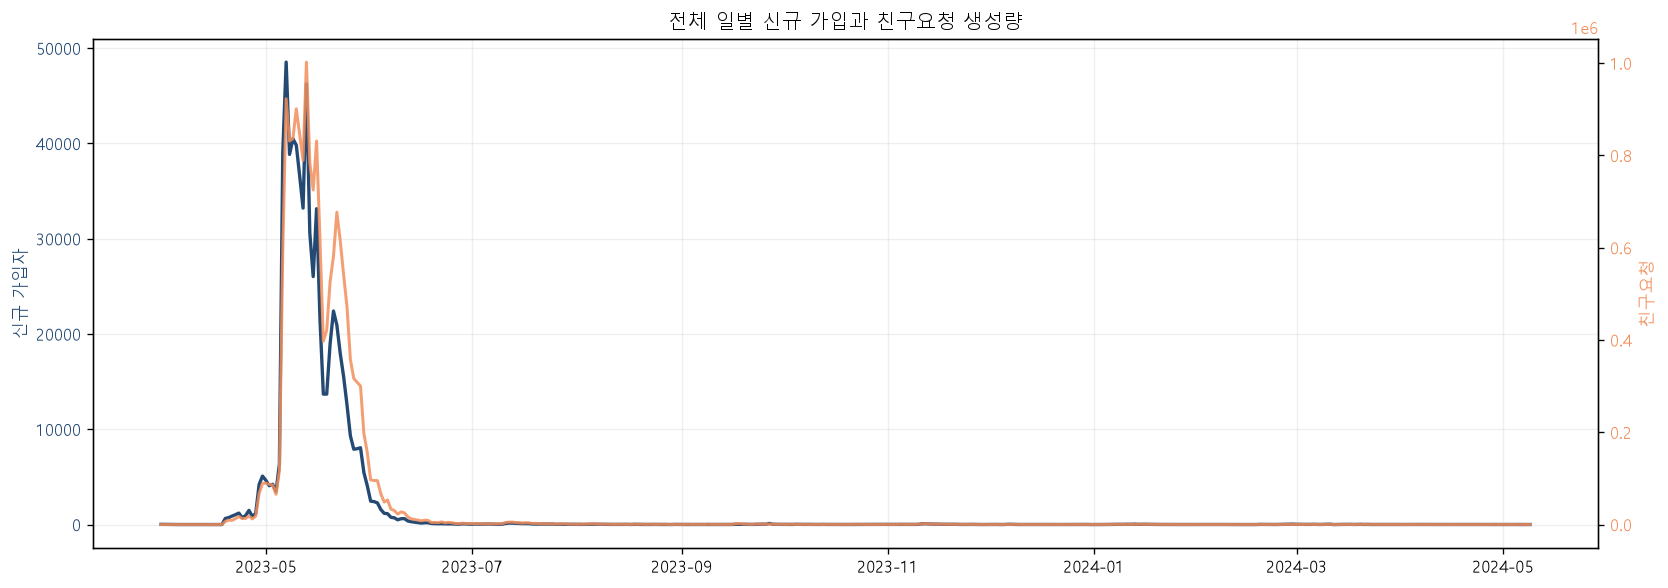

5월 신규 가입: 635,478명
5월 친구요청: 15,989,482건
일별 신규 가입과 친구요청 Spearman ρ: 0.916


In [3]:
daily = con.execute('''
SELECT CAST(activity_date AS DATE) AS activity_date,
       SUM(new_nonstaff_account_count_current_roster) AS new_users,
       SUM(sent_request_created_count) AS sent_requests,
       SUM(sent_request_user_count) AS sender_days,
       SUM(sent_within_school_count_current) AS within_school_requests,
       SUM(sent_created_final_accepted_count) AS eventual_accepted_requests
FROM school_daily
WHERE analysis_eligible_school_day_flag = 1
GROUP BY 1
ORDER BY 1
''').fetchdf()
daily["activity_date"] = pd.to_datetime(daily["activity_date"])
daily["same_school_share"] = daily["within_school_requests"] / daily["sent_requests"].replace(0, np.nan)
daily["eventual_acceptance_share"] = daily["eventual_accepted_requests"] / daily["sent_requests"].replace(0, np.nan)
save_table(daily, "02_global_daily_network.csv")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily.activity_date, daily.new_users, color=COLORS["navy"], lw=2, label="신규 가입자")
ax1.set_ylabel("신규 가입자", color=COLORS["navy"])
ax1.tick_params(axis="y", labelcolor=COLORS["navy"])
ax2 = ax1.twinx()
ax2.plot(daily.activity_date, daily.sent_requests, color=COLORS["orange"], lw=1.8, alpha=.85, label="친구요청")
ax2.set_ylabel("친구요청", color=COLORS["orange"])
ax2.tick_params(axis="y", labelcolor=COLORS["orange"])
ax1.set_title("전체 일별 신규 가입과 친구요청 생성량")
ax1.grid(alpha=.2)
savefig("02_signup_and_friend_request_daily.png")

may = daily[daily.activity_date.between("2023-05-01", "2023-05-31")]
print(f"5월 신규 가입: {may.new_users.sum():,.0f}명")
print(f"5월 친구요청: {may.sent_requests.sum():,.0f}건")
print(f"일별 신규 가입과 친구요청 Spearman ρ: {stats.spearmanr(daily.new_users, daily.sent_requests, nan_policy='omit').statistic:.3f}")

## 3. 관계 활성화 퍼널

가입자 중 요청 발송·수신·최종 수락 상태를 경험한 사용자 비중을 확인한다.


,stage,users,share_of_users
0,분석 가능 가입자,"677,081.0000",1.0000
1,요청 발송 또는 수신,"673,705.0000",0.9950
2,요청 발송,"649,072.0000",0.9586
3,요청 수신,"660,841.0000",0.9760
4,발송 요청 최종 수락 경험,"640,672.0000",0.9462
5,수신 요청 최종 수락 경험,"560,506.0000",0.8278


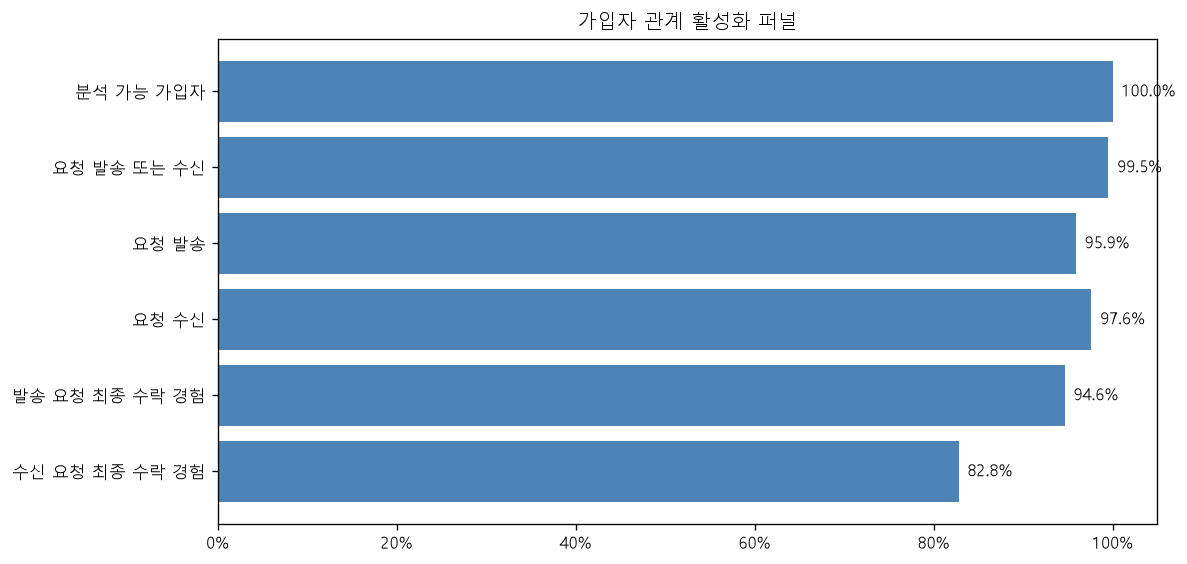

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/03_user_network_funnel.png')

In [4]:
funnel = con.execute('''
WITH p AS (
    SELECT * FROM profile WHERE analysis_eligible_nonstaff_flag = 1
)
SELECT '분석 가능 가입자' AS stage, COUNT(*) AS users FROM p
UNION ALL SELECT '요청 발송 또는 수신', SUM(has_any_friend_request_activity_flag) FROM p
UNION ALL SELECT '요청 발송', SUM(CASE WHEN sent_request_count > 0 THEN 1 ELSE 0 END) FROM p
UNION ALL SELECT '요청 수신', SUM(CASE WHEN received_request_count > 0 THEN 1 ELSE 0 END) FROM p
UNION ALL SELECT '발송 요청 최종 수락 경험', SUM(CASE WHEN sent_final_accepted_count > 0 THEN 1 ELSE 0 END) FROM p
UNION ALL SELECT '수신 요청 최종 수락 경험', SUM(CASE WHEN received_final_accepted_count > 0 THEN 1 ELSE 0 END) FROM p
''').fetchdf()
funnel["share_of_users"] = funnel.users / funnel.loc[funnel.stage.eq("분석 가능 가입자"), "users"].iloc[0]
save_table(funnel, "03_user_network_funnel.csv")
display(funnel.round(4))

plt.figure(figsize=(10, 4.8))
order = funnel.iloc[::-1]
plt.barh(order.stage, order.share_of_users, color=COLORS["blue"])
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.xlim(0, 1.05)
for y, v in enumerate(order.share_of_users):
    plt.text(v + .01, y, f"{v:.1%}", va="center")
plt.title("가입자 관계 활성화 퍼널")
savefig("03_user_network_funnel.png")

## 4. 가입 후 첫 관계 행동

가입 후 첫 요청 발송과 수신까지 걸린 시간을 측정한다.


,metric,all_eligible_users,observed_users,ever_observed_share,within_1min_all_users,within_5min_all_users,within_1h_all_users,within_24h_all_users,median_minutes,p90_hours,p99_hours
0,가입→첫 요청 발송,677081,649072,0.9586,0.8000,0.8598,0.8795,0.9085,0.2377,0.1061,218.9537
1,가입→첫 요청 수신,677081,660841,0.9760,0.0591,0.1920,0.5300,0.8645,44.6922,27.1777,290.5110


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


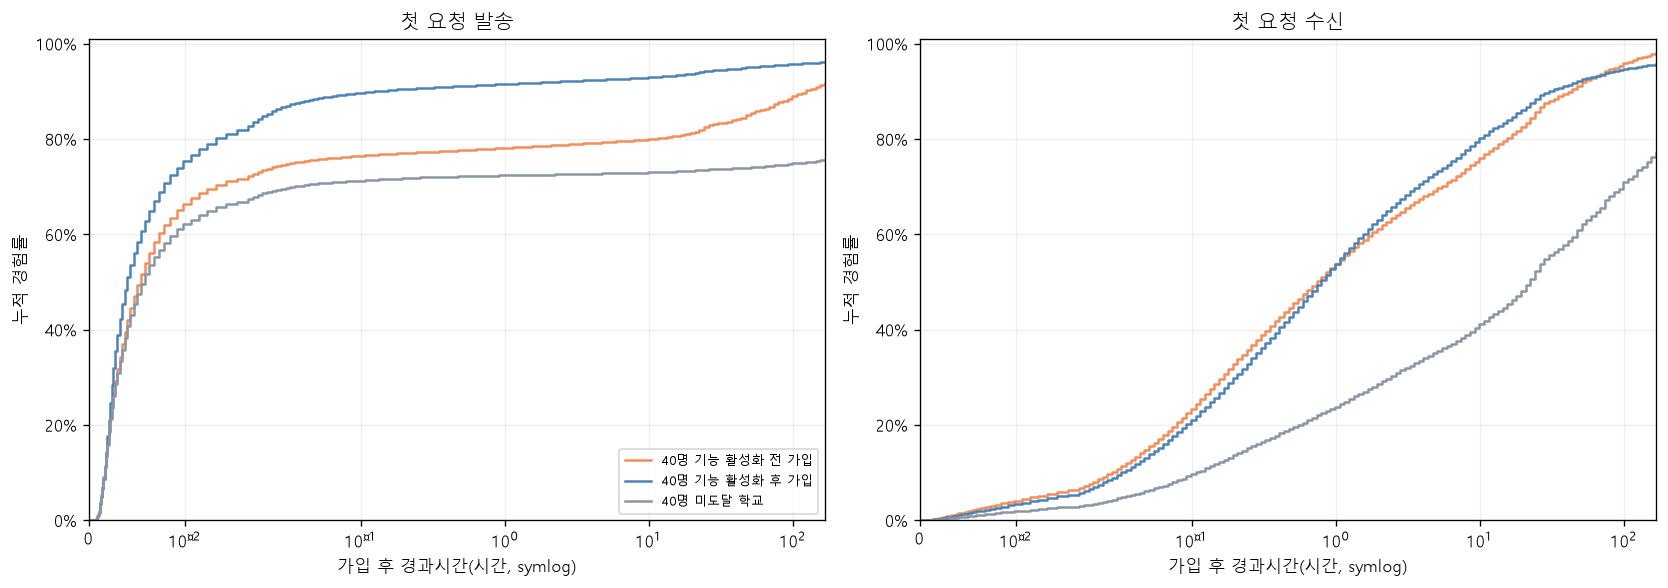

,metric,logrank_chi2,p_value,pre_40_7d_experience_rate,post_40_7d_experience_rate,post_minus_pre_difference_pp,difference_ci_low_pp,difference_ci_high_pp
0,first_sent_hours,"10,766.5393",0.0000,0.9170,0.9616,4.4615,4.3130,4.6100
1,first_received_hours,4.3322,0.0374,0.9804,0.9572,-2.3238,-2.4132,-2.2345


In [5]:
timing = con.execute('''
SELECT
    user_id,
    signup_at,
    TRY_CAST(first_sent_request_at_raw AS TIMESTAMP) AS first_sent_at,
    TRY_CAST(first_received_request_at_raw AS TIMESTAMP) AS first_received_at,
    TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS school_d0,
    CASE
        WHEN TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) IS NULL THEN 'SCHOOL_NOT_OBSERVED_REACHED_40'
        WHEN signup_at < TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) THEN 'BEFORE_OBSERVED_40TH'
        ELSE 'ON_OR_AFTER_OBSERVED_40TH'
    END AS signup_observed_40_phase,
    sent_request_count,
    received_request_count,
    sent_request_first_24h_count,
    sent_request_first_72h_count,
    sent_request_first_7d_count,
    received_request_first_24h_count,
    received_request_first_72h_count,
    received_request_first_7d_count
FROM profile
WHERE analysis_eligible_nonstaff_flag = 1
''').fetchdf()
for col in ["signup_at", "first_sent_at", "first_received_at", "school_d0"]:
    timing[col] = pd.to_datetime(timing[col], errors="coerce")
timing["first_sent_hours"] = (timing.first_sent_at - timing.signup_at).dt.total_seconds() / 3600
timing["first_received_hours"] = (timing.first_received_at - timing.signup_at).dt.total_seconds() / 3600
timing["phase_label"] = timing.signup_observed_40_phase.map({
    "BEFORE_OBSERVED_40TH": "40명 기능 활성화 전 가입",
    "ON_OR_AFTER_OBSERVED_40TH": "40명 기능 활성화 후 가입",
    "SCHOOL_NOT_OBSERVED_REACHED_40": "40명 미도달 학교",
    "NO_CURRENT_SCHOOL": "학교 없음",
})

def timing_summary(series, label):
    valid = series[series.ge(0)].dropna()
    return {
        "metric": label,
        "all_eligible_users": len(series),
        "observed_users": len(valid),
        "ever_observed_share": len(valid)/len(series),
        "within_1min_all_users": series.ge(0).mul(series.le(1/60)).mean(),
        "within_5min_all_users": series.ge(0).mul(series.le(5/60)).mean(),
        "within_1h_all_users": series.ge(0).mul(series.le(1)).mean(),
        "within_24h_all_users": series.ge(0).mul(series.le(24)).mean(),
        "median_minutes": valid.median() * 60,
        "p90_hours": valid.quantile(.9),
        "p99_hours": valid.quantile(.99),
    }

speed_summary = pd.DataFrame([
    timing_summary(timing.first_sent_hours, "가입→첫 요청 발송"),
    timing_summary(timing.first_received_hours, "가입→첫 요청 수신"),
])
save_table(speed_summary, "04_first_network_action_speed.csv")
display(speed_summary.round(4))

def km_curve(durations, observed, horizon=168):
    # 모든 사용자의 행정적 검열 시점이 7일로 동일하므로 고정 격자 누적발생률은 KM과 동일하다.
    raw = np.asarray(durations, float)
    e = np.asarray(observed, bool) & np.isfinite(raw) & (raw >= 0) & (raw <= horizon)
    grid = np.unique(np.r_[0, np.geomspace(1/3600, horizon, 180)])
    incidence = np.array([np.mean(e & (raw <= t)) for t in grid])
    return pd.DataFrame({"hours": grid, "survival": 1-incidence})

def logrank_test(t1, e1, t2, e2, horizon=168):
    raw1, raw2 = np.asarray(t1, float), np.asarray(t2, float)
    e1 = np.asarray(e1, bool) & np.isfinite(raw1) & (raw1 >= 0) & (raw1 <= horizon)
    e2 = np.asarray(e2, bool) & np.isfinite(raw2) & (raw2 >= 0) & (raw2 <= horizon)
    t1 = np.where(e1, raw1, horizon); t2 = np.where(e2, raw2, horizon)
    ev1, d1c = np.unique(t1[e1], return_counts=True)
    ev2, d2c = np.unique(t2[e2], return_counts=True)
    times = np.union1d(ev1, ev2)
    d1 = np.zeros(len(times)); d2 = np.zeros(len(times))
    d1[np.searchsorted(times, ev1)] = d1c
    d2[np.searchsorted(times, ev2)] = d2c
    s1, s2 = np.sort(t1), np.sort(t2)
    n1 = len(s1) - np.searchsorted(s1, times, side="left")
    n2 = len(s2) - np.searchsorted(s2, times, side="left")
    n, d = n1+n2, d1+d2
    valid = n > 1
    expected1 = np.divide(d*n1, n, out=np.zeros_like(d), where=n>0)
    variance = np.divide(n1*n2*d*(n-d), n*n*(n-1), out=np.zeros_like(d), where=valid)
    oe = np.sum((d1-expected1)[valid]); var = np.sum(variance[valid])
    chi2 = oe*oe/var if var > 0 else np.nan
    return chi2, stats.chi2.sf(chi2, 1) if np.isfinite(chi2) else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phase_order = ["40명 기능 활성화 전 가입", "40명 기능 활성화 후 가입", "40명 미도달 학교"]
for ax, col, title in zip(axes, ["first_sent_hours", "first_received_hours"], ["첫 요청 발송", "첫 요청 수신"]):
    for phase, color in zip(phase_order, [COLORS["orange"], COLORS["blue"], COLORS["gray"]]):
        sub = timing[timing.phase_label.eq(phase)]
        durations = sub[col].fillna(168).clip(lower=0)
        observed = sub[col].notna() & sub[col].ge(0)
        km = km_curve(durations, observed, 168)
        ax.step(km.hours, 1-km.survival, where="post", label=phase, color=color)
    ax.set_xscale("symlog", linthresh=1/60)
    ax.set_xlim(0, 168)
    ax.set_ylim(0, 1.01)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("가입 후 경과시간(시간, symlog)")
    ax.set_ylabel("누적 경험률")
    ax.set_title(title)
    ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
savefig("04_time_to_first_network_action_km.png")

tests = []
def proportion_diff_ci(x1,n1,x2,n2):
    p1,p2=x1/n1,x2/n2
    se=np.sqrt(p1*(1-p1)/n1+p2*(1-p2)/n2)
    diff=p2-p1
    return diff,diff-1.96*se,diff+1.96*se
for col in ["first_sent_hours", "first_received_hours"]:
    a = timing[timing.phase_label.eq("40명 기능 활성화 전 가입")]
    b = timing[timing.phase_label.eq("40명 기능 활성화 후 가입")]
    ta, ea = a[col].fillna(168).clip(lower=0), a[col].notna() & a[col].ge(0)
    tb, eb = b[col].fillna(168).clip(lower=0), b[col].notna() & b[col].ge(0)
    chi2, p = logrank_test(ta, ea, tb, eb)
    x1=int((ea & ta.le(168)).sum()); x2=int((eb & tb.le(168)).sum())
    diff,lo,hi=proportion_diff_ci(x1,len(a),x2,len(b))
    tests.append({"metric": col, "logrank_chi2": chi2, "p_value": p,
                  "pre_40_7d_experience_rate": x1/len(a),
                  "post_40_7d_experience_rate": x2/len(b),
                  "post_minus_pre_difference_pp":100*diff,
                  "difference_ci_low_pp":100*lo,"difference_ci_high_pp":100*hi})
timing_tests = pd.DataFrame(tests)
save_table(timing_tests, "04_time_to_first_action_logrank.csv")
display(timing_tests)

## 5. 관계 활동 분포와 집중도

사용자별 요청 수, 고유 상대 수, 현재 친구 수와 집중도를 확인한다.


,metric,mean,median,p90,p99,gini,top_1pct_share,top_10pct_share
0,sent_request_count,25.3251,20.0000,52.0000,107.0000,0.4467,0.0578,0.3014
1,received_request_count,25.3251,21.0000,52.0000,84.0000,0.4229,0.0384,0.2627
2,sent_unique_partner_count,25.1642,20.0000,52.0000,105.0000,0.4448,0.0564,0.2992
3,current_friend_list_length,53.3280,49.0000,94.0000,152.0000,0.3207,0.0351,0.2242


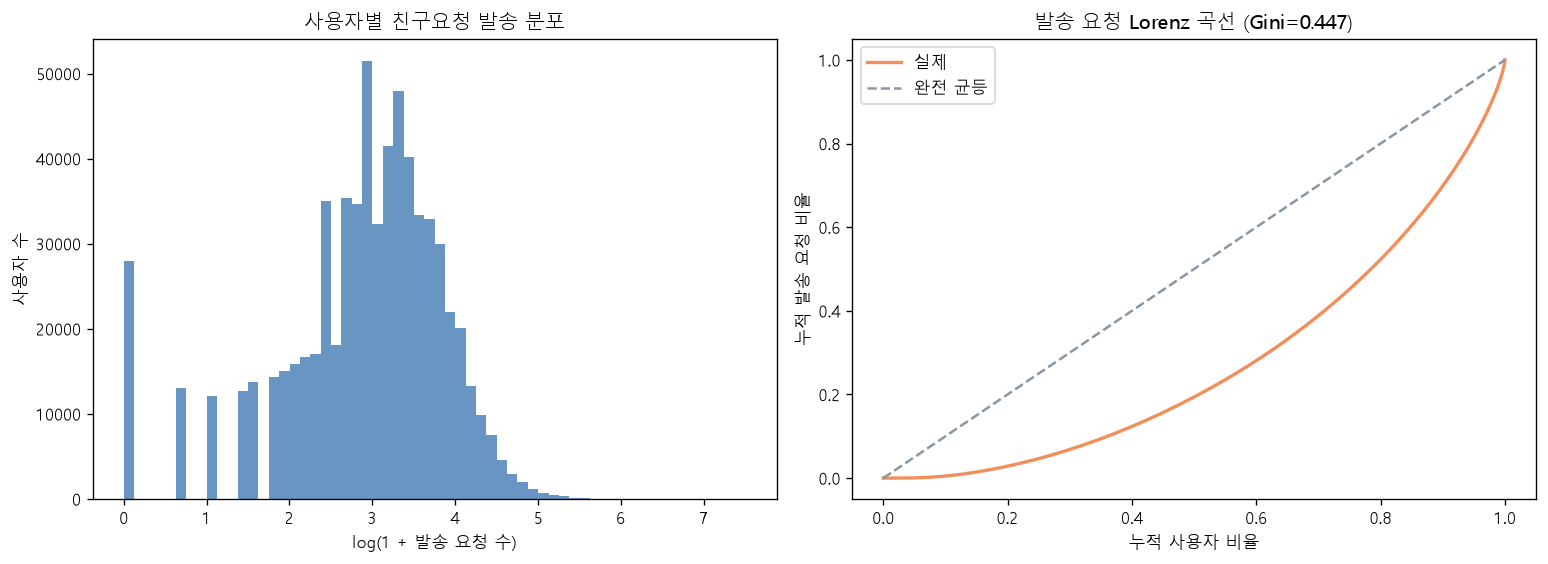

,repeated_directional_pair_flag,directional_pairs,request_records,final_accepted_records,same_school_records,record_share,eventual_acceptance_share
0,0,16965195,"16,965,195.0000","12,856,995.0000","13,475,073.0000",0.9894,0.7578
1,1,73039,"181,980.0000","21,412.0000","144,928.0000",0.0106,0.1177


In [6]:
user_network = con.execute('''
SELECT user_id,
       sent_request_count, received_request_count,
       sent_unique_partner_count, received_unique_partner_count,
       sent_repeated_request_count,
       sent_final_accepted_count, received_final_accepted_count,
       current_friend_list_length,
       TRY_CAST(current_school_id AS BIGINT) AS current_school_id,
       current_school_type
FROM profile
WHERE analysis_eligible_nonstaff_flag = 1
''').fetchdf()

def gini(values):
    x = np.asarray(values, float)
    x = x[np.isfinite(x) & (x >= 0)]
    if len(x) == 0 or x.sum() == 0: return np.nan
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n+1)) * x) / (n*x.sum())) - (n+1)/n

def top_share(values, frac):
    x = np.sort(np.asarray(values, float))[::-1]
    k = max(1, int(np.ceil(len(x)*frac)))
    return x[:k].sum()/x.sum() if x.sum() else np.nan

concentration = []
for col in ["sent_request_count", "received_request_count", "sent_unique_partner_count", "current_friend_list_length"]:
    s = user_network[col].fillna(0)
    concentration.append({
        "metric": col, "mean": s.mean(), "median": s.median(), "p90": s.quantile(.9), "p99": s.quantile(.99),
        "gini": gini(s), "top_1pct_share": top_share(s, .01), "top_10pct_share": top_share(s, .10)
    })
concentration = pd.DataFrame(concentration)
save_table(concentration, "05_network_concentration.csv")
display(concentration.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(np.log1p(user_network.sent_request_count), bins=60, color=COLORS["blue"], alpha=.85)
axes[0].set_xlabel("log(1 + 발송 요청 수)")
axes[0].set_ylabel("사용자 수")
axes[0].set_title("사용자별 친구요청 발송 분포")

x = np.sort(user_network.sent_request_count.fillna(0).to_numpy(float))
lorenz = np.r_[0, np.cumsum(x)/x.sum()]
population = np.linspace(0, 1, len(lorenz))
axes[1].plot(population, lorenz, color=COLORS["orange"], lw=2, label="실제")
axes[1].plot([0,1], [0,1], "--", color=COLORS["gray"], label="완전 균등")
axes[1].set_xlabel("누적 사용자 비율")
axes[1].set_ylabel("누적 발송 요청 비율")
axes[1].set_title(f"발송 요청 Lorenz 곡선 (Gini={gini(x):.3f})")
axes[1].legend()
savefig("05_request_distribution_and_lorenz.png")

repeated = con.execute('''
SELECT
    repeated_directional_pair_flag,
    COUNT(*) AS directional_pairs,
    SUM(request_record_count) AS request_records,
    SUM(final_accepted_record_count) AS final_accepted_records,
    SUM(CASE WHEN same_school_current_flag = 1 THEN request_record_count ELSE 0 END) AS same_school_records
FROM pair
WHERE analysis_eligible_pair_flag = 1
GROUP BY 1 ORDER BY 1
''').fetchdf()
repeated["record_share"] = repeated.request_records / repeated.request_records.sum()
repeated["eventual_acceptance_share"] = repeated.final_accepted_records / repeated.request_records
save_table(repeated, "05_repeated_directional_pairs.csv")
display(repeated)

## 6. 동일 학교 관계와 최종 상태

현재 학교 기준 동일 학교·학교 간 요청의 최종 상태를 비교한다.


,school_relation,final_status_code,final_status_label,requests,median_last_update_seconds,p90_last_update_seconds,within_relation_share
0,현재 다른 학교,A,FINAL_ACCEPTED,2498585,"26,579.0000","340,066.0000",0.7084
1,현재 다른 학교,P,FINAL_PENDING,926078,0.0000,0.0000,0.2626
2,현재 다른 학교,R,FINAL_REJECTED,102511,"50,989.0000","515,031.0000",0.0291
3,현재 동일 학교,A,FINAL_ACCEPTED,10379822,"18,646.0000","297,070.0000",0.7621
4,현재 동일 학교,P,FINAL_PENDING,3012530,0.0000,0.0000,0.2212
5,현재 동일 학교,R,FINAL_REJECTED,227649,"47,504.0000","577,117.6000",0.0167


,comparison,chi2,p_value,cramers_v,acceptance_odds_ratio,or_ci_low,or_ci_high,same_school_acceptance_share,cross_school_acceptance_share,risk_difference_pp
0,현재 동일 학교 vs 다른 학교의 최종 수락 상태,"53,830.0896",0.0000,0.0560,1.3188,1.3153,1.3222,0.7621,0.7084,5.3720


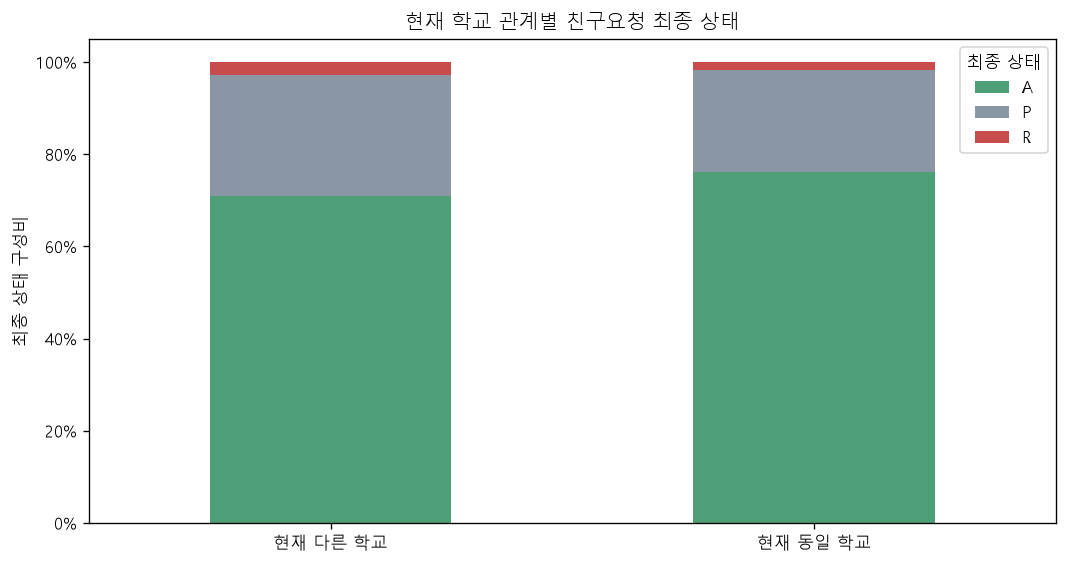

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/06_relation_status_composition.png')

In [7]:
relation_status = con.execute('''
SELECT
    CASE
        WHEN sender_current_school_id IS NULL OR receiver_current_school_id IS NULL THEN '학교관계 미확인'
        WHEN same_school_current_flag = 1 THEN '현재 동일 학교'
        ELSE '현재 다른 학교'
    END AS school_relation,
    final_status_code,
    final_status_label,
    COUNT(*) AS requests,
    MEDIAN(created_to_last_update_seconds) AS median_last_update_seconds,
    QUANTILE_CONT(created_to_last_update_seconds, .9) AS p90_last_update_seconds
FROM event
WHERE analysis_eligible_request_flag = 1
GROUP BY 1,2,3
ORDER BY 1,2
''').fetchdf()
relation_status["within_relation_share"] = relation_status.requests / relation_status.groupby("school_relation").requests.transform("sum")
save_table(relation_status, "06_relation_by_final_status.csv")
display(relation_status.round(4))

contingency = relation_status.pivot_table(index="school_relation", columns="final_status_code", values="requests", aggfunc="sum", fill_value=0)
chi2, p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.to_numpy().sum()
cramers_v = math.sqrt(chi2 / (n * min(contingency.shape[0]-1, contingency.shape[1]-1)))

def odds_ratio_ci(a, b, c, d):
    vals = np.array([a,b,c,d], float) + .5
    a,b,c,d = vals
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a+1/b+1/c+1/d)
    return np.exp(log_or), np.exp(log_or-1.96*se), np.exp(log_or+1.96*se)

same = contingency.loc["현재 동일 학교"]
cross = contingency.loc["현재 다른 학교"]
a, b = same.get("A", 0), same.sum()-same.get("A",0)
c, d = cross.get("A", 0), cross.sum()-cross.get("A",0)
or_, lo, hi = odds_ratio_ci(a,b,c,d)
quality_test = pd.DataFrame([{
    "comparison": "현재 동일 학교 vs 다른 학교의 최종 수락 상태",
    "chi2": chi2, "p_value": p, "cramers_v": cramers_v,
    "acceptance_odds_ratio": or_, "or_ci_low": lo, "or_ci_high": hi,
    "same_school_acceptance_share": a/(a+b), "cross_school_acceptance_share": c/(c+d),
    "risk_difference_pp": (a/(a+b)-c/(c+d))*100
}])
save_table(quality_test, "06_relation_quality_test.csv")
display(quality_test)

plot_status = relation_status.pivot_table(index="school_relation", columns="final_status_code", values="within_relation_share", fill_value=0)
plot_status[[c for c in ["A","P","R"] if c in plot_status]].plot(kind="bar", stacked=True, figsize=(9,4.8), color=[COLORS["green"], COLORS["gray"], COLORS["red"]])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("최종 상태 구성비")
plt.xlabel("")
plt.xticks(rotation=0)
plt.title("현재 학교 관계별 친구요청 최종 상태")
plt.legend(title="최종 상태")
savefig("06_relation_status_composition.png")

## 7. 40명 도달 전후 이벤트 스터디

학교별 D0를 기준으로 친구요청 변화를 비교한다.

- 기준선: D-14~-8
- 활성화 직전: D-7~-1
- 활성화 직후: D+1~+7
- 후기: D+8~+14


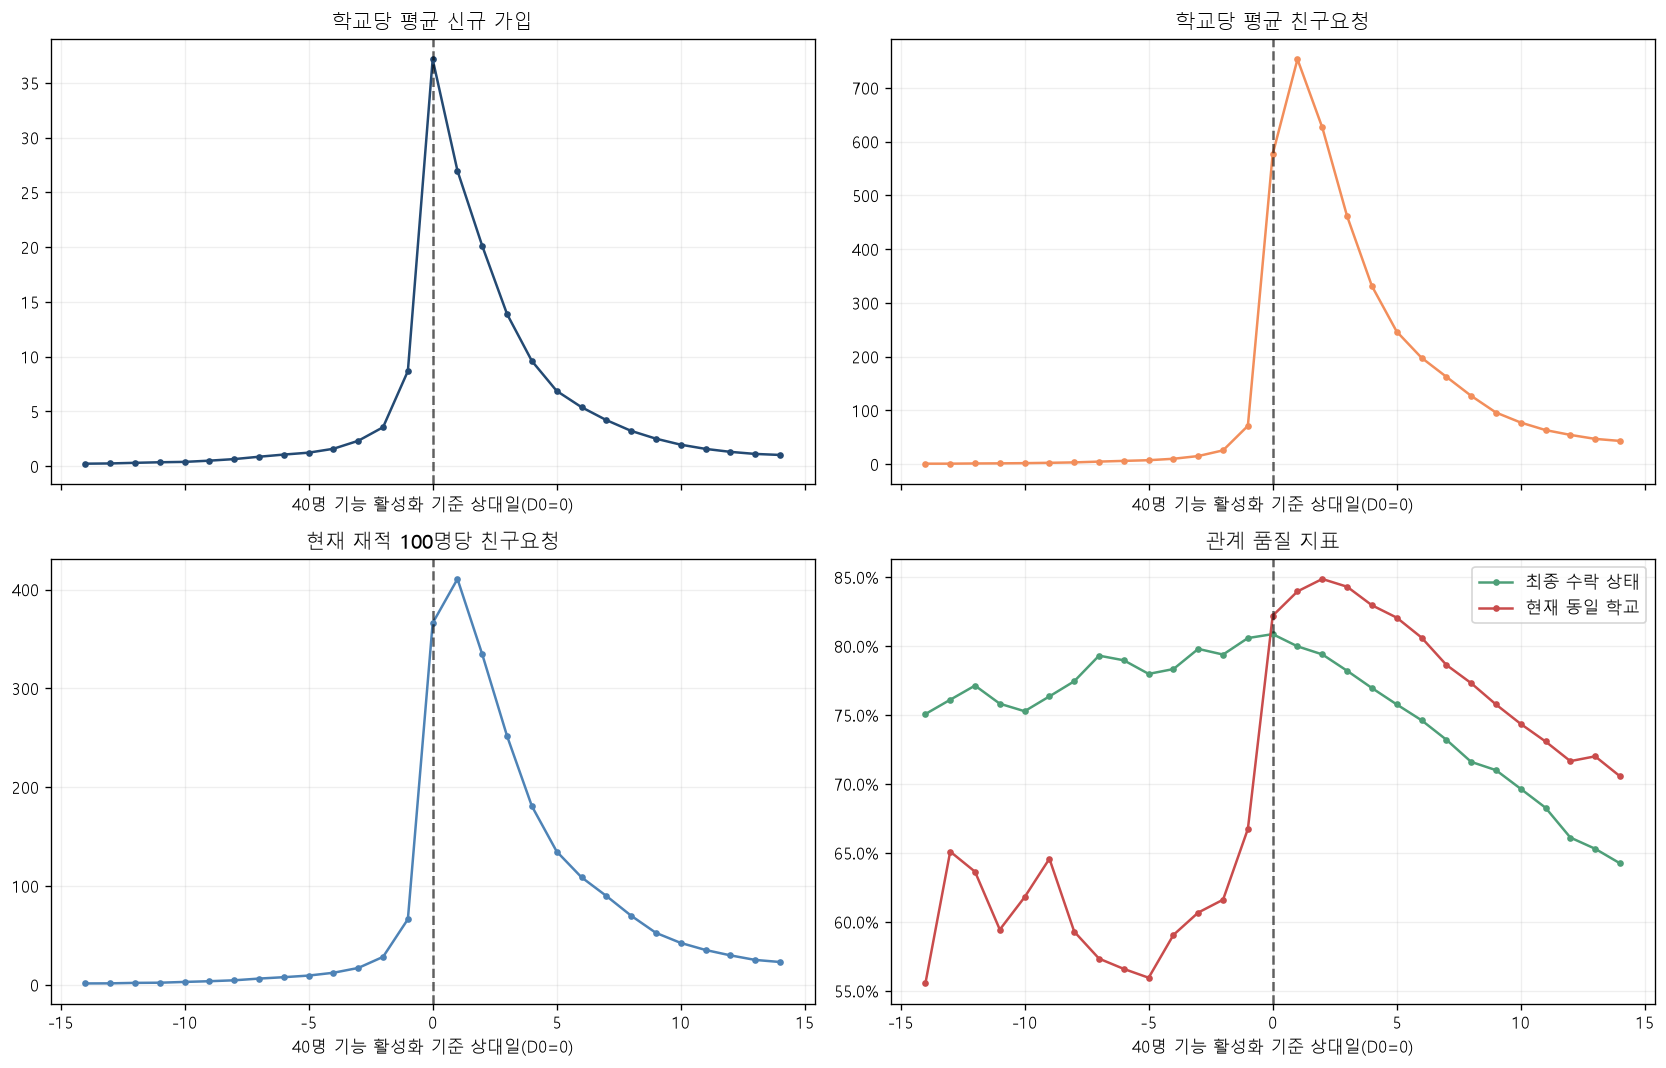

완전 관측 학교 수: 3,792개


In [8]:
event_bounds = con.execute("SELECT MIN(CAST(request_created_at_raw AS DATE)), MAX(CAST(request_created_at_raw AS DATE)) FROM event WHERE analysis_eligible_request_flag=1").fetchone()
min_event_date, max_event_date = pd.Timestamp(event_bounds[0]), pd.Timestamp(event_bounds[1])

school_event = con.execute(f'''
WITH base AS (
    SELECT
        school_id,
        CAST(activity_date AS DATE) AS activity_date,
        CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE) AS d0_date,
        DATE_DIFF('day', CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE), CAST(activity_date AS DATE)) AS rel_day,
        current_roster_nonstaff_account_count AS roster_size,
        new_nonstaff_account_count_current_roster AS new_users,
        sent_request_created_count AS sent_requests,
        sent_request_user_count AS sender_days,
        sent_created_final_accepted_count AS eventual_accepted,
        sent_created_final_pending_count AS eventual_pending,
        sent_created_final_rejected_count AS eventual_rejected,
        sent_within_school_count_current AS same_school_requests,
        sent_cross_school_count_current AS cross_school_requests
    FROM school_daily
    WHERE current_roster_reached_40_flag = 1
      AND TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) IS NOT NULL
)
SELECT * FROM base
WHERE rel_day BETWEEN -14 AND 14
  AND d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                  AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
ORDER BY school_id, rel_day
''').fetchdf()
school_event["activity_date"] = pd.to_datetime(school_event.activity_date)
school_event["d0_date"] = pd.to_datetime(school_event.d0_date)
school_event["requests_per_100_roster"] = 100 * school_event.sent_requests / school_event.roster_size.replace(0, np.nan)
school_event["sender_days_per_100_roster"] = 100 * school_event.sender_days / school_event.roster_size.replace(0, np.nan)
school_event["new_users_per_100_roster"] = 100 * school_event.new_users / school_event.roster_size.replace(0, np.nan)
school_event["same_school_share"] = school_event.same_school_requests / school_event.sent_requests.replace(0, np.nan)
school_event["eventual_acceptance_share"] = school_event.eventual_accepted / school_event.sent_requests.replace(0, np.nan)

event_curve = school_event.groupby("rel_day").agg(
    schools=("school_id","nunique"),
    mean_new_users=("new_users","mean"), median_new_users=("new_users","median"),
    mean_requests=("sent_requests","mean"), median_requests=("sent_requests","median"),
    mean_request_rate=("requests_per_100_roster","mean"), median_request_rate=("requests_per_100_roster","median"),
    mean_sender_day_rate=("sender_days_per_100_roster","mean"),
    pooled_same_school_requests=("same_school_requests","sum"), pooled_requests=("sent_requests","sum"),
    pooled_eventual_accepted=("eventual_accepted","sum")
).reset_index()
event_curve["pooled_same_school_share"] = event_curve.pooled_same_school_requests/event_curve.pooled_requests
event_curve["pooled_eventual_acceptance_share"] = event_curve.pooled_eventual_accepted/event_curve.pooled_requests
save_table(event_curve, "07_d0_event_study_curve.csv")

fig, axes = plt.subplots(2,2, figsize=(14,9), sharex=True)
axes[0,0].plot(event_curve.rel_day, event_curve.mean_new_users, marker="o", ms=3, color=COLORS["navy"])
axes[0,0].set_title("학교당 평균 신규 가입")
axes[0,1].plot(event_curve.rel_day, event_curve.mean_requests, marker="o", ms=3, color=COLORS["orange"])
axes[0,1].set_title("학교당 평균 친구요청")
axes[1,0].plot(event_curve.rel_day, event_curve.mean_request_rate, marker="o", ms=3, color=COLORS["blue"])
axes[1,0].set_title("현재 재적 100명당 친구요청")
axes[1,1].plot(event_curve.rel_day, event_curve.pooled_eventual_acceptance_share, marker="o", ms=3, color=COLORS["green"], label="최종 수락 상태")
axes[1,1].plot(event_curve.rel_day, event_curve.pooled_same_school_share, marker="o", ms=3, color=COLORS["red"], label="현재 동일 학교")
axes[1,1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1,1].set_title("관계 품질 지표")
axes[1,1].legend()
for ax in axes.flat:
    ax.axvline(0, ls="--", color="black", alpha=.6)
    ax.grid(alpha=.2)
    ax.set_xlabel("40명 기능 활성화 기준 상대일(D0=0)")
savefig("07_d0_network_event_study.png")
print(f"완전 관측 학교 수: {school_event.school_id.nunique():,}개")

## 8. 학교 내 대응표본 비교

같은 학교의 활성화 직전·직후·후기 관계 활동을 비교한다.


In [9]:
def label_window(day):
    if -14 <= day <= -8: return "baseline"
    if -7 <= day <= -1: return "pre"
    if 1 <= day <= 7: return "early"
    if 8 <= day <= 14: return "late"
    return None

school_event["window"] = school_event.rel_day.map(label_window)
window_long = school_event.dropna(subset=["window"]).groupby(["school_id","d0_date","window"]).agg(
    roster_size=("roster_size","max"),
    new_users=("new_users","sum"),
    sent_requests=("sent_requests","sum"),
    sender_days=("sender_days","sum"),
    eventual_accepted=("eventual_accepted","sum"),
    eventual_pending=("eventual_pending","sum"),
    eventual_rejected=("eventual_rejected","sum"),
    same_school_requests=("same_school_requests","sum"),
    active_request_days=("sent_requests", lambda s: int((s>0).sum()))
).reset_index()
window_long["requests_per_100_roster"] = 100*window_long.sent_requests/window_long.roster_size.replace(0,np.nan)
window_long["sender_days_per_100_roster"] = 100*window_long.sender_days/window_long.roster_size.replace(0,np.nan)
window_long["new_users_per_100_roster"] = 100*window_long.new_users/window_long.roster_size.replace(0,np.nan)
window_long["eventual_acceptance_share"] = window_long.eventual_accepted/window_long.sent_requests.replace(0,np.nan)
window_long["same_school_share"] = window_long.same_school_requests/window_long.sent_requests.replace(0,np.nan)
save_table(window_long, "08_school_window_metrics_long.csv")

wide = window_long.pivot(index=["school_id","d0_date"], columns="window")
wide.columns = [f"{metric}_{window}" for metric,window in wide.columns]
wide = wide.reset_index()

rng = np.random.default_rng(20260911)
def paired_test(metric, w1, w2, boot_n=2000):
    a = wide[f"{metric}_{w1}"]
    b = wide[f"{metric}_{w2}"]
    valid = a.notna() & b.notna()
    a, b = a[valid].to_numpy(float), b[valid].to_numpy(float)
    diff = b-a
    nonzero = diff[diff!=0]
    if len(nonzero):
        stat, p = stats.wilcoxon(nonzero, alternative="two-sided", zero_method="wilcox")
        pos, neg = np.sum(nonzero>0), np.sum(nonzero<0)
        sign_effect = (pos-neg)/len(nonzero)
    else:
        stat, p, sign_effect = np.nan, np.nan, np.nan
    idx = rng.integers(0, len(diff), size=(boot_n, len(diff)))
    med_boot = np.median(diff[idx], axis=1)
    lo, hi = np.quantile(med_boot, [.025,.975])
    return {"metric":metric,"comparison":f"{w1}→{w2}","schools":len(diff),
            "mean_before":np.mean(a),"mean_after":np.mean(b),"mean_difference":np.mean(diff),
            "median_before":np.median(a),"median_after":np.median(b),"median_difference":np.median(diff),
            "median_diff_ci_low":lo,"median_diff_ci_high":hi,
            "wilcoxon_stat":stat,"p_value":p,"paired_sign_effect":sign_effect,
            "share_increased":np.mean(diff>0)}

metrics = ["new_users_per_100_roster","requests_per_100_roster","sender_days_per_100_roster",
           "active_request_days","eventual_acceptance_share","same_school_share"]
test_rows=[]
for metric in metrics:
    test_rows.append(paired_test(metric,"pre","early"))
    test_rows.append(paired_test(metric,"early","late"))
paired_tests = pd.DataFrame(test_rows)
save_table(paired_tests, "08_paired_window_tests.csv")
display(paired_tests.round(4))

,metric,comparison,schools,mean_before,mean_after,mean_difference,median_before,median_after,median_difference,median_diff_ci_low,median_diff_ci_high,wilcoxon_stat,p_value,paired_sign_effect,share_increased
0,new_users_per_100_roster,pre→early,3792,16.0708,46.0124,29.9416,12.2951,48.3516,35.7143,34.8485,36.9428,"605,643.5000",0.0000,0.6919,0.8383
1,new_users_per_100_roster,early→late,3792,46.0124,6.9146,-39.0978,48.3516,4.8000,-40.8526,-41.5909,-40.1303,"48,146.0000",0.0000,-0.9388,0.0303
2,requests_per_100_roster,pre→early,3792,147.6547,"1,511.2671","1,363.6124",59.2243,"1,493.0024","1,393.4279","1,365.6056","1,429.3880","99,953.5000",0.0000,0.8775,0.9380
3,requests_per_100_roster,early→late,3792,"1,511.2671",278.5812,"-1,232.6859","1,493.0024",207.7182,"-1,221.0817","-1,260.5899","-1,191.5026","97,687.0000",0.0000,-0.9107,0.0446
4,sender_days_per_100_roster,pre→early,3792,18.8031,148.9272,130.1242,11.1111,156.9482,143.2836,141.3793,145.0992,"57,682.5000",0.0000,0.9059,0.9504
5,sender_days_per_100_roster,early→late,3792,148.9272,42.3413,-106.5859,156.9482,36.1238,-115.9897,-118.1818,-113.9301,"98,017.5000",0.0000,-0.9096,0.0451
6,active_request_days,pre→early,3792,3.3972,6.8534,3.4562,3.0000,7.0000,4.0000,4.0000,4.0000,"81,692.5000",0.0000,0.9345,0.8805
7,active_request_days,early→late,3792,6.8534,6.3972,-0.4562,7.0000,7.0000,0.0000,0.0000,0.0000,"31,753.0000",0.0000,-0.8193,0.0227
8,eventual_acceptance_share,pre→early,3485,0.8206,0.7446,-0.0760,0.8357,0.7660,-0.0795,-0.0840,-0.0752,"833,777.0000",0.0000,-0.6109,0.1945
9,eventual_acceptance_share,early→late,3767,0.7470,0.6087,-0.1383,0.7661,0.6321,-0.1269,-0.1304,-0.1233,"122,403.5000",0.0000,-0.9172,0.0414


## 9. 전국 일별 파동 통제

전국 요청 100만 건당 학교 요청량으로 D0 전후 결과를 다시 확인한다.


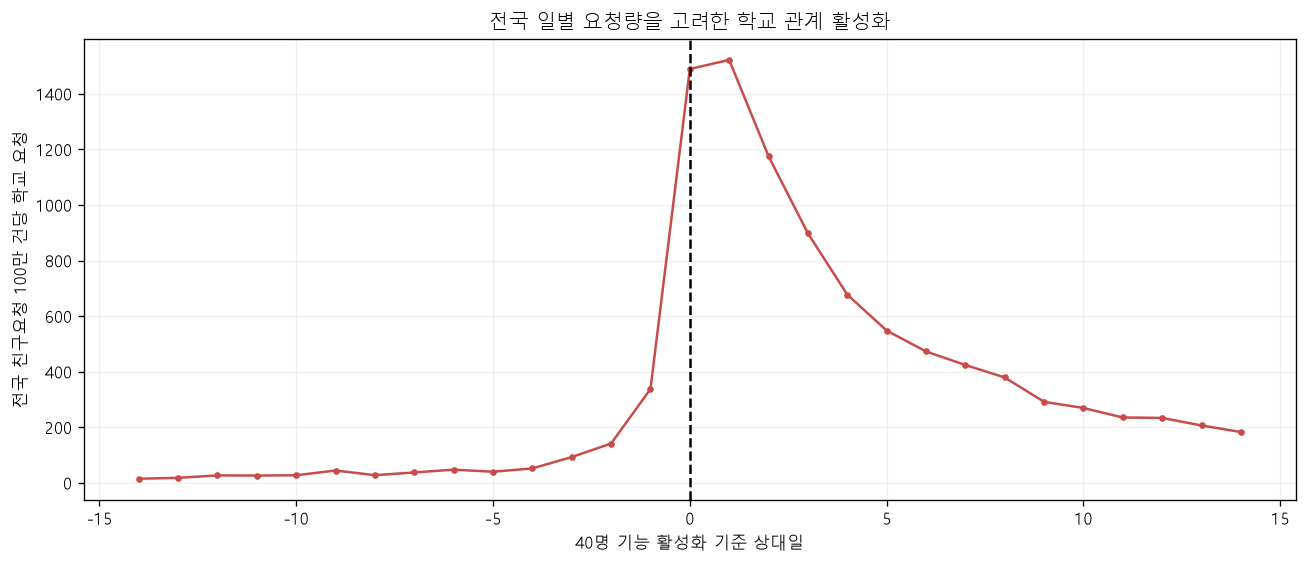

,comparison,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,pre→early,3792,23.4380,552.6002,504.3295,0.9388,0.0000
1,early→late,3792,552.6002,128.4615,-363.7064,0.0883,0.0000


In [10]:
national = daily.set_index("activity_date")["sent_requests"]
school_event["national_requests"] = school_event.activity_date.map(national)
school_event["request_share_per_million"] = 1_000_000 * school_event.sent_requests / school_event.national_requests.replace(0,np.nan)
adjusted_curve = school_event.groupby("rel_day").agg(
    mean_share_per_million=("request_share_per_million","mean"),
    median_share_per_million=("request_share_per_million","median"),
    mean_requests_per_100=("requests_per_100_roster","mean")
).reset_index()
save_table(adjusted_curve, "09_calendar_adjusted_event_curve.csv")

fig, ax = plt.subplots(figsize=(11,4.8))
ax.plot(adjusted_curve.rel_day, adjusted_curve.mean_share_per_million, marker="o", ms=3, color=COLORS["red"])
ax.axvline(0, ls="--", color="black")
ax.set_xlabel("40명 기능 활성화 기준 상대일")
ax.set_ylabel("전국 친구요청 100만 건당 학교 요청")
ax.set_title("전국 일별 요청량을 고려한 학교 관계 활성화")
ax.grid(alpha=.2)
savefig("09_calendar_adjusted_network_event_study.png")

adj_window = school_event.dropna(subset=["window"]).groupby(["school_id","window"]).request_share_per_million.mean().unstack()
adj_rows=[]
for w1,w2 in [("pre","early"),("early","late")]:
    a,b=adj_window[w1],adj_window[w2]
    valid=a.notna()&b.notna(); diff=(b[valid]-a[valid]).to_numpy()
    nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    adj_rows.append({"comparison":f"{w1}→{w2}","schools":len(diff),"median_before":np.median(a[valid]),
                     "median_after":np.median(b[valid]),"median_difference":np.median(diff),
                     "share_increased":np.mean(diff>0),"wilcoxon_p":p})
adjusted_tests=pd.DataFrame(adj_rows)
save_table(adjusted_tests,"09_calendar_adjusted_tests.csv")
display(adjusted_tests)

## 10. D0 구간별 관계 구성

활성화 직전·직후·후기의 최종 상태와 현재 동일 학교 관계 비중을 비교한다.


final_status_code,A,P,R
window,,,
pre,427335,99854,7866
early,8227610,2116788,197455
late,1332719,544577,54642


,test,chi2,p_value,cramers_v,early_acceptance_share,late_acceptance_share,early_vs_late_acceptance_or,or_ci_low,or_ci_high,risk_difference_pp
0,D0 window × final status,"78,698.4755",0.0000,0.0550,0.7805,0.6898,1.5985,1.5931,1.6039,9.0636


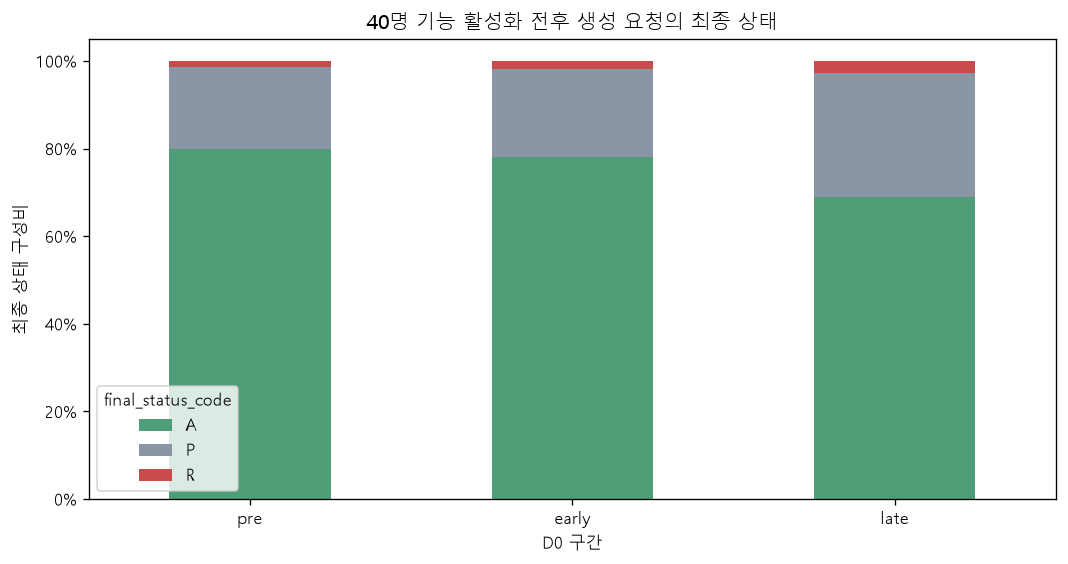

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/10_d0_window_status_composition.png')

In [11]:
phase_quality = con.execute(f'''
WITH d0 AS (
    SELECT school_id,
           CAST(MAX(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS DATE) AS d0_date
    FROM school_daily
    WHERE current_roster_reached_40_flag=1
    GROUP BY 1
), joined AS (
    SELECT e.final_status_code,
           e.same_school_current_flag,
           e.created_to_last_update_seconds,
           DATE_DIFF('day', d.d0_date, CAST(e.request_created_at_raw AS DATE)) AS rel_day
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
)
SELECT CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
            WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
            WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS window,
       final_status_code,
       same_school_current_flag,
       COUNT(*) AS requests,
       MEDIAN(created_to_last_update_seconds) AS median_last_update_seconds,
       QUANTILE_CONT(created_to_last_update_seconds,.9) AS p90_last_update_seconds
FROM joined
WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
GROUP BY 1,2,3
ORDER BY 1,2,3
''').fetchdf()
save_table(phase_quality,"10_d0_window_relation_quality.csv")

status_tab=phase_quality.groupby(["window","final_status_code"]).requests.sum().unstack(fill_value=0).reindex(["pre","early","late"])
chi2,p,dof,expected=stats.chi2_contingency(status_tab)
n=status_tab.to_numpy().sum(); cv=math.sqrt(chi2/(n*min(status_tab.shape[0]-1,status_tab.shape[1]-1)))

def window_acceptance(window):
    row=status_tab.loc[window]
    return row.get("A",0), row.sum()-row.get("A",0)
ea,en=window_acceptance("early"); la,ln=window_acceptance("late")
or_el,lo_el,hi_el=odds_ratio_ci(ea,en,la,ln)
phase_tests=pd.DataFrame([{
    "test":"D0 window × final status", "chi2":chi2,"p_value":p,"cramers_v":cv,
    "early_acceptance_share":ea/(ea+en),"late_acceptance_share":la/(la+ln),
    "early_vs_late_acceptance_or":or_el,"or_ci_low":lo_el,"or_ci_high":hi_el,
    "risk_difference_pp":100*(ea/(ea+en)-la/(la+ln))
}])
save_table(phase_tests,"10_d0_window_quality_tests.csv")
display(status_tab)
display(phase_tests)

comp=(status_tab.T/status_tab.sum(axis=1)).T
comp.plot(kind="bar",stacked=True,figsize=(9,4.8),color=[COLORS["green"],COLORS["gray"],COLORS["red"]])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xticks(rotation=0)
plt.xlabel("D0 구간")
plt.ylabel("최종 상태 구성비")
plt.title("40명 기능 활성화 전후 생성 요청의 최종 상태")
savefig("10_d0_window_status_composition.png")

## 11. 초기 관계 활동과 후기 지속성

D+1~+7 관계 활동과 D+8~+14 활동의 예측적 연관성을 확인한다.


,feature,spearman_rho_with_late_request_rate,p_value
5,early_acceptance_share,0.3733,0.0000
0,log_roster_size,0.3269,0.0000
2,early_new_users_per_100,0.2008,0.0000
6,early_same_school_share,0.1721,0.0000
7,early_active_days,0.1643,0.0000
4,early_sender_days_per_100,0.0631,0.0001
3,early_requests_per_100,0.0546,0.0008
1,d0_day_index,-0.1529,0.0000


,feature,standardized_coef,hc3_se,z,p_value,ci_low,ci_high
0,intercept,5.2041,0.0144,362.4930,0.0000,5.1760,5.2322
1,log_roster_size,0.0487,0.0285,1.7076,0.0877,-0.0072,0.1046
2,d0_day_index,-0.1778,0.0310,-5.7389,0.0000,-0.2386,-0.1171
3,early_new_users_per_100,0.1136,0.0300,3.7921,0.0001,0.0549,0.1724
4,early_requests_per_100,0.0532,0.0341,1.5570,0.1195,-0.0138,0.1201
5,early_sender_days_per_100,-0.4031,0.0413,-9.7550,0.0000,-0.4841,-0.3221
6,early_acceptance_share,0.5389,0.0301,17.9172,0.0000,0.4800,0.5979
7,early_same_school_share,0.1060,0.0206,5.1407,0.0000,0.0656,0.1465
8,early_active_days,0.1241,0.0347,3.5789,0.0003,0.0561,0.1920


,train_schools,test_schools,temporal_cutoff,test_r2,test_mae_log_scale,selected_alpha,random_5fold_r2_mean,random_5fold_r2_sd
0,3110,674,2023-05-21,-0.9614,1.4178,5.6234,0.3286,0.0330


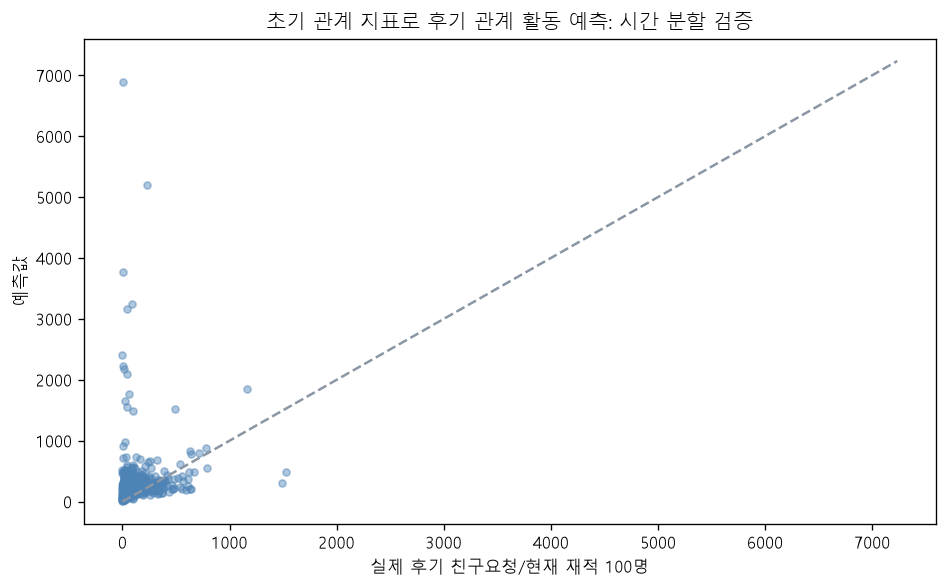

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/11_temporal_holdout_prediction.png')

In [12]:
model_df = pd.DataFrame({
    "school_id": wide.school_id,
    "d0_date": pd.to_datetime(wide.d0_date),
    "roster_size": wide.get("roster_size_early"),
    "early_new_users_per_100": wide.get("new_users_per_100_roster_early"),
    "early_requests_per_100": wide.get("requests_per_100_roster_early"),
    "early_sender_days_per_100": wide.get("sender_days_per_100_roster_early"),
    "early_acceptance_share": wide.get("eventual_acceptance_share_early"),
    "early_same_school_share": wide.get("same_school_share_early"),
    "early_active_days": wide.get("active_request_days_early"),
    "late_requests_per_100": wide.get("requests_per_100_roster_late"),
    "late_active_days": wide.get("active_request_days_late"),
}).replace([np.inf,-np.inf],np.nan)
model_df["d0_day_index"]=(model_df.d0_date-model_df.d0_date.min()).dt.days
model_df["log_roster_size"]=np.log1p(model_df.roster_size)
model_df["log_late_request_rate"]=np.log1p(model_df.late_requests_per_100)
features=["log_roster_size","d0_day_index","early_new_users_per_100","early_requests_per_100",
          "early_sender_days_per_100","early_acceptance_share","early_same_school_share","early_active_days"]
m=model_df.dropna(subset=features+["log_late_request_rate"]).copy()

corr_rows=[]
for x in features:
    rho,p=stats.spearmanr(m[x],m.log_late_request_rate)
    corr_rows.append({"feature":x,"spearman_rho_with_late_request_rate":rho,"p_value":p})
corr=pd.DataFrame(corr_rows).sort_values("spearman_rho_with_late_request_rate",ascending=False)
save_table(corr,"11_early_late_spearman.csv")

# HC3 강건표준오차를 사용한 OLS: 연속형 결과 log(1+후기 요청/100명)
X0=m[features].to_numpy(float)
means=X0.mean(axis=0); stds=X0.std(axis=0,ddof=0); stds[stds==0]=1
Z=(X0-means)/stds
X=np.c_[np.ones(len(Z)),Z]
y=m.log_late_request_rate.to_numpy(float)
xtx_inv=np.linalg.pinv(X.T@X)
beta=xtx_inv@X.T@y
resid=y-X@beta
hat=np.sum((X@xtx_inv)*X,axis=1)
adj=(resid/(1-hat))**2
meat=X.T@(X*adj[:,None])
vcov=xtx_inv@meat@xtx_inv
se=np.sqrt(np.diag(vcov)); z=beta/se; pvals=2*stats.norm.sf(np.abs(z))
names=["intercept"]+features
ols=pd.DataFrame({"feature":names,"standardized_coef":beta,"hc3_se":se,"z":z,"p_value":pvals,
                  "ci_low":beta-1.96*se,"ci_high":beta+1.96*se})
save_table(ols,"11_late_network_ols_hc3.csv")

# D0 날짜 기준 시간 분할 예측 강건성 점검
cutoff=m.d0_date.quantile(.8)
train=m.d0_date<=cutoff; test=~train
ridge=make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-3,3,25)))
ridge.fit(m.loc[train,features],m.loc[train,"log_late_request_rate"])
pred=ridge.predict(m.loc[test,features])
random_cv=KFold(n_splits=5,shuffle=True,random_state=20260911)
random_cv_r2=cross_val_score(
    make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-3,3,25))),
    m[features],m["log_late_request_rate"],cv=random_cv,scoring="r2"
)
model_quality=pd.DataFrame([{
    "train_schools":int(train.sum()),"test_schools":int(test.sum()),"temporal_cutoff":cutoff,
    "test_r2":r2_score(m.loc[test,"log_late_request_rate"],pred),
    "test_mae_log_scale":mean_absolute_error(m.loc[test,"log_late_request_rate"],pred),
    "selected_alpha":ridge.named_steps["ridgecv"].alpha_,
    "random_5fold_r2_mean":random_cv_r2.mean(),
    "random_5fold_r2_sd":random_cv_r2.std()
}])
save_table(model_quality,"11_temporal_holdout_model_quality.csv")
save_table(model_df,"11_school_early_late_model_dataset.csv")
display(corr)
display(ols.round(4))
display(model_quality)

fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(np.expm1(m.loc[test,"log_late_request_rate"]),np.expm1(pred),s=18,alpha=.45,color=COLORS["blue"])
mx=max(ax.get_xlim()[1],ax.get_ylim()[1]); ax.plot([0,mx],[0,mx],"--",color=COLORS["gray"])
ax.set_xlabel("실제 후기 친구요청/현재 재적 100명")
ax.set_ylabel("예측값")
ax.set_title("초기 관계 지표로 후기 관계 활동 예측: 시간 분할 검증")
savefig("11_temporal_holdout_prediction.png")

## 12. 현재 친구망과 요청 기록의 정합성

요청·수락 기록과 현재 친구 수가 같은 방향으로 움직이는지 확인한다.


,metric,spearman_rho
3,received_unique_partner_count,0.7654
1,received_request_count,0.7645
4,sent_final_accepted_count,0.7055
2,sent_unique_partner_count,0.6836
0,sent_request_count,0.6830
5,received_final_accepted_count,0.6750


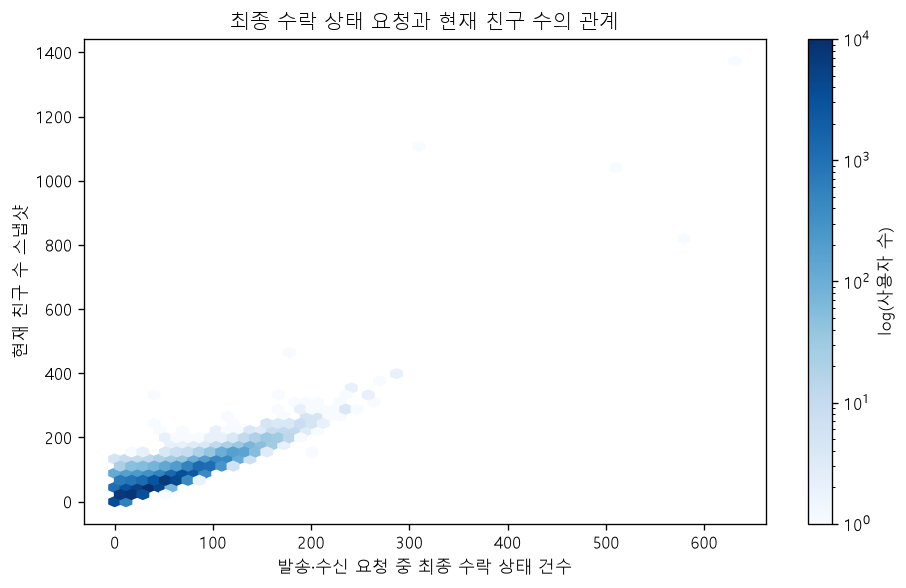

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/12_accepted_requests_vs_current_friends.png')

In [13]:
snapshot_cols=["sent_request_count","received_request_count","sent_unique_partner_count","received_unique_partner_count",
               "sent_final_accepted_count","received_final_accepted_count","current_friend_list_length"]
snapshot_corr=user_network[snapshot_cols].corr(method="spearman")[["current_friend_list_length"]].drop("current_friend_list_length")
snapshot_corr=snapshot_corr.reset_index().rename(columns={"index":"metric","current_friend_list_length":"spearman_rho"})
save_table(snapshot_corr,"12_current_friend_snapshot_correlations.csv")
display(snapshot_corr.sort_values("spearman_rho",ascending=False))

sample=user_network.sample(min(80000,len(user_network)),random_state=20260911)
plt.figure(figsize=(8,5))
plt.hexbin(sample.sent_final_accepted_count+sample.received_final_accepted_count,
           sample.current_friend_list_length,gridsize=55,bins="log",mincnt=1,cmap="Blues")
plt.xlabel("발송·수신 요청 중 최종 수락 상태 건수")
plt.ylabel("현재 친구 수 스냅샷")
plt.title("최종 수락 상태 요청과 현재 친구 수의 관계")
plt.colorbar(label="log(사용자 수)")
savefig("12_accepted_requests_vs_current_friends.png")

## 13. K-Factor와 Viral Cycle Time 식별 가능성

친구요청은 가입 이후 행동이므로 초대 전환 지표를 계산할 수 없다.


In [14]:
contact_audit=con.execute('''
SELECT
    COUNT(*) AS all_users,
    SUM(contacts_observed_flag) AS users_with_contact_snapshot,
    SUM(CASE WHEN TRY_CAST(invite_user_id_list_length AS BIGINT)>0 THEN 1 ELSE 0 END) AS users_with_inviter_reference,
    SUM(CASE WHEN TRY_CAST(contacts_count_source AS BIGINT)>0 THEN 1 ELSE 0 END) AS users_with_contacts,
    SUM(analysis_eligible_nonstaff_flag) AS eligible_users
FROM acquisition
''').fetchdf()
contact_audit["contact_snapshot_coverage"] = contact_audit.users_with_contact_snapshot/contact_audit.all_users
contact_audit["inviter_reference_coverage"] = contact_audit.users_with_inviter_reference/contact_audit.all_users
save_table(contact_audit,"13_kfactor_identifiability_audit.csv")
display(contact_audit.round(4))

identifiability=pd.DataFrame([
    ["초대 발송자","연락처 스냅샷 일부만 관측","전체 K 계산 불가"],
    ["초대 수신자","가입자와 직접 연결되는 초대 수신 이벤트 없음","가입 전환율 계산 불가"],
    ["초대 발송 시각","없음","Viral Cycle Time 계산 불가"],
    ["초대를 통한 가입 시각","없음","Viral Cycle Time 계산 불가"],
    ["친구요청 발송·수신 시각","있음","가입 후 Network 활성화 분석 가능"],
],columns=["필요 정보","현재 관측 상태","판단"])
save_table(identifiability,"13_kfactor_required_fields.csv")
display(identifiability)

,all_users,users_with_contact_snapshot,users_with_inviter_reference,users_with_contacts,eligible_users,contact_snapshot_coverage,inviter_reference_coverage
0,677085,"5,063.0000","1,158.0000","5,060.0000","677,081.0000",0.0075,0.0017


,필요 정보,현재 관측 상태,판단
0,초대 발송자,연락처 스냅샷 일부만 관측,전체 K 계산 불가
1,초대 수신자,가입자와 직접 연결되는 초대 수신 이벤트 없음,가입 전환율 계산 불가
2,초대 발송 시각,없음,Viral Cycle Time 계산 불가
3,초대를 통한 가입 시각,없음,Viral Cycle Time 계산 불가
4,친구요청 발송·수신 시각,있음,가입 후 Network 활성화 분석 가능


## 14. 요청량 증가 요인 분해

요청량을 발송자-일 수와 발송자-일당 요청 수로 나눠 참여 확산과 발송 강도를 구분한다.


,window,schools,median_requests_per_100,median_sender_days_per_100,median_requests_per_sender_day,median_active_days
0,baseline,3792,0.0000,0.0000,3.0000,0.0000
1,pre,3792,59.2243,11.1111,5.4286,3.0000
2,early,3792,"1,493.0024",156.9482,9.5992,7.0000
3,late,3792,207.7182,36.1238,5.8381,7.0000


,metric,comparison,schools,median_before,median_after,median_difference,median_diff_ci_low,median_diff_ci_high,share_increased,wilcoxon_p
0,sender_days_per_100_roster,pre→early,3792,11.1111,156.9482,143.2836,141.4522,145.0620,0.9504,0.0000
1,sender_days_per_100_roster,early→late,3792,156.9482,36.1238,-115.9897,-118.2482,-114.0109,0.0451,0.0000
2,requests_per_sender_day,pre→early,3485,5.4286,9.4667,3.8304,3.6513,4.0131,0.8000,0.0000
3,requests_per_sender_day,early→late,3767,9.6036,5.8372,-3.8125,-3.9067,-3.6778,0.1149,0.0000
4,active_request_days,pre→early,3792,3.0000,7.0000,4.0000,4.0000,4.0000,0.8805,0.0000
5,active_request_days,early→late,3792,7.0000,7.0000,0.0000,0.0000,0.0000,0.0227,0.0000


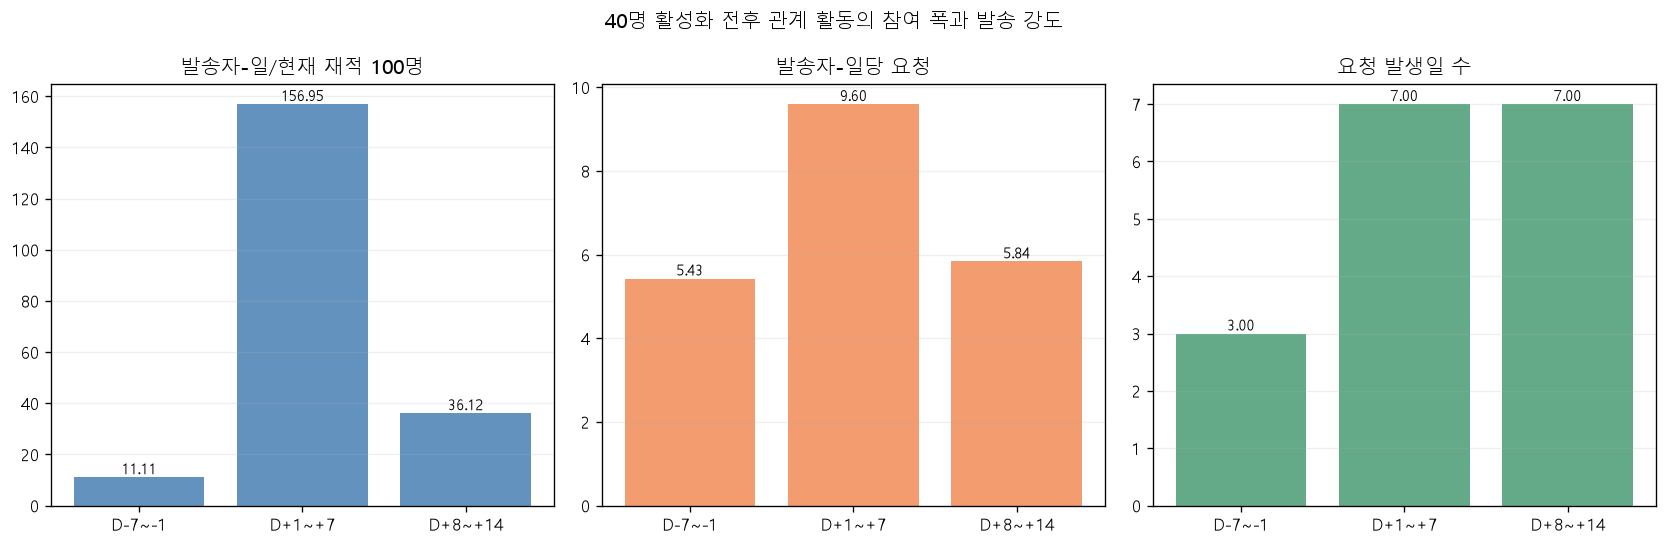

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/14_reach_intensity_decomposition.png')

In [15]:
decomp = window_long.copy()
decomp["requests_per_sender_day"] = decomp.sent_requests / decomp.sender_days.replace(0, np.nan)
decomp_summary = (decomp.groupby("window")
                  .agg(schools=("school_id","nunique"),
                       median_requests_per_100=("requests_per_100_roster","median"),
                       median_sender_days_per_100=("sender_days_per_100_roster","median"),
                       median_requests_per_sender_day=("requests_per_sender_day","median"),
                       median_active_days=("active_request_days","median"))
                  .reindex(["baseline","pre","early","late"]).reset_index())
save_table(decomp_summary, "14_reach_intensity_decomposition.csv")

decomp_wide = decomp.pivot(index=["school_id","d0_date"], columns="window")
decomp_wide.columns = [f"{metric}_{window}" for metric,window in decomp_wide.columns]
decomp_wide = decomp_wide.reset_index()

def paired_from_frame(frame, metric, w1, w2, boot_n=2000):
    a=frame[f"{metric}_{w1}"]; b=frame[f"{metric}_{w2}"]
    valid=a.notna()&b.notna(); a=a[valid].to_numpy(float); b=b[valid].to_numpy(float)
    diff=b-a; nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    boots=[]
    for _ in range(boot_n):
        boots.append(np.median(rng.choice(diff,size=len(diff),replace=True)))
    return {"metric":metric,"comparison":f"{w1}→{w2}","schools":len(diff),
            "median_before":np.median(a),"median_after":np.median(b),
            "median_difference":np.median(diff),"median_diff_ci_low":np.quantile(boots,.025),
            "median_diff_ci_high":np.quantile(boots,.975),"share_increased":np.mean(diff>0),
            "wilcoxon_p":p}

decomp_test_rows=[]
for metric in ["sender_days_per_100_roster","requests_per_sender_day","active_request_days"]:
    decomp_test_rows.append(paired_from_frame(decomp_wide,metric,"pre","early"))
    decomp_test_rows.append(paired_from_frame(decomp_wide,metric,"early","late"))
decomp_tests=pd.DataFrame(decomp_test_rows)
save_table(decomp_tests,"14_reach_intensity_paired_tests.csv")
display(decomp_summary.round(4))
display(decomp_tests.round(4))

fig,axes=plt.subplots(1,3,figsize=(14,4.6))
order=["pre","early","late"]
labels=["D-7~-1","D+1~+7","D+8~+14"]
specs=[("median_sender_days_per_100","발송자-일/현재 재적 100명",COLORS["blue"]),
       ("median_requests_per_sender_day","발송자-일당 요청",COLORS["orange"]),
       ("median_active_days","요청 발생일 수",COLORS["green"])]
temp=decomp_summary.set_index("window")
for ax,(col,title,color) in zip(axes,specs):
    vals=temp.loc[order,col]
    ax.bar(labels,vals,color=color,alpha=.88)
    for i,v in enumerate(vals): ax.text(i,v,f"{v:.2f}",ha="center",va="bottom",fontsize=9)
    ax.set_title(title); ax.grid(axis="y",alpha=.2)
plt.suptitle("40명 활성화 전후 관계 활동의 참여 폭과 발송 강도")
savefig("14_reach_intensity_decomposition.png")

## 15. D0 전후 발송자의 가입 경과일

요청 증가가 신규 사용자의 초기 행동인지 기존 사용자의 재활성화인지 확인한다.


,phase,sender_age_band,requests,senders,eventual_accepted,same_school_requests,phase_request_share,eventual_acceptance_share,same_school_share
0,early,가입 1~3일,1742843,226831,"1,291,139.0000","1,369,197.0000",0.1653,0.7408,0.7856
1,early,가입 24시간 이내,7360591,361829,"5,930,167.0000","6,392,329.0000",0.6982,0.8057,0.8685
2,early,가입 31일+,2252,306,"1,434.0000","1,658.0000",0.0002,0.6368,0.7362
3,early,가입 4~7일,1115129,166668,"784,804.0000","813,539.0000",0.1058,0.7038,0.7295
4,early,가입 8~30일,321038,38056,"220,066.0000","214,237.0000",0.0305,0.6855,0.6673
5,late,가입 1~3일,125675,23375,"89,345.0000","94,464.0000",0.0651,0.7109,0.7517
6,late,가입 24시간 이내,1075560,47837,"784,672.0000","862,695.0000",0.5567,0.7295,0.8021
7,late,가입 31일+,1628,318,799.0000,938.0000,0.0008,0.4908,0.5762
8,late,가입 4~7일,237133,53368,"158,933.0000","163,851.0000",0.1227,0.6702,0.6910
9,late,가입 8~30일,491942,105816,"298,970.0000","314,956.0000",0.2546,0.6077,0.6402


,comparison,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,pre→early,3485,0.9374,0.6794,-0.2508,0.1116,0.0000
1,early→late,3767,0.6809,0.5073,-0.1696,0.1925,0.0000


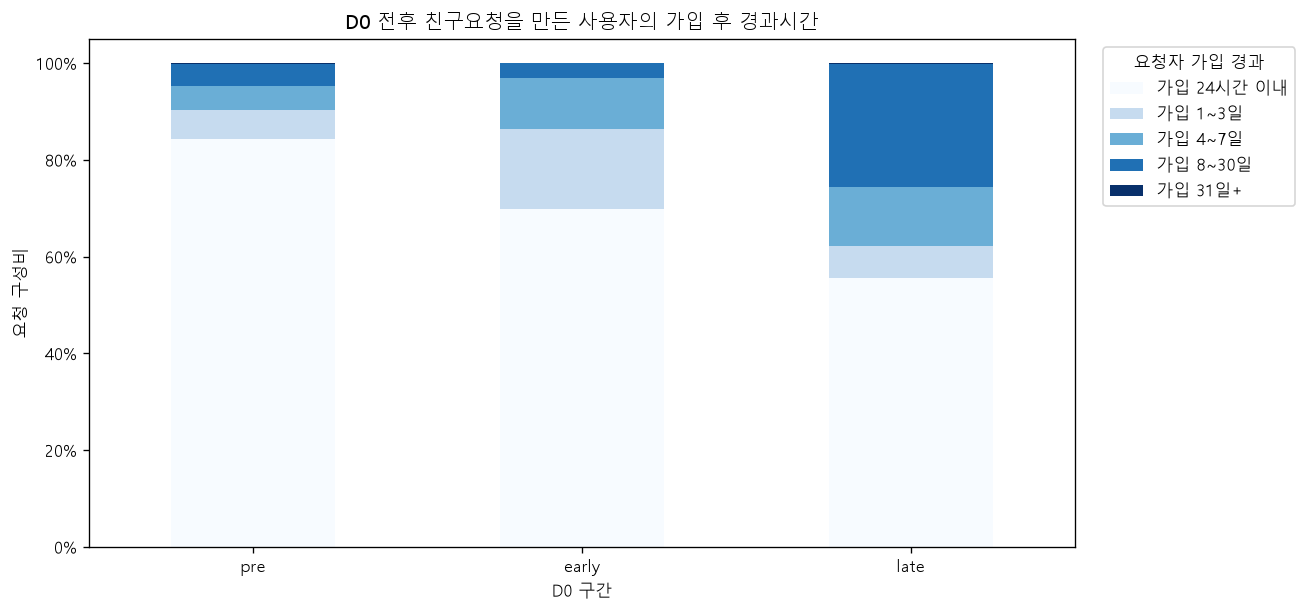

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/15_request_sender_tenure_composition.png')

In [16]:
request_age_school = con.execute(f'''
WITH d0 AS (
    SELECT school_id,
           MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily
    WHERE current_roster_reached_40_flag=1
    GROUP BY 1
), base AS (
    SELECT e.sender_current_school_id AS school_id,
           e.send_user_id,
           e.final_status_code,
           e.same_school_current_flag,
           DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           EPOCH(CAST(e.request_created_at_raw AS TIMESTAMP)-CAST(p.signup_at AS TIMESTAMP))/3600 AS sender_age_hours
    FROM event e
    JOIN profile p ON e.send_user_id=p.user_id
    JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
), labeled AS (
    SELECT *,
           CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase,
           CASE WHEN sender_age_hours<0 THEN '가입 이전(시각 이상)'
                WHEN sender_age_hours<24 THEN '가입 24시간 이내'
                WHEN sender_age_hours<72 THEN '가입 1~3일'
                WHEN sender_age_hours<168 THEN '가입 4~7일'
                WHEN sender_age_hours<720 THEN '가입 8~30일'
                ELSE '가입 31일+' END AS sender_age_band
    FROM base
    WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
)
SELECT school_id,phase,sender_age_band,
       COUNT(*) AS requests,COUNT(DISTINCT send_user_id) AS senders,
       SUM(CASE WHEN final_status_code='A' THEN 1 ELSE 0 END) AS eventual_accepted,
       SUM(CASE WHEN same_school_current_flag=1 THEN 1 ELSE 0 END) AS same_school_requests
FROM labeled
GROUP BY 1,2,3
''').fetchdf()

request_age_pooled=(request_age_school.groupby(["phase","sender_age_band"],as_index=False)
                    .agg(requests=("requests","sum"),senders=("senders","sum"),
                         eventual_accepted=("eventual_accepted","sum"),
                         same_school_requests=("same_school_requests","sum")))
request_age_pooled["phase_request_share"]=request_age_pooled.requests/request_age_pooled.groupby("phase").requests.transform("sum")
request_age_pooled["eventual_acceptance_share"]=request_age_pooled.eventual_accepted/request_age_pooled.requests
request_age_pooled["same_school_share"]=request_age_pooled.same_school_requests/request_age_pooled.requests
save_table(request_age_pooled,"15_request_sender_tenure_composition.csv")

newcomer_school=(request_age_school.assign(newcomer=lambda x:x.sender_age_band.eq("가입 24시간 이내"))
                 .groupby(["school_id","phase"])
                 .apply(lambda g:pd.Series({"requests":g.requests.sum(),
                                           "newcomer_requests":g.loc[g.newcomer,"requests"].sum()}),
                        include_groups=False).reset_index())
newcomer_school["newcomer_request_share"]=newcomer_school.newcomer_requests/newcomer_school.requests.replace(0,np.nan)
newcomer_wide=newcomer_school.pivot(index="school_id",columns="phase",values="newcomer_request_share")
newcomer_tests=[]
for a,b in [("pre","early"),("early","late")]:
    z=newcomer_wide[[a,b]].dropna(); diff=(z[b]-z[a]).to_numpy(); nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    newcomer_tests.append({"comparison":f"{a}→{b}","schools":len(z),"median_before":z[a].median(),
                           "median_after":z[b].median(),"median_difference":np.median(diff),
                           "share_increased":np.mean(diff>0),"wilcoxon_p":p})
newcomer_tests=pd.DataFrame(newcomer_tests)
save_table(newcomer_tests,"15_newcomer_share_paired_tests.csv")
display(request_age_pooled.round(4))
display(newcomer_tests.round(4))

age_order=["가입 24시간 이내","가입 1~3일","가입 4~7일","가입 8~30일","가입 31일+","가입 이전(시각 이상)"]
age_chart=request_age_pooled.pivot(index="phase",columns="sender_age_band",values="phase_request_share").fillna(0).reindex(["pre","early","late"])
age_chart=age_chart.reindex(columns=[c for c in age_order if c in age_chart.columns])
age_chart.plot(kind="bar",stacked=True,figsize=(11,5.2),colormap="Blues")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1)); plt.xticks(rotation=0)
plt.xlabel("D0 구간"); plt.ylabel("요청 구성비")
plt.title("D0 전후 친구요청을 만든 사용자의 가입 후 경과시간")
plt.legend(title="요청자 가입 경과",bbox_to_anchor=(1.02,1),loc="upper left")
savefig("15_request_sender_tenure_composition.png")

## 16. 초기 발송과 둘째 주 지속

첫 7일 발송자가 D+8~D+14에도 요청을 보냈는지 확인한다.


,signup_phase,users,early_senders,early_sender_share,continued_users,median_first24_share_of_first14d,median_d0_d7_requests,median_d8_d14_requests,d8_d14_continuation_share_among_early_senders
0,40명 미도달,21572,16321,0.7566,1935,1.0000,6.0000,3.0000,0.1186
1,40명 이전 가입,151983,139368,0.9170,51252,0.5000,15.0000,4.0000,0.3677
2,40명 이후 가입,503442,484136,0.9617,90775,0.9348,21.0000,2.0000,0.1875


,comparison,pre_continuation_share,post_continuation_share,risk_difference_pp,risk_difference_ci_low_pp,risk_difference_ci_high_pp,user_level_chi2,user_level_p,cramers_v,paired_schools,school_median_difference,school_wilcoxon_p
0,40명 이전 가입→이후 가입,0.3677,0.1875,-18.0247,-18.3007,-17.7487,"19,986.4824",0.0000,0.1790,3896,-0.1771,0.0000


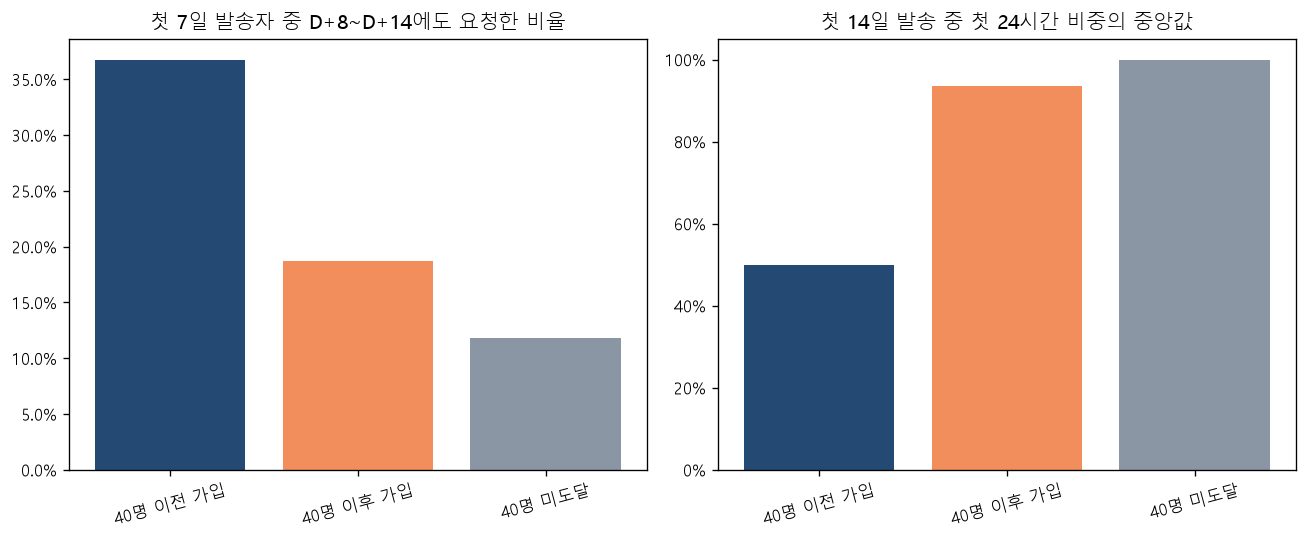

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/16_onboarding_burst_and_continuation.png')

In [17]:
max_request_ts=con.execute("SELECT MAX(CAST(request_created_at_raw AS TIMESTAMP)) FROM event WHERE analysis_eligible_request_flag=1").fetchone()[0]
lifecycle_user=con.execute(f'''
WITH eligible AS (
    SELECT user_id,current_school_id,signup_at,current_roster_40th_signup_at,current_friend_list_length,
           CASE WHEN current_roster_40th_signup_at IS NULL THEN '40명 미도달'
                WHEN signup_at<current_roster_40th_signup_at THEN '40명 이전 가입'
                ELSE '40명 이후 가입' END AS signup_phase
    FROM profile
    WHERE analysis_eligible_nonstaff_flag=1
      AND signup_at<=TIMESTAMP '{pd.Timestamp(max_request_ts)-pd.Timedelta(days=14)}'
), counts AS (
    SELECT u.user_id,
           SUM(CASE WHEN e.request_created_at_raw>=u.signup_at
                     AND e.request_created_at_raw<u.signup_at+INTERVAL 1 DAY THEN 1 ELSE 0 END) AS sent_first_24h_count,
           SUM(CASE WHEN e.request_created_at_raw>=u.signup_at
                     AND e.request_created_at_raw<u.signup_at+INTERVAL 7 DAY THEN 1 ELSE 0 END) AS sent_d0_d7_count,
           SUM(CASE WHEN e.request_created_at_raw>=u.signup_at+INTERVAL 7 DAY
                     AND e.request_created_at_raw<u.signup_at+INTERVAL 14 DAY THEN 1 ELSE 0 END) AS sent_d8_d14_count
    FROM eligible u
    LEFT JOIN event e ON e.send_user_id=u.user_id
                      AND e.analysis_eligible_request_flag=1
                      AND e.request_created_at_raw>=u.signup_at
                      AND e.request_created_at_raw<u.signup_at+INTERVAL 14 DAY
    GROUP BY 1
)
SELECT u.*,c.sent_first_24h_count,c.sent_d0_d7_count,c.sent_d8_d14_count,
       CASE WHEN c.sent_d0_d7_count>0 THEN 1 ELSE 0 END AS early_sender_flag,
       CASE WHEN c.sent_d0_d7_count>0 AND c.sent_d8_d14_count>0 THEN 1 ELSE 0 END AS continued_d8_d14_flag,
       CASE WHEN c.sent_d0_d7_count+c.sent_d8_d14_count>0
            THEN c.sent_first_24h_count*1.0/(c.sent_d0_d7_count+c.sent_d8_d14_count) END AS first24_share_of_first14d
FROM eligible u JOIN counts c USING(user_id)
''').fetchdf()

lifecycle_summary=(lifecycle_user.groupby("signup_phase",as_index=False)
                   .agg(users=("user_id","size"),early_senders=("early_sender_flag","sum"),
                        early_sender_share=("early_sender_flag","mean"),
                        continued_users=("continued_d8_d14_flag","sum"),
                        median_first24_share_of_first14d=("first24_share_of_first14d","median"),
                        median_d0_d7_requests=("sent_d0_d7_count",lambda s:s[s>0].median()),
                        median_d8_d14_requests=("sent_d8_d14_count",lambda s:s[s>0].median())))
lifecycle_summary["d8_d14_continuation_share_among_early_senders"]=lifecycle_summary.continued_users/lifecycle_summary.early_senders
save_table(lifecycle_summary,"16_user_network_lifecycle_summary.csv")

phase2=lifecycle_user[lifecycle_user.signup_phase.isin(["40명 이전 가입","40명 이후 가입"]) & lifecycle_user.early_sender_flag.eq(1)].copy()
tab=pd.crosstab(phase2.signup_phase,phase2.continued_d8_d14_flag).reindex(index=["40명 이전 가입","40명 이후 가입"],columns=[0,1],fill_value=0)
chi2,p,dof,expected=stats.chi2_contingency(tab)
n=tab.to_numpy().sum(); cv=math.sqrt(chi2/(n*min(tab.shape[0]-1,tab.shape[1]-1)))
pre_rate=tab.loc["40명 이전 가입",1]/tab.loc["40명 이전 가입"].sum()
post_rate=tab.loc["40명 이후 가입",1]/tab.loc["40명 이후 가입"].sum()
se=math.sqrt(pre_rate*(1-pre_rate)/tab.loc["40명 이전 가입"].sum()+post_rate*(1-post_rate)/tab.loc["40명 이후 가입"].sum())

school_phase=(phase2.groupby(["current_school_id","signup_phase"])
              .agg(senders=("user_id","size"),continued=("continued_d8_d14_flag","sum"))
              .reset_index())
school_phase["continuation_share"]=school_phase.continued/school_phase.senders
school_wide=school_phase.pivot(index="current_school_id",columns="signup_phase",values="continuation_share").dropna()
school_diff=(school_wide["40명 이후 가입"]-school_wide["40명 이전 가입"]).to_numpy()
nz=school_diff[school_diff!=0]; school_stat,school_p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
lifecycle_test=pd.DataFrame([{
    "comparison":"40명 이전 가입→이후 가입","pre_continuation_share":pre_rate,
    "post_continuation_share":post_rate,"risk_difference_pp":100*(post_rate-pre_rate),
    "risk_difference_ci_low_pp":100*((post_rate-pre_rate)-1.96*se),
    "risk_difference_ci_high_pp":100*((post_rate-pre_rate)+1.96*se),
    "user_level_chi2":chi2,"user_level_p":p,"cramers_v":cv,
    "paired_schools":len(school_wide),"school_median_difference":np.median(school_diff),
    "school_wilcoxon_p":school_p
}])
save_table(lifecycle_test,"16_network_continuation_tests.csv")
display(lifecycle_summary.round(4))
display(lifecycle_test.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.6))
ls=lifecycle_summary.set_index("signup_phase").reindex(["40명 이전 가입","40명 이후 가입","40명 미도달"])
axes[0].bar(ls.index,ls.d8_d14_continuation_share_among_early_senders,color=[COLORS["navy"],COLORS["orange"],COLORS["gray"]])
axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].tick_params(axis="x",rotation=15)
axes[0].set_title("첫 7일 발송자 중 D+8~D+14에도 요청한 비율")
axes[1].bar(ls.index,ls.median_first24_share_of_first14d,color=[COLORS["navy"],COLORS["orange"],COLORS["gray"]])
axes[1].yaxis.set_major_formatter(PercentFormatter(1)); axes[1].tick_params(axis="x",rotation=15)
axes[1].set_title("첫 14일 발송 중 첫 24시간 비중의 중앙값")
savefig("16_onboarding_burst_and_continuation.png")

## 17. 수신 요청량과 최종 상태

수신 요청량 구간별 최종 상태를 비교해 과부하 징후를 확인한다.


,load_band,users,requests,accepted,pending,rejected,median_user_acceptance,median_current_friends,accepted_share,pending_share,rejected_share
1,0,16240,0.0000,0.0000,0.0000,0.0000,NaN,11.0000,NaN,NaN,NaN
0,1,16255,"16,255.0000","5,511.0000","10,591.0000",153.0000,0.0000,15.0000,0.3390,0.6516,0.0094
3,2-5,67577,"237,052.0000","116,939.0000","117,180.0000","2,933.0000",0.5000,22.0000,0.4933,0.4943,0.0124
4,6-10,81152,"646,507.0000","396,130.0000","240,812.0000","9,565.0000",0.7778,30.0000,0.6127,0.3725,0.0148
5,11-20,145604,"2,235,451.0000","1,569,990.0000","626,708.0000","38,753.0000",0.8889,39.0000,0.7023,0.2803,0.0173
6,21-50,274067,"9,072,182.0000","6,987,643.0000","1,913,267.0000","171,272.0000",0.9310,59.0000,0.7702,0.2109,0.0189
2,51+,76186,"4,939,728.0000","3,802,194.0000","1,030,050.0000","107,484.0000",0.9322,92.0000,0.7697,0.2085,0.0218


,test,chi2,p_value,cramers_v,accepted_share_at_1,accepted_share_at_21_50
0,수신량 구간×최종 상태,"249,175.0953",0.0000,0.0852,0.3390,0.7702


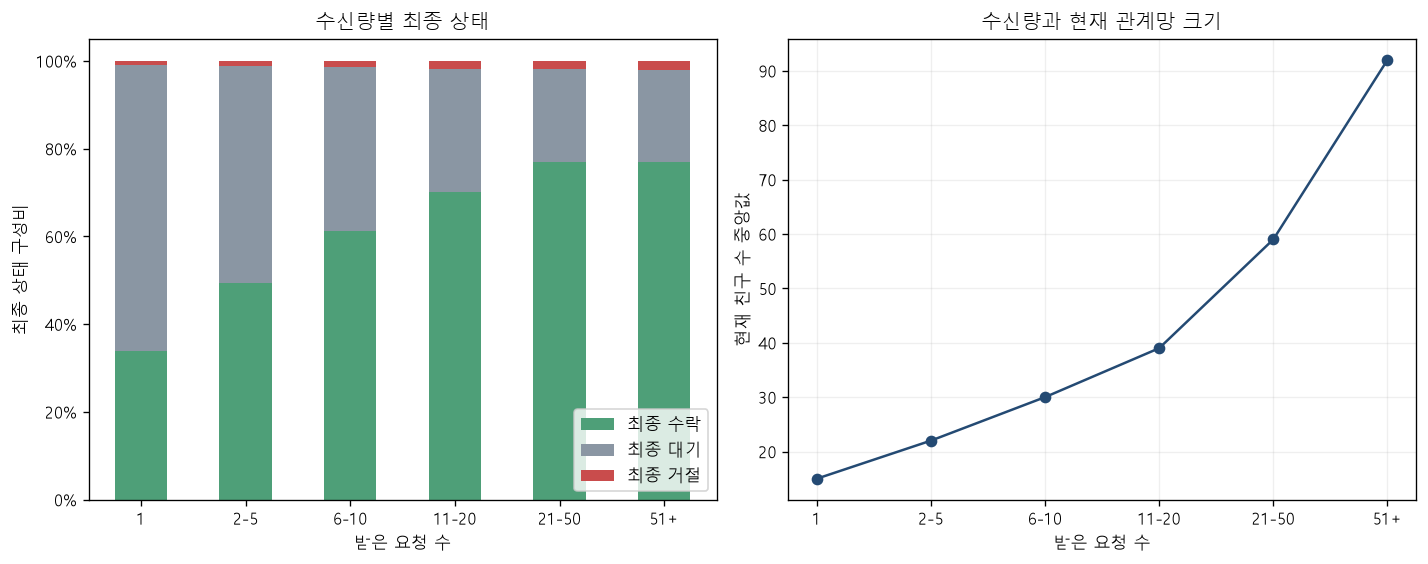

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/17_receiver_load_and_status.png')

In [18]:
receiver_load=con.execute('''
WITH u AS (
    SELECT *,
           CASE WHEN received_request_count=0 THEN '0'
                WHEN received_request_count=1 THEN '1'
                WHEN received_request_count<=5 THEN '2-5'
                WHEN received_request_count<=10 THEN '6-10'
                WHEN received_request_count<=20 THEN '11-20'
                WHEN received_request_count<=50 THEN '21-50'
                ELSE '51+' END AS load_band
    FROM profile WHERE analysis_eligible_nonstaff_flag=1
)
SELECT load_band,COUNT(*) AS users,SUM(received_request_count) AS requests,
       SUM(received_final_accepted_count) AS accepted,
       SUM(received_final_pending_count) AS pending,
       SUM(received_final_rejected_count) AS rejected,
       MEDIAN(CASE WHEN received_request_count>0 THEN received_final_accepted_count*1.0/received_request_count END) AS median_user_acceptance,
       MEDIAN(current_friend_list_length) AS median_current_friends
FROM u GROUP BY 1
''').fetchdf()
load_order=["0","1","2-5","6-10","11-20","21-50","51+"]
receiver_load["load_band"]=pd.Categorical(receiver_load.load_band,load_order,ordered=True)
receiver_load=receiver_load.sort_values("load_band")
denom=receiver_load.requests.replace(0,np.nan)
receiver_load["accepted_share"]=receiver_load.accepted/denom
receiver_load["pending_share"]=receiver_load.pending/denom
receiver_load["rejected_share"]=receiver_load.rejected/denom
save_table(receiver_load,"17_receiver_load_status_composition.csv")

load_tab=receiver_load[receiver_load.load_band.ne("0")].set_index("load_band")[["accepted","pending","rejected"]]
chi2,p,dof,expected=stats.chi2_contingency(load_tab)
n=load_tab.to_numpy().sum(); cv=math.sqrt(chi2/(n*min(load_tab.shape[0]-1,load_tab.shape[1]-1)))
receiver_test=pd.DataFrame([{"test":"수신량 구간×최종 상태","chi2":chi2,"p_value":p,"cramers_v":cv,
                            "accepted_share_at_1":float(receiver_load.loc[receiver_load.load_band.eq("1"),"accepted_share"].iloc[0]),
                            "accepted_share_at_21_50":float(receiver_load.loc[receiver_load.load_band.eq("21-50"),"accepted_share"].iloc[0])}])
save_table(receiver_test,"17_receiver_load_test.csv")
display(receiver_load.round(4))
display(receiver_test.round(4))

chart=receiver_load[receiver_load.load_band.ne("0")].set_index("load_band")
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
chart[["accepted_share","pending_share","rejected_share"]].plot(kind="bar",stacked=True,ax=axes[0],
    color=[COLORS["green"],COLORS["gray"],COLORS["red"]])
axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].tick_params(axis="x",rotation=0)
axes[0].set_xlabel("받은 요청 수"); axes[0].set_ylabel("최종 상태 구성비"); axes[0].set_title("수신량별 최종 상태")
axes[0].legend(["최종 수락","최종 대기","최종 거절"],loc="lower right")
axes[1].plot(chart.index.astype(str),chart.median_current_friends,marker="o",color=COLORS["navy"])
axes[1].set_xlabel("받은 요청 수"); axes[1].set_ylabel("현재 친구 수 중앙값"); axes[1].set_title("수신량과 현재 관계망 크기")
axes[1].grid(alpha=.2)
savefig("17_receiver_load_and_status.png")

## 18. 최종 상태 갱신 지연

최종 수락 요청의 `created_at → updated_at`을 상태 갱신 지연의 대리값으로 계산한다. 실제 수락 시각이나 Viral Cycle Time으로 해석하지 않는다.


,phase,same_school_current_flag,accepted_requests,median_delay_hours,p75_delay_hours,p90_delay_hours,within_3h_share,within_24h_share
0,early,0,1326705,5.9464,22.6228,73.1853,0.3927,0.7638
1,early,1,6900905,3.8539,19.2836,64.4664,0.4623,0.7937
2,late,0,335659,13.1242,45.8528,122.8585,0.2681,0.6306
3,late,1,997060,12.3240,46.0392,135.8693,0.2865,0.6357
4,pre,0,146822,7.9781,28.0879,92.9338,0.3650,0.7222
5,pre,1,280513,26.8617,81.7631,160.2070,0.2018,0.4721


,phase,accepted_requests,median_delay_hours,p90_delay_hours,within_3h_share,within_24h_share
0,early,8227610,4.1558,66.4059,0.4511,0.7889
1,late,1332719,12.5458,132.0713,0.2819,0.6344
2,pre,427335,19.3236,143.1328,0.2579,0.5581


,comparison,schools,median_before,median_after,median_difference,share_delay_increased,wilcoxon_p
0,pre→early,3246,23.4535,5.5907,-16.9532,0.1285,0.0000
1,early→late,3630,5.3031,20.1658,13.5542,0.9317,0.0000


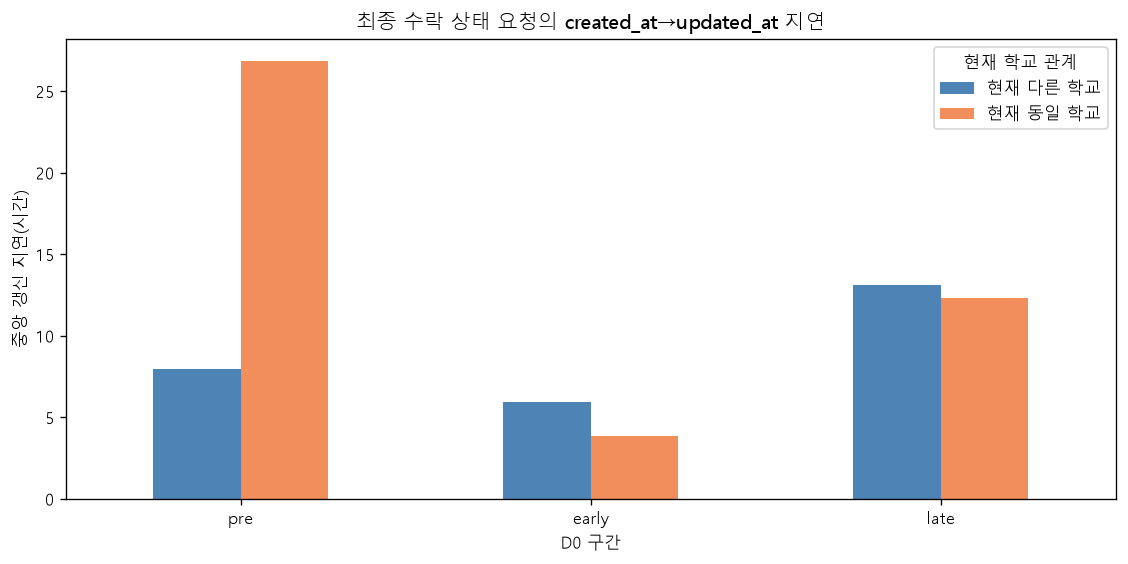

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/18_accepted_status_update_delay.png')

In [19]:
accepted_delay=con.execute(f'''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), x AS (
    SELECT e.sender_current_school_id AS school_id,e.same_school_current_flag,
           DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           e.created_to_last_update_seconds AS delay_seconds
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1 AND e.final_status_code='A'
      AND e.created_to_last_update_seconds>=0
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
), labeled AS (
    SELECT *,CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                  WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                  WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase
    FROM x WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
)
SELECT phase,same_school_current_flag,COUNT(*) AS accepted_requests,
       MEDIAN(delay_seconds)/3600 AS median_delay_hours,
       QUANTILE_CONT(delay_seconds,.75)/3600 AS p75_delay_hours,
       QUANTILE_CONT(delay_seconds,.9)/3600 AS p90_delay_hours,
       AVG(CASE WHEN delay_seconds<=10800 THEN 1.0 ELSE 0 END) AS within_3h_share,
       AVG(CASE WHEN delay_seconds<=86400 THEN 1.0 ELSE 0 END) AS within_24h_share
FROM labeled GROUP BY 1,2 ORDER BY 1,2
''').fetchdf()
save_table(accepted_delay,"18_accepted_status_update_delay.csv")

accepted_delay_overall=con.execute(f'''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), x AS (
    SELECT DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           e.created_to_last_update_seconds AS delay_seconds
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1 AND e.final_status_code='A'
      AND e.created_to_last_update_seconds>=0
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
), labeled AS (
    SELECT *,CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                  WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                  WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase
    FROM x WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
)
SELECT phase,COUNT(*) AS accepted_requests,MEDIAN(delay_seconds)/3600 AS median_delay_hours,
       QUANTILE_CONT(delay_seconds,.9)/3600 AS p90_delay_hours,
       AVG(CASE WHEN delay_seconds<=10800 THEN 1.0 ELSE 0 END) AS within_3h_share,
       AVG(CASE WHEN delay_seconds<=86400 THEN 1.0 ELSE 0 END) AS within_24h_share
FROM labeled GROUP BY 1 ORDER BY 1
''').fetchdf()
save_table(accepted_delay_overall,"18_accepted_status_update_delay_overall.csv")

delay_school=con.execute(f'''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), x AS (
    SELECT e.sender_current_school_id AS school_id,
           DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           e.created_to_last_update_seconds AS delay_seconds
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1 AND e.final_status_code='A'
      AND e.created_to_last_update_seconds>=0
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
)
SELECT school_id,CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                      WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                      WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase,
       MEDIAN(delay_seconds)/3600 AS median_delay_hours,COUNT(*) AS accepted_requests
FROM x
WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
GROUP BY 1,2 HAVING COUNT(*)>=5
''').fetchdf()
delay_wide=delay_school.pivot(index="school_id",columns="phase",values="median_delay_hours")
delay_tests=[]
for a,b in [("pre","early"),("early","late")]:
    z=delay_wide[[a,b]].dropna(); diff=(z[b]-z[a]).to_numpy(); nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    delay_tests.append({"comparison":f"{a}→{b}","schools":len(z),"median_before":z[a].median(),
                        "median_after":z[b].median(),"median_difference":np.median(diff),
                        "share_delay_increased":np.mean(diff>0),"wilcoxon_p":p})
delay_tests=pd.DataFrame(delay_tests)
save_table(delay_tests,"18_accepted_delay_paired_tests.csv")
display(accepted_delay.round(4))
display(accepted_delay_overall.round(4))
display(delay_tests.round(4))

delay_chart=accepted_delay.copy()
delay_chart["relation"]=delay_chart.same_school_current_flag.map({1:"현재 동일 학교",0:"현재 다른 학교"})
dc=delay_chart.pivot(index="phase",columns="relation",values="median_delay_hours").reindex(["pre","early","late"])
dc.plot(kind="bar",figsize=(9.5,4.8),color=[COLORS["blue"],COLORS["orange"]])
plt.xticks(rotation=0); plt.xlabel("D0 구간"); plt.ylabel("중앙 갱신 지연(시간)")
plt.title("최종 수락 상태 요청의 created_at→updated_at 지연")
plt.legend(title="현재 학교 관계")
savefig("18_accepted_status_update_delay.png")

## 19. 초기 요청 강도와 후기 활동

D+1~+7 요청 강도 구간별 D+8~+14 절대 요청 수준과 유지비를 비교한다.


,early_intensity_quintile,schools,early_request_rate_median,late_request_rate_median,retention_ratio_median,early_sender_reach_median,early_acceptance_median,early_same_school_median,early_new_user_rate_median
0,Q1 낮음,757,605.3097,152.9412,0.2811,85.1852,0.6688,0.7724,22.7273
1,Q2,757,"1,143.0622",218.4211,0.1935,135.7143,0.7638,0.7887,40.0000
2,Q3,756,"1,495.1279",223.1667,0.1524,158.1602,0.7741,0.8416,47.7648
3,Q4,757,"1,862.4506",206.0086,0.1117,176.4706,0.7776,0.8760,55.1351
4,Q5 높음,757,"2,423.1156",210.3226,0.0856,195.6044,0.7793,0.9067,62.6016


,schools,spearman_early_vs_late_absolute,p_early_vs_late_absolute,spearman_early_vs_retention_ratio,p_early_vs_retention_ratio,late_absolute_kruskal_h,late_absolute_kruskal_p,temporal_holdout_r2_from_section11
0,3784,0.0546,0.0008,-0.3977,0.0000,49.4337,0.0000,-0.9614


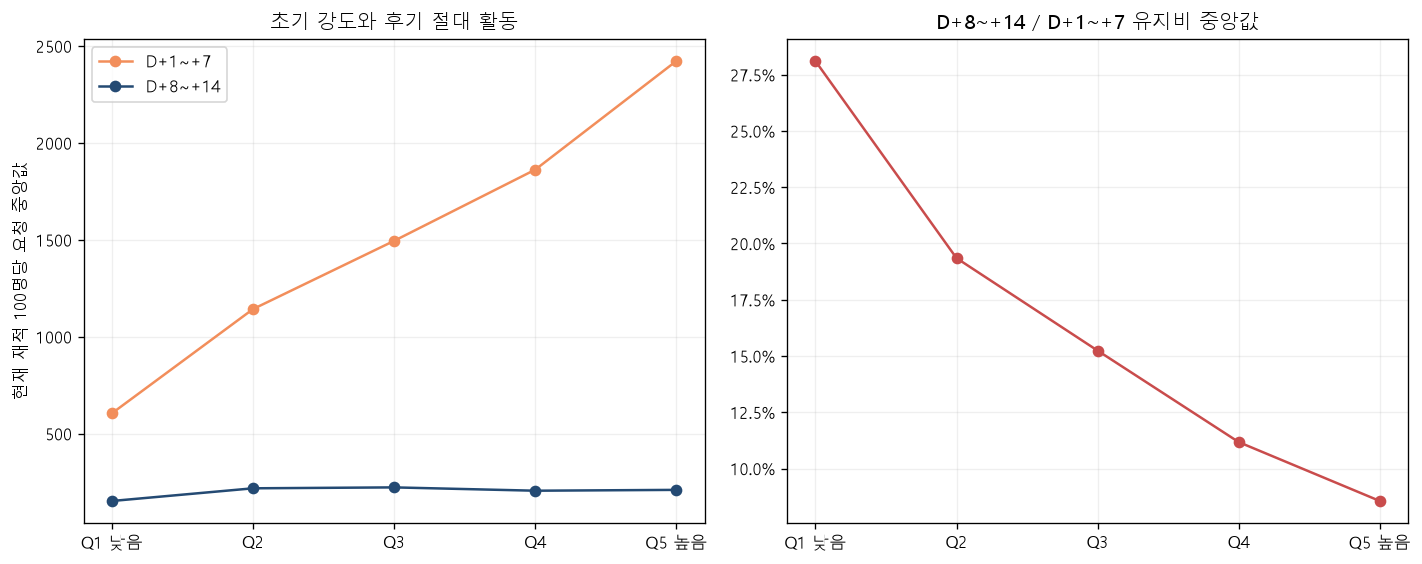

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/19_burst_size_vs_persistence.png')

In [20]:
persistence=wide.dropna(subset=["requests_per_100_roster_early","requests_per_100_roster_late"]).copy()
persistence=persistence[persistence.requests_per_100_roster_early>0].copy()
persistence["early_intensity_quintile"]=pd.qcut(persistence.requests_per_100_roster_early,5,
    labels=["Q1 낮음","Q2","Q3","Q4","Q5 높음"])
persistence["late_to_early_ratio"]=persistence.requests_per_100_roster_late/persistence.requests_per_100_roster_early
persistence_summary=(persistence.groupby("early_intensity_quintile",observed=True)
                     .agg(schools=("school_id","size"),
                          early_request_rate_median=("requests_per_100_roster_early","median"),
                          late_request_rate_median=("requests_per_100_roster_late","median"),
                          retention_ratio_median=("late_to_early_ratio","median"),
                          early_sender_reach_median=("sender_days_per_100_roster_early","median"),
                          early_acceptance_median=("eventual_acceptance_share_early","median"),
                          early_same_school_median=("same_school_share_early","median"),
                          early_new_user_rate_median=("new_users_per_100_roster_early","median"))
                     .reset_index())
save_table(persistence_summary,"19_early_intensity_quintile_persistence.csv")

rho_abs,p_abs=stats.spearmanr(persistence.requests_per_100_roster_early,persistence.requests_per_100_roster_late)
rho_ratio,p_ratio=stats.spearmanr(persistence.requests_per_100_roster_early,persistence.late_to_early_ratio)
groups=[g.requests_per_100_roster_late.to_numpy() for _,g in persistence.groupby("early_intensity_quintile",observed=True)]
kw,p_kw=stats.kruskal(*groups)
persistence_test=pd.DataFrame([{"schools":len(persistence),
    "spearman_early_vs_late_absolute":rho_abs,"p_early_vs_late_absolute":p_abs,
    "spearman_early_vs_retention_ratio":rho_ratio,"p_early_vs_retention_ratio":p_ratio,
    "late_absolute_kruskal_h":kw,"late_absolute_kruskal_p":p_kw,
    "temporal_holdout_r2_from_section11":float(model_quality.test_r2.iloc[0])}])
save_table(persistence_test,"19_burst_persistence_tests.csv")
display(persistence_summary.round(4))
display(persistence_test.round(4))

x=np.arange(len(persistence_summary))
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
axes[0].plot(x,persistence_summary.early_request_rate_median,marker="o",label="D+1~+7",color=COLORS["orange"])
axes[0].plot(x,persistence_summary.late_request_rate_median,marker="o",label="D+8~+14",color=COLORS["navy"])
axes[0].set_xticks(x,persistence_summary.early_intensity_quintile.astype(str)); axes[0].legend()
axes[0].set_ylabel("현재 재적 100명당 요청 중앙값"); axes[0].set_title("초기 강도와 후기 절대 활동")
axes[1].plot(x,persistence_summary.retention_ratio_median,marker="o",color=COLORS["red"])
axes[1].set_xticks(x,persistence_summary.early_intensity_quintile.astype(str))
axes[1].yaxis.set_major_formatter(PercentFormatter(1)); axes[1].set_title("D+8~+14 / D+1~+7 유지비 중앙값")
for ax in axes: ax.grid(alpha=.2)
savefig("19_burst_size_vs_persistence.png")

## 20. 위약검정과 기간 민감도

가짜 기준일과 3일·5일·7일 분석창으로 D0 전후 결과의 강건성을 확인한다.


,anchor_offset,metric,schools,median_difference,mean_difference,share_increased,wilcoxon_p
0,0,requests_per_100,3896,"1,385.9082","1,358.0509",0.9394,0.0000
1,0,sender_days_per_100,3896,142.9198,129.9043,0.9523,0.0000
2,0,national_share,3896,516.1239,952.9397,0.9374,0.0000
3,21,requests_per_100,3896,-42.6018,-72.1036,0.1088,0.0000
4,21,sender_days_per_100,3896,-8.8186,-11.8059,0.0480,0.0000
5,21,national_share,3896,-2.3743,2.8390,0.4636,0.1342
6,28,requests_per_100,3896,-12.1584,-27.3080,0.1301,0.0000
7,28,sender_days_per_100,3896,-3.5211,-4.7889,0.0603,0.0000
8,28,national_share,3896,-3.9528,25.1182,0.4073,0.0059
9,35,requests_per_100,3896,-2.4019,-9.3744,0.1702,0.0000


,horizon_days,metric,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,3,requests_per_100_roster,3792,45.3203,953.3444,862.4162,0.9072,0.0000
1,3,sender_days_per_100_roster,3792,8.6048,90.5933,79.1438,0.9169,0.0000
2,5,requests_per_100_roster,3792,54.1886,"1,284.4281","1,190.5974",0.9277,0.0000
3,5,sender_days_per_100_roster,3792,10.1707,129.8851,117.3831,0.9372,0.0000
4,7,requests_per_100_roster,3792,59.2243,"1,493.0024","1,393.4279",0.9380,0.0000
5,7,sender_days_per_100_roster,3792,11.1111,156.9482,143.2836,0.9507,0.0000


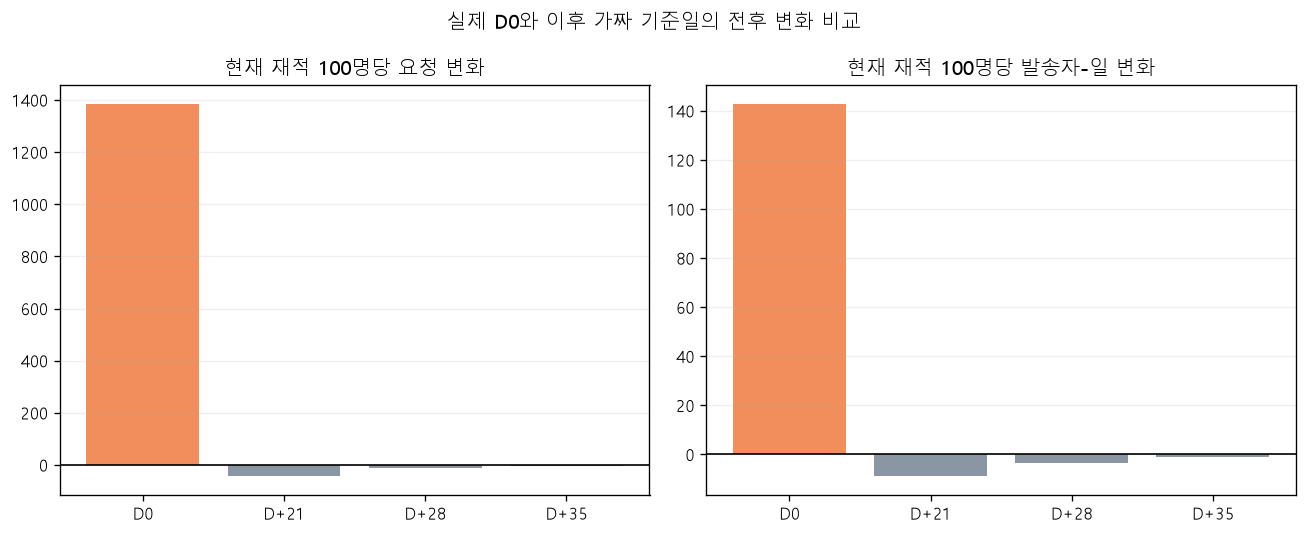

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/20_d0_placebo_comparison.png')

In [21]:
placebo_school=con.execute('''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date,
           MAX(current_roster_nonstaff_account_count) AS roster_size
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), national AS (
    SELECT CAST(activity_date AS DATE) AS activity_date,SUM(sent_request_created_count) AS national_requests
    FROM school_daily WHERE analysis_eligible_school_day_flag=1 GROUP BY 1
), offsets AS (
    SELECT * FROM (VALUES (0),(21),(28),(35)) AS t(anchor_offset)
), joined AS (
    SELECT d.school_id,o.anchor_offset,
           DATE_DIFF('day',CAST(d.d0_date+o.anchor_offset*INTERVAL 1 DAY AS DATE),CAST(s.activity_date AS DATE)) AS rel_day,
           100.0*s.sent_request_created_count/NULLIF(d.roster_size,0) AS requests_per_100_day,
           100.0*s.sent_request_user_count/NULLIF(d.roster_size,0) AS sender_days_per_100_day,
           1000000.0*s.sent_request_created_count/NULLIF(n.national_requests,0) AS national_share_per_million
    FROM d0 d CROSS JOIN offsets o
    JOIN school_daily s ON s.school_id=d.school_id
    JOIN national n ON CAST(s.activity_date AS DATE)=n.activity_date
    WHERE DATE_DIFF('day',CAST(d.d0_date+o.anchor_offset*INTERVAL 1 DAY AS DATE),CAST(s.activity_date AS DATE)) BETWEEN -7 AND 7
)
SELECT school_id,anchor_offset,
       SUM(CASE WHEN rel_day BETWEEN -7 AND -1 THEN requests_per_100_day ELSE 0 END) AS pre_requests_per_100,
       SUM(CASE WHEN rel_day BETWEEN 1 AND 7 THEN requests_per_100_day ELSE 0 END) AS post_requests_per_100,
       SUM(CASE WHEN rel_day BETWEEN -7 AND -1 THEN sender_days_per_100_day ELSE 0 END) AS pre_sender_days_per_100,
       SUM(CASE WHEN rel_day BETWEEN 1 AND 7 THEN sender_days_per_100_day ELSE 0 END) AS post_sender_days_per_100,
       AVG(CASE WHEN rel_day BETWEEN -7 AND -1 THEN national_share_per_million END) AS pre_national_share,
       AVG(CASE WHEN rel_day BETWEEN 1 AND 7 THEN national_share_per_million END) AS post_national_share,
       COUNT(CASE WHEN rel_day BETWEEN -7 AND -1 THEN 1 END) AS pre_days,
       COUNT(CASE WHEN rel_day BETWEEN 1 AND 7 THEN 1 END) AS post_days
FROM joined GROUP BY 1,2
HAVING pre_days=7 AND post_days=7
''').fetchdf()
save_table(placebo_school,"20_placebo_school_level.csv")

placebo_rows=[]
for offset,g in placebo_school.groupby("anchor_offset"):
    for stem in ["requests_per_100","sender_days_per_100","national_share"]:
        diff=(g[f"post_{stem}"]-g[f"pre_{stem}"]).dropna().to_numpy()
        nz=diff[diff!=0]; stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
        placebo_rows.append({"anchor_offset":offset,"metric":stem,"schools":len(diff),
                             "median_difference":np.median(diff),"mean_difference":np.mean(diff),
                             "share_increased":np.mean(diff>0),"wilcoxon_p":p})
placebo_tests=pd.DataFrame(placebo_rows)
save_table(placebo_tests,"20_placebo_tests.csv")

sensitivity_rows=[]
for horizon in [3,5,7]:
    for metric in ["requests_per_100_roster","sender_days_per_100_roster"]:
        pre=(school_event[school_event.rel_day.between(-horizon,-1)]
             .groupby("school_id")[metric].sum())
        post=(school_event[school_event.rel_day.between(1,horizon)]
              .groupby("school_id")[metric].sum())
        z=pd.concat([pre.rename("pre"),post.rename("post")],axis=1).dropna()
        diff=(z.post-z.pre).to_numpy(); nz=diff[diff!=0]
        stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
        sensitivity_rows.append({"horizon_days":horizon,"metric":metric,"schools":len(z),
                                 "median_before":z.pre.median(),"median_after":z.post.median(),
                                 "median_difference":np.median(diff),"share_increased":np.mean(diff>0),
                                 "wilcoxon_p":p})
sensitivity_tests=pd.DataFrame(sensitivity_rows)
save_table(sensitivity_tests,"20_window_sensitivity_tests.csv")
display(placebo_tests.round(4))
display(sensitivity_tests.round(4))

pp=placebo_tests[placebo_tests.metric.isin(["requests_per_100","sender_days_per_100"])].copy()
fig,axes=plt.subplots(1,2,figsize=(11,4.5))
for ax,(metric,title) in zip(axes,[("requests_per_100","현재 재적 100명당 요청 변화"),
                                  ("sender_days_per_100","현재 재적 100명당 발송자-일 변화")]):
    q=pp[pp.metric.eq(metric)].sort_values("anchor_offset")
    colors=[COLORS["orange"] if x==0 else COLORS["gray"] for x in q.anchor_offset]
    anchor_labels=["D0" if x==0 else f"D+{x}" for x in q.anchor_offset]
    ax.bar(anchor_labels,q.median_difference,color=colors)
    ax.axhline(0,color="black",lw=1); ax.set_title(title); ax.grid(axis="y",alpha=.2)
plt.suptitle("실제 D0와 이후 가짜 기준일의 전후 변화 비교")
savefig("20_d0_placebo_comparison.png")

## 21. 네트워크 정의와 QA

- 노드: 현재 학교가 확인되는 비직원 사용자
- 무방향 링크: 동일 학교 사용자 사이의 최종 수락 고유 사용자쌍
- 방향 링크: 발송자→수신자 고유 요청 방향
- 요청이 없는 사용자도 고립 노드로 포함한다.


,node_count,school_count,accepted_undirected_edge_count,self_edges,duplicated_edges,cross_school_edges
0,677080,5551,10377675,0,0,0


,count,mean,std,min,10%,25%,50%,75%,90%,max
n_users,"3,897.0000",168.2063,86.7647,40.0000,67.0000,100.0000,154.0000,225.0000,288.0000,578.0000
accepted_edge_count,"3,897.0000","2,650.7873","1,938.8291",11.0000,547.6000,"1,092.0000","2,239.0000","3,824.0000","5,388.2000","15,197.0000"
active_user_share,"3,897.0000",0.9556,0.0451,0.3542,0.9129,0.9481,0.9671,0.9798,0.9889,1.0000
isolate_share,"3,897.0000",0.0444,0.0451,0.0000,0.0111,0.0202,0.0329,0.0519,0.0871,0.6458
average_degree,"3,897.0000",28.9524,11.9326,0.5238,13.3552,20.2922,28.7303,37.2449,44.3218,80.5063
density,"3,897.0000",0.2053,0.1122,0.0128,0.0907,0.1211,0.1802,0.2626,0.3564,0.8038
largest_component_share,"3,897.0000",0.9525,0.0534,0.1429,0.9058,0.9455,0.9659,0.9796,0.9887,1.0000
component_count,"3,897.0000",7.3803,4.5133,1.0000,2.0000,4.0000,7.0000,10.0000,13.0000,37.0000
degree_gini,"3,897.0000",0.3526,0.0644,0.1122,0.2796,0.3133,0.3478,0.3877,0.4303,0.7758
degree_centralization,"3,897.0000",0.3618,0.1029,0.0852,0.2263,0.2861,0.3616,0.4371,0.4945,0.6579


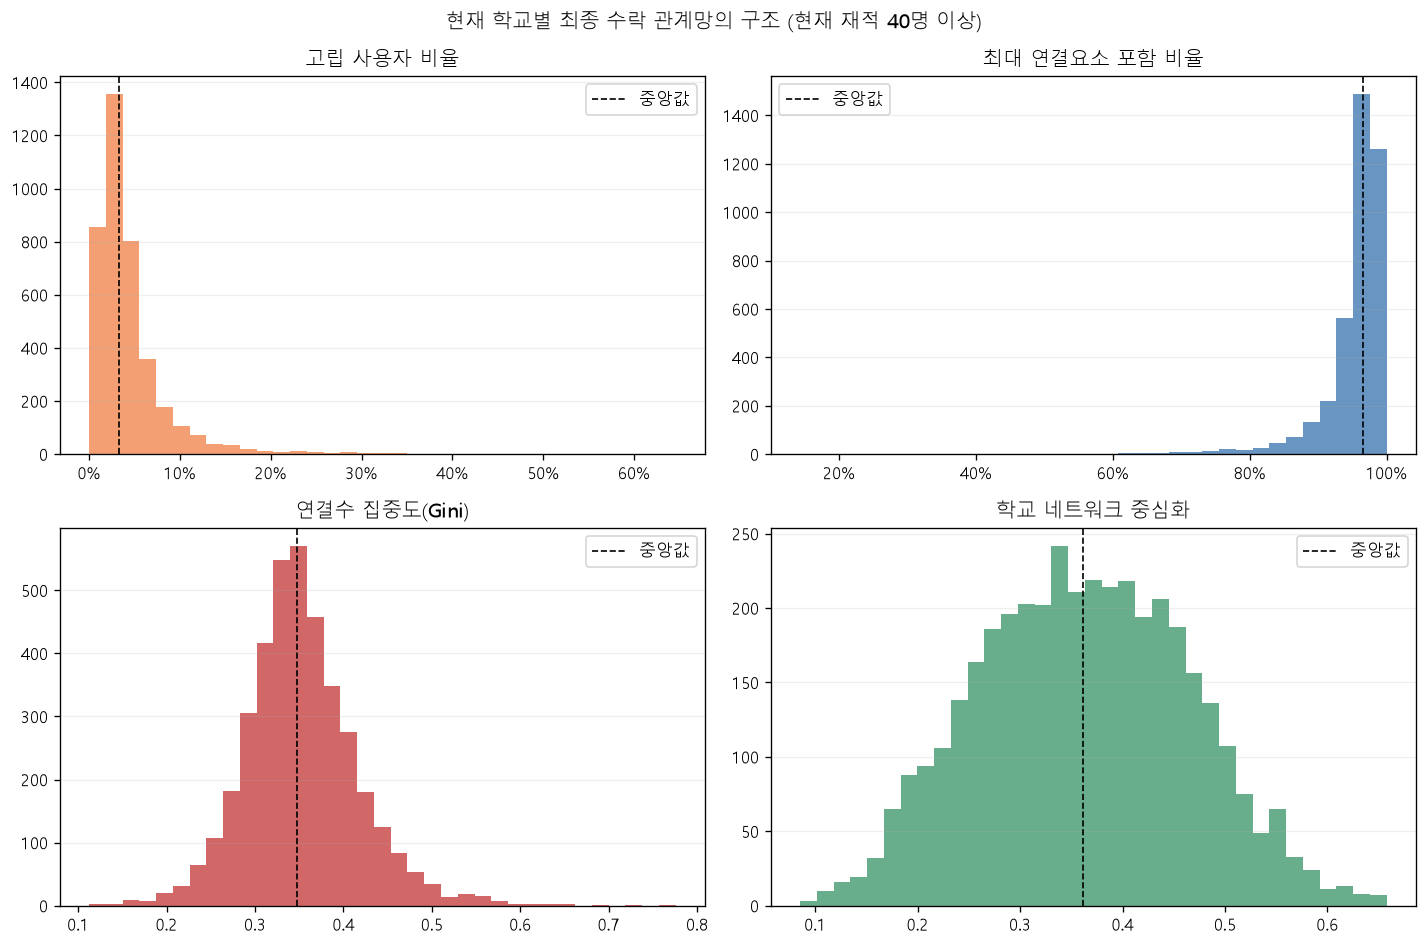

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/21_school_network_structure.png')

In [22]:
con.execute('''
CREATE OR REPLACE TEMP TABLE graph_nodes AS
SELECT
    CAST(user_id AS BIGINT) AS user_id,
    CAST(current_school_id AS BIGINT) AS school_id,
    TRY_CAST(current_grade AS BIGINT) AS current_grade,
    TRY_CAST(current_class_num AS BIGINT) AS current_class_num,
    TRY_CAST(current_group_id AS BIGINT) AS current_group_id,
    TRY_CAST(signup_at AS TIMESTAMP) AS signup_at,
    CAST(ROW_NUMBER() OVER (ORDER BY user_id)-1 AS INTEGER) AS node_idx
FROM profile
WHERE analysis_eligible_nonstaff_flag=1
  AND current_school_id IS NOT NULL
''')

con.execute('''
CREATE OR REPLACE TEMP TABLE accepted_school_edges AS
SELECT DISTINCT
    ns.school_id,
    LEAST(ns.node_idx,nr.node_idx)::INTEGER AS u_idx,
    GREATEST(ns.node_idx,nr.node_idx)::INTEGER AS v_idx,
    LEAST(p.send_user_id,p.receive_user_id)::BIGINT AS user_a,
    GREATEST(p.send_user_id,p.receive_user_id)::BIGINT AS user_b
FROM pair p
JOIN graph_nodes ns ON ns.user_id=p.send_user_id
JOIN graph_nodes nr ON nr.user_id=p.receive_user_id
WHERE p.analysis_eligible_pair_flag=1
  AND p.same_school_current_flag=1
  AND p.final_accepted_record_count>0
  AND ns.school_id=nr.school_id
  AND ns.node_idx<>nr.node_idx
''')

graph_qa=con.execute('''
SELECT
  (SELECT COUNT(*) FROM graph_nodes) AS node_count,
  (SELECT COUNT(DISTINCT school_id) FROM graph_nodes) AS school_count,
  (SELECT COUNT(*) FROM accepted_school_edges) AS accepted_undirected_edge_count,
  (SELECT COUNT(*) FROM accepted_school_edges WHERE u_idx=v_idx) AS self_edges,
  (SELECT COUNT(*) FROM (
     SELECT u_idx,v_idx,COUNT(*) n FROM accepted_school_edges GROUP BY 1,2 HAVING n>1
   )) AS duplicated_edges,
  (SELECT COUNT(*) FROM accepted_school_edges e
     JOIN graph_nodes a ON a.node_idx=e.u_idx
     JOIN graph_nodes b ON b.node_idx=e.v_idx
   WHERE a.school_id<>b.school_id OR a.school_id<>e.school_id) AS cross_school_edges
''').fetchdf()

assert int(graph_qa.self_edges.iloc[0])==0
assert int(graph_qa.duplicated_edges.iloc[0])==0
assert int(graph_qa.cross_school_edges.iloc[0])==0
save_table(graph_qa,"21_graph_definition_qa.csv")
display(graph_qa)

node_graph=con.execute('''
SELECT node_idx,user_id,school_id,current_grade,current_class_num,current_group_id,signup_at
FROM graph_nodes ORDER BY node_idx
''').fetchdf()
edge_np=con.execute('SELECT u_idx,v_idx FROM accepted_school_edges ORDER BY u_idx,v_idx').fetchnumpy()
edge_u=edge_np["u_idx"].astype(np.int32,copy=False)
edge_v=edge_np["v_idx"].astype(np.int32,copy=False)
n_nodes=len(node_graph)
rows=np.concatenate([edge_u,edge_v])
cols=np.concatenate([edge_v,edge_u])
accepted_adj=sparse.csr_matrix((np.ones(len(rows),dtype=np.uint8),(rows,cols)),shape=(n_nodes,n_nodes))
accepted_adj.sum_duplicates()
accepted_adj.data[:]=1
del rows,cols,edge_np

_,component_label=connected_components(accepted_adj,directed=False,return_labels=True)
accepted_degree=np.diff(accepted_adj.indptr).astype(np.int32)
node_graph["accepted_degree"]=accepted_degree
node_graph["component_label"]=component_label
node_graph["active_node_flag"]=(accepted_degree>0).astype(int)

component_sizes=(node_graph.groupby(["school_id","component_label"],as_index=False)
                 .size().rename(columns={"size":"component_size"}))
largest_component=(component_sizes.groupby("school_id",as_index=False).component_size.max()
                   .rename(columns={"component_size":"largest_component_users"}))
component_count=(component_sizes.groupby("school_id",as_index=False).size()
                 .rename(columns={"size":"component_count"}))

def degree_gini(values):
    x=np.asarray(values,dtype=float)
    if len(x)==0 or x.sum()==0:
        return 0.0
    x=np.sort(x)
    return float((2*np.arange(1,len(x)+1)-len(x)-1).dot(x)/(len(x)*x.sum()))

school_structure=(node_graph.groupby("school_id",as_index=False)
                  .agg(n_users=("user_id","size"),
                       active_users=("active_node_flag","sum"),
                       total_degree=("accepted_degree","sum"),
                       max_degree=("accepted_degree","max"),
                       median_degree=("accepted_degree","median")))
degree_gini_school=(node_graph.groupby("school_id").accepted_degree.apply(degree_gini)
                    .rename("degree_gini").reset_index())
school_structure=(school_structure.merge(largest_component,on="school_id",how="left")
                  .merge(component_count,on="school_id",how="left")
                  .merge(degree_gini_school,on="school_id",how="left"))
school_structure["accepted_edge_count"]=(school_structure.total_degree//2).astype(np.int64)
school_structure["isolated_users"]=school_structure.n_users-school_structure.active_users
school_structure["active_user_share"]=school_structure.active_users/school_structure.n_users
school_structure["isolate_share"]=school_structure.isolated_users/school_structure.n_users
school_structure["average_degree"]=school_structure.total_degree/school_structure.n_users
school_structure["density"]=np.where(
    school_structure.n_users>1,
    school_structure.total_degree/(school_structure.n_users*(school_structure.n_users-1)),np.nan)
school_structure["largest_component_share"]=school_structure.largest_component_users/school_structure.n_users
school_structure["fragmentation_share"]=1-school_structure.largest_component_share
school_structure["degree_centralization"]=np.where(
    school_structure.n_users>2,
    (school_structure.n_users*school_structure.max_degree-school_structure.total_degree)/
    ((school_structure.n_users-1)*(school_structure.n_users-2)),np.nan)

d0_flags=con.execute('''
SELECT school_id,
       MAX(current_roster_reached_40_flag) AS reached_40_flag,
       MAX(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS d0_at
FROM school_daily GROUP BY 1
''').fetchdf()
school_structure=school_structure.merge(d0_flags,on="school_id",how="left")
school_structure["reached_40_flag"]=school_structure.reached_40_flag.fillna(0).astype(int)
save_table(school_structure,"21_school_network_structure_metrics.csv")

structure_summary=(school_structure[school_structure.n_users>=40]
                   [["n_users","accepted_edge_count","active_user_share","isolate_share",
                     "average_degree","density","largest_component_share","component_count",
                     "degree_gini","degree_centralization"]]
                   .describe(percentiles=[.1,.25,.5,.75,.9]).T)
save_table(structure_summary.reset_index().rename(columns={"index":"metric"}),
           "21_school_network_structure_summary.csv")
display(structure_summary.round(4))

plot_structure=school_structure[school_structure.n_users>=40].copy()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,(col,title,color) in zip(axes.ravel(),[
    ("isolate_share","고립 사용자 비율",COLORS["orange"]),
    ("largest_component_share","최대 연결요소 포함 비율",COLORS["blue"]),
    ("degree_gini","연결수 집중도(Gini)",COLORS["red"]),
    ("degree_centralization","학교 네트워크 중심화",COLORS["green"]) ]):
    ax.hist(plot_structure[col].dropna(),bins=35,color=color,alpha=.85)
    ax.axvline(plot_structure[col].median(),color="black",ls="--",lw=1,label="중앙값")
    ax.set_title(title); ax.legend(); ax.grid(axis="y",alpha=.2)
    if "share" in col: ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.suptitle("현재 학교별 최종 수락 관계망의 구조 (현재 재적 40명 이상)")
savefig("21_school_network_structure.png")

## 22. 역방향·반복 요청

단방향 요청, 반복 요청, 역방향 요청의 구조를 확인한다. 역방향 요청 비중은 관계 품질 KPI로 사용하지 않는다.


,predictor,outcome,schools,spearman_rho,p_value
0,reciprocal_request_pair_share,largest_component_share,3897,0.1798,0.0000
1,reciprocal_request_pair_share,isolate_share,3897,-0.1843,0.0000
2,reciprocal_request_pair_share,degree_gini,3897,-0.1455,0.0000
3,reciprocal_request_pair_share,degree_centralization,3897,0.0690,0.0000


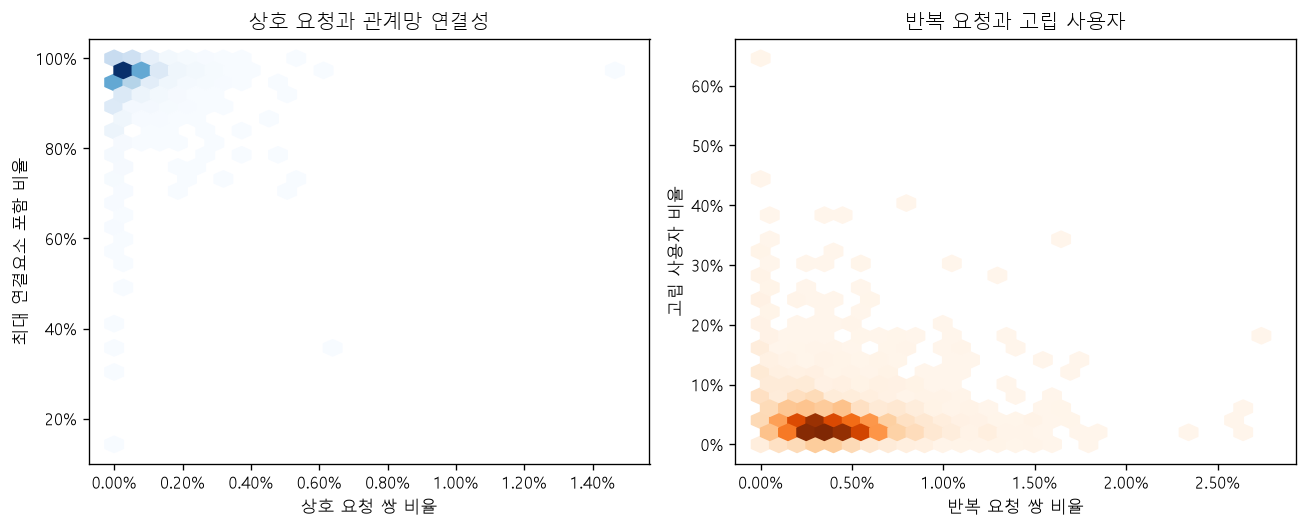

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/22_reciprocity_and_structure.png')

In [23]:
reciprocity=con.execute('''
WITH directional AS (
  SELECT
    sender_current_school_id AS school_id,
    LEAST(send_user_id,receive_user_id) AS user_a,
    GREATEST(send_user_id,receive_user_id) AS user_b,
    send_user_id,receive_user_id,
    request_record_count,
    final_accepted_record_count,
    repeated_directional_pair_flag
  FROM pair
  WHERE analysis_eligible_pair_flag=1
    AND same_school_current_flag=1
), canonical AS (
  SELECT school_id,user_a,user_b,
         COUNT(*) AS direction_count,
         SUM(request_record_count) AS request_record_count,
         SUM(CASE WHEN final_accepted_record_count>0 THEN 1 ELSE 0 END) AS accepted_direction_count,
         MAX(repeated_directional_pair_flag) AS repeated_direction_flag
  FROM directional GROUP BY 1,2,3
)
SELECT school_id,
       COUNT(*) AS request_pair_count,
       SUM(direction_count) AS directed_pair_count,
       SUM(request_record_count) AS request_record_count,
       SUM(direction_count=2)::BIGINT AS reciprocal_request_pair_count,
       SUM(accepted_direction_count>0)::BIGINT AS accepted_pair_count,
       SUM(accepted_direction_count=2)::BIGINT AS mutual_accepted_pair_count,
       SUM(repeated_direction_flag)::BIGINT AS repeated_pair_count
FROM canonical GROUP BY 1
''').fetchdf()
reciprocity["reciprocal_request_pair_share"]=reciprocity.reciprocal_request_pair_count/reciprocity.request_pair_count
reciprocity["mutual_accepted_share_among_accepted_pairs"]=reciprocity.mutual_accepted_pair_count/reciprocity.accepted_pair_count.replace(0,np.nan)
reciprocity["repeated_pair_share"]=reciprocity.repeated_pair_count/reciprocity.request_pair_count
school_structure=school_structure.merge(reciprocity,on="school_id",how="left")
fill_zero=["request_pair_count","directed_pair_count","request_record_count","reciprocal_request_pair_count",
           "accepted_pair_count","mutual_accepted_pair_count","repeated_pair_count",
           "reciprocal_request_pair_share","mutual_accepted_share_among_accepted_pairs","repeated_pair_share"]
school_structure[fill_zero]=school_structure[fill_zero].fillna(0)
save_table(reciprocity,"22_school_reciprocity_metrics.csv")

reciprocity_test_base=school_structure[(school_structure.n_users>=40)&(school_structure.request_pair_count>=20)].copy()
reciprocity_tests=[]
for outcome in ["largest_component_share","isolate_share","degree_gini","degree_centralization"]:
    rho,p=stats.spearmanr(reciprocity_test_base.reciprocal_request_pair_share,
                          reciprocity_test_base[outcome],nan_policy="omit")
    reciprocity_tests.append({"predictor":"reciprocal_request_pair_share","outcome":outcome,
                              "schools":len(reciprocity_test_base),"spearman_rho":rho,"p_value":p})
reciprocity_tests=pd.DataFrame(reciprocity_tests)
save_table(reciprocity_tests,"22_reciprocity_structure_tests.csv")
display(reciprocity_tests.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.5))
q=reciprocity_test_base
axes[0].hexbin(q.reciprocal_request_pair_share,q.largest_component_share,gridsize=28,mincnt=1,cmap="Blues")
axes[0].set_xlabel("상호 요청 쌍 비율"); axes[0].set_ylabel("최대 연결요소 포함 비율")
axes[0].xaxis.set_major_formatter(PercentFormatter(1)); axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("상호 요청과 관계망 연결성")
axes[1].hexbin(q.repeated_pair_share,q.isolate_share,gridsize=28,mincnt=1,cmap="Oranges")
axes[1].set_xlabel("반복 요청 쌍 비율"); axes[1].set_ylabel("고립 사용자 비율")
axes[1].xaxis.set_major_formatter(PercentFormatter(1)); axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title("반복 요청과 고립 사용자")
savefig("22_reciprocity_and_structure.png")

## 23. 동일 학년·반 연결과 브리지

관측된 동일 학년·반 연결 비율을 학교 구성에서 기대되는 비율과 비교한다.


,level,schools,minimum_known_edges,median_observed_share,median_expected_share,median_excess_pp,share_above_expected,wilcoxon_p
0,grade,4293,30,0.9273,0.4990,40.6333,0.9951,0.0000
1,class,4293,30,0.2730,0.0696,18.1498,0.9970,0.0000


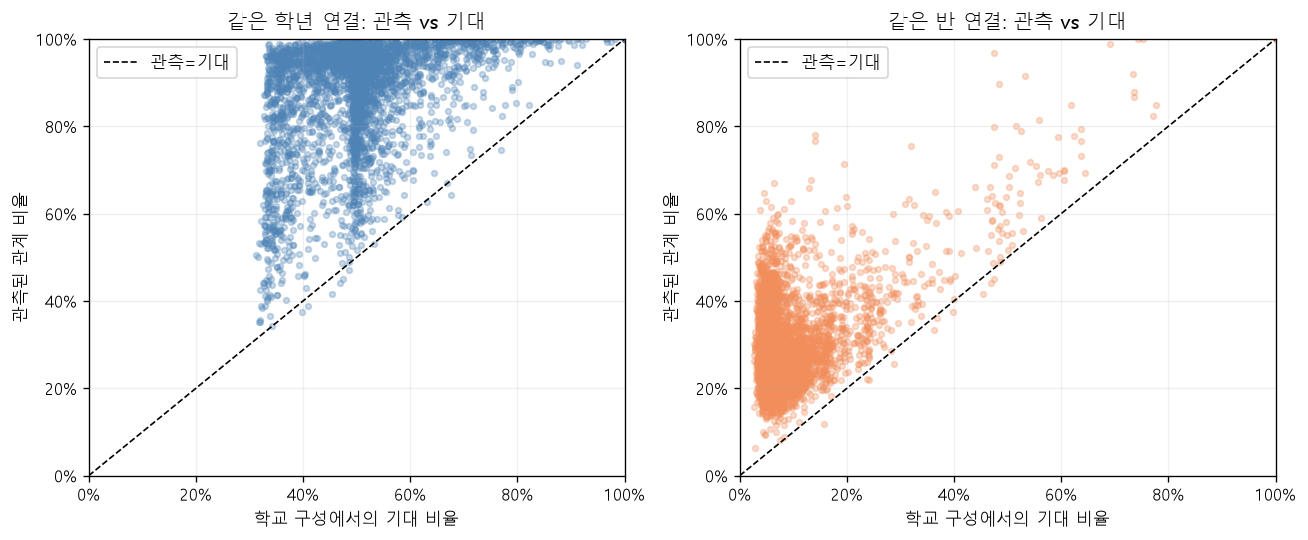

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/23_grade_class_homophily.png')

In [24]:
homophily=con.execute('''
WITH roster AS (
  SELECT school_id,
         COUNT(*) AS n_users,
         COUNT(current_grade) AS grade_known_users,
         COUNT(CASE WHEN current_grade IS NOT NULL AND current_class_num IS NOT NULL THEN 1 END) AS class_known_users
  FROM graph_nodes GROUP BY 1
), grade_group AS (
  SELECT school_id,current_grade,COUNT(*) AS n
  FROM graph_nodes WHERE current_grade IS NOT NULL GROUP BY 1,2
), class_group AS (
  SELECT school_id,current_grade,current_class_num,COUNT(*) AS n
  FROM graph_nodes
  WHERE current_grade IS NOT NULL AND current_class_num IS NOT NULL GROUP BY 1,2,3
), expected AS (
  SELECT r.school_id,r.n_users,r.grade_known_users,r.class_known_users,
         CASE WHEN r.grade_known_users>1 THEN
           (SELECT SUM(g.n*(g.n-1)) FROM grade_group g WHERE g.school_id=r.school_id)/
           (r.grade_known_users*(r.grade_known_users-1.0)) END AS expected_same_grade_share,
         CASE WHEN r.class_known_users>1 THEN
           (SELECT SUM(c.n*(c.n-1)) FROM class_group c WHERE c.school_id=r.school_id)/
           (r.class_known_users*(r.class_known_users-1.0)) END AS expected_same_class_share
  FROM roster r
), edge_relation AS (
  SELECT e.school_id,
         CASE WHEN a.current_grade IS NOT NULL AND b.current_grade IS NOT NULL THEN 1 ELSE 0 END AS grade_known,
         CASE WHEN a.current_grade IS NOT NULL AND b.current_grade IS NOT NULL
                   AND a.current_grade=b.current_grade THEN 1 ELSE 0 END AS same_grade,
         CASE WHEN a.current_grade IS NOT NULL AND b.current_grade IS NOT NULL
                   AND a.current_class_num IS NOT NULL AND b.current_class_num IS NOT NULL THEN 1 ELSE 0 END AS class_known,
         CASE WHEN a.current_grade=b.current_grade AND a.current_class_num=b.current_class_num
                   AND a.current_grade IS NOT NULL AND a.current_class_num IS NOT NULL
                   AND b.current_grade IS NOT NULL AND b.current_class_num IS NOT NULL THEN 1 ELSE 0 END AS same_class
  FROM accepted_school_edges e
  JOIN graph_nodes a ON a.node_idx=e.u_idx
  JOIN graph_nodes b ON b.node_idx=e.v_idx
), observed AS (
  SELECT school_id,COUNT(*) AS accepted_edges,
         SUM(grade_known) AS grade_known_edges,SUM(same_grade) AS same_grade_edges,
         SUM(class_known) AS class_known_edges,SUM(same_class) AS same_class_edges
  FROM edge_relation GROUP BY 1
)
SELECT e.*,o.accepted_edges,o.grade_known_edges,o.same_grade_edges,o.class_known_edges,o.same_class_edges,
       o.same_grade_edges/NULLIF(o.grade_known_edges,0.0) AS observed_same_grade_share,
       o.same_class_edges/NULLIF(o.class_known_edges,0.0) AS observed_same_class_share
FROM expected e LEFT JOIN observed o USING(school_id)
''').fetchdf()
homophily["same_grade_excess_pp"]=100*(homophily.observed_same_grade_share-homophily.expected_same_grade_share)
homophily["same_class_excess_pp"]=100*(homophily.observed_same_class_share-homophily.expected_same_class_share)
homophily["same_grade_lift"]=homophily.observed_same_grade_share/homophily.expected_same_grade_share.replace(0,np.nan)
homophily["same_class_lift"]=homophily.observed_same_class_share/homophily.expected_same_class_share.replace(0,np.nan)
homophily["cross_class_bridge_share"]=1-homophily.observed_same_class_share
save_table(homophily,"23_school_grade_class_homophily.csv")

homophily_tests=[]
for level,min_edges in [("grade",30),("class",30)]:
    z=homophily[(homophily[f"{level}_known_edges"]>=min_edges) &
                homophily[f"observed_same_{level}_share"].notna() &
                homophily[f"expected_same_{level}_share"].notna()].copy()
    diff=(z[f"observed_same_{level}_share"]-z[f"expected_same_{level}_share"]).to_numpy()
    nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    homophily_tests.append({"level":level,"schools":len(z),"minimum_known_edges":min_edges,
                            "median_observed_share":z[f"observed_same_{level}_share"].median(),
                            "median_expected_share":z[f"expected_same_{level}_share"].median(),
                            "median_excess_pp":100*np.median(diff) if len(diff) else np.nan,
                            "share_above_expected":np.mean(diff>0) if len(diff) else np.nan,
                            "wilcoxon_p":p})
homophily_tests=pd.DataFrame(homophily_tests)
save_table(homophily_tests,"23_homophily_tests.csv")
display(homophily_tests.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.6))
for ax,level,color in [(axes[0],"grade",COLORS["blue"]),(axes[1],"class",COLORS["orange"])]:
    z=homophily[homophily[f"{level}_known_edges"]>=30]
    ax.scatter(z[f"expected_same_{level}_share"],z[f"observed_same_{level}_share"],s=12,alpha=.3,color=color)
    ax.plot([0,1],[0,1],color="black",ls="--",lw=1,label="관측=기대")
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(); ax.grid(alpha=.2)
    ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("학교 구성에서의 기대 비율"); ax.set_ylabel("관측된 관계 비율")
    ax.set_title(f"같은 {'학년' if level=='grade' else '반'} 연결: 관측 vs 기대")
savefig("23_grade_class_homophily.png")

## 24. D0 전후 네트워크 구조

활성화 직전, 직후, 후기 구간의 최종 수락 관계로 활동 네트워크를 구성해 비교한다.


,metric,comparison,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,active_user_share,pre->early,3634,0.8750,0.9434,0.0453,0.6370,0.0000
1,active_user_share,early->late,3792,0.9439,0.5432,-0.3694,0.0200,0.0000
2,isolate_share,pre->early,3634,0.1250,0.0566,-0.0453,0.3594,0.0000
3,isolate_share,early->late,3792,0.0561,0.4568,0.3694,0.9773,0.0000
4,average_degree,pre->early,3634,4.3288,19.9956,14.9093,0.8861,0.0000
5,average_degree,early->late,3792,20.3179,1.8732,-17.4458,0.0229,0.0000
6,density,pre->early,3539,0.2000,0.1369,-0.0610,0.2809,0.0000
7,density,early->late,3792,0.1398,0.0120,-0.1212,0.0166,0.0000
8,largest_component_share,pre->early,3634,0.8571,0.9419,0.0535,0.6395,0.0000
9,largest_component_share,early->late,3792,0.9425,0.5250,-0.3818,0.0211,0.0000


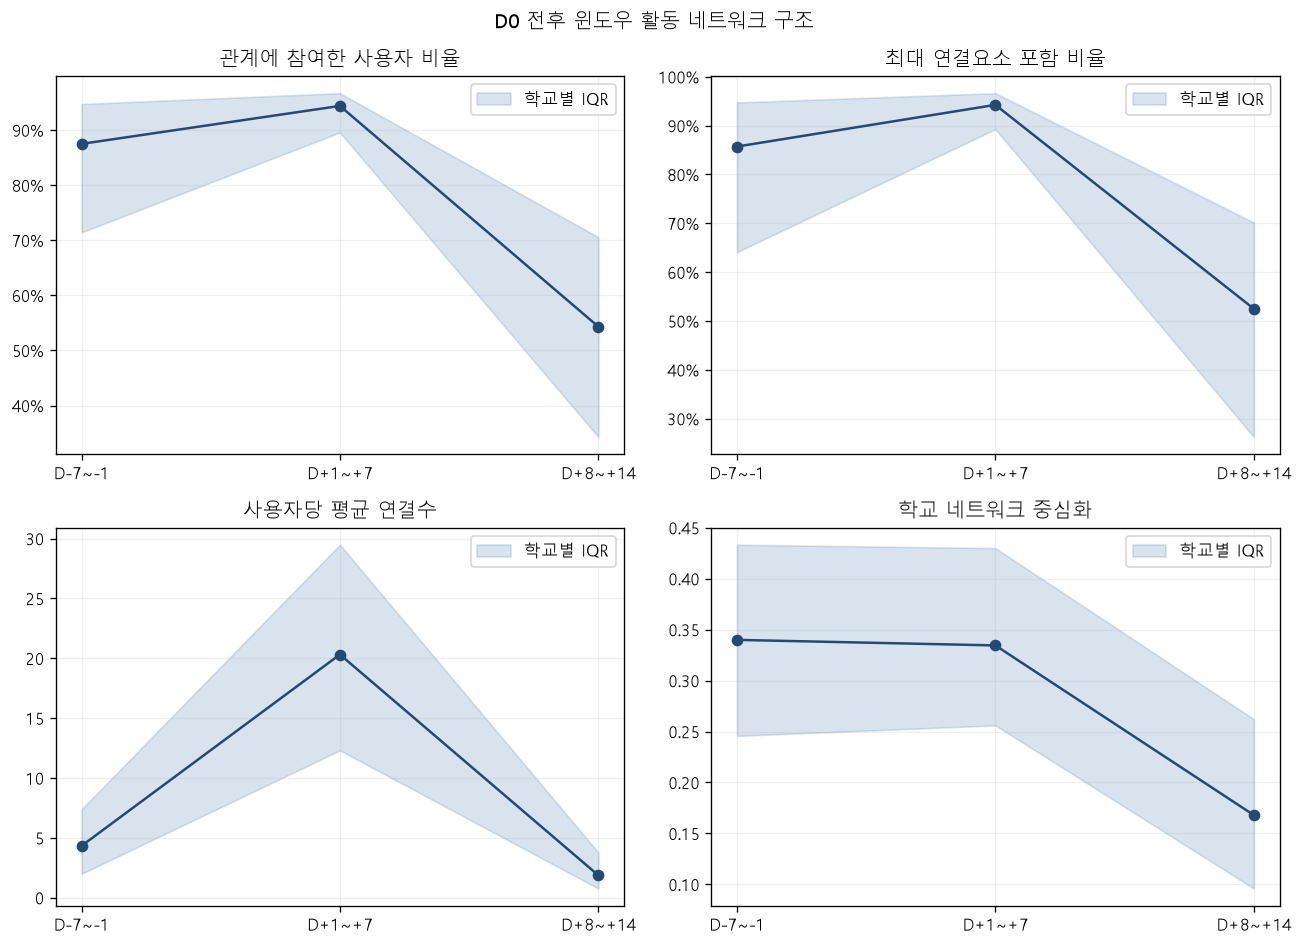

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/24_d0_network_structure_change.png')

In [25]:
valid_d0_school_df=pd.DataFrame({"school_id":pd.Series(school_event.school_id.unique(),dtype="int64")})
con.register("valid_d0_school_df",valid_d0_school_df)
con.execute('''
CREATE OR REPLACE TEMP TABLE d0_complete_school AS
SELECT v.school_id,
       MAX(TRY_CAST(s.current_roster_40th_signup_at AS TIMESTAMP)) AS d0_at
FROM valid_d0_school_df v
JOIN school_daily s USING(school_id)
GROUP BY 1
''')

con.execute('''
CREATE OR REPLACE TEMP TABLE phase_accepted_edges AS
WITH base AS (
  SELECT n1.school_id,n1.node_idx AS send_idx,n2.node_idx AS receive_idx,
         DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) AS rel_day
  FROM event e
  JOIN graph_nodes n1 ON n1.user_id=e.send_user_id
  JOIN graph_nodes n2 ON n2.user_id=e.receive_user_id
  JOIN d0_complete_school d ON d.school_id=n1.school_id
  WHERE e.analysis_eligible_request_flag=1
    AND e.same_school_current_flag=1
    AND e.final_status_code='A'
    AND n1.school_id=n2.school_id
)
SELECT DISTINCT school_id,
       CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
            WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
            WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase,
       LEAST(send_idx,receive_idx)::INTEGER AS u_idx,
       GREATEST(send_idx,receive_idx)::INTEGER AS v_idx
FROM base
WHERE rel_day BETWEEN -7 AND 14 AND rel_day<>0 AND send_idx<>receive_idx
''')

phase_reciprocity=con.execute('''
WITH base AS (
  SELECT DISTINCT n1.school_id,
         CASE WHEN DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN -7 AND -1 THEN 'pre'
              WHEN DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN 1 AND 7 THEN 'early'
              WHEN DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN 8 AND 14 THEN 'late' END AS phase,
         e.send_user_id,e.receive_user_id
  FROM event e
  JOIN graph_nodes n1 ON n1.user_id=e.send_user_id
  JOIN graph_nodes n2 ON n2.user_id=e.receive_user_id
  JOIN d0_complete_school d ON d.school_id=n1.school_id
  WHERE e.analysis_eligible_request_flag=1
    AND e.same_school_current_flag=1
    AND e.final_status_code='A'
    AND n1.school_id=n2.school_id
    AND DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN -7 AND 14
    AND DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE))<>0
), canonical AS (
  SELECT school_id,phase,LEAST(send_user_id,receive_user_id) AS user_a,
         GREATEST(send_user_id,receive_user_id) AS user_b,COUNT(*) AS direction_count
  FROM base WHERE phase IS NOT NULL GROUP BY 1,2,3,4
)
SELECT school_id,phase,COUNT(*) AS accepted_pair_count,
       SUM(direction_count=2)::BIGINT AS reciprocal_pair_count,
       SUM(direction_count=2)/COUNT(*)::DOUBLE AS reciprocal_pair_share
FROM canonical GROUP BY 1,2
''').fetchdf()

phase_edge_np=con.execute('''
SELECT CASE phase WHEN 'pre' THEN 0 WHEN 'early' THEN 1 ELSE 2 END::INTEGER AS phase_code,
       u_idx,v_idx
FROM phase_accepted_edges
ORDER BY phase_code,u_idx,v_idx
''').fetchnumpy()
phase_edges=pd.DataFrame({
    "phase_code":phase_edge_np["phase_code"].astype(np.int8,copy=False),
    "u_idx":phase_edge_np["u_idx"].astype(np.int32,copy=False),
    "v_idx":phase_edge_np["v_idx"].astype(np.int32,copy=False),
})
del phase_edge_np

d0_lookup=con.execute('SELECT school_id,d0_at FROM d0_complete_school').fetchdf()
d0_lookup["d0_at"]=pd.to_datetime(d0_lookup.d0_at)
node_phase_base=node_graph[["node_idx","school_id","signup_at"]].copy()
node_phase_base["signup_at"]=pd.to_datetime(node_phase_base.signup_at)
node_phase_base=node_phase_base.merge(d0_lookup,on="school_id",how="inner")

phase_meta={"pre":(0,-1),"early":(1,7),"late":(2,14)}
phase_structure_parts=[]
for phase,(phase_code,end_day) in phase_meta.items():
    pe=phase_edges[phase_edges.phase_code.eq(phase_code)]
    pu=pe.u_idx.to_numpy(np.int32,copy=False); pv=pe.v_idx.to_numpy(np.int32,copy=False)
    prow=np.concatenate([pu,pv]); pcol=np.concatenate([pv,pu])
    padj=sparse.csr_matrix((np.ones(len(prow),dtype=np.uint8),(prow,pcol)),shape=(n_nodes,n_nodes))
    padj.sum_duplicates(); padj.data[:]=1
    _,plabel=connected_components(padj,directed=False,return_labels=True)
    pdegree=np.diff(padj.indptr).astype(np.int32)

    eligible=node_phase_base.signup_at.notna() & (
        node_phase_base.signup_at.dt.normalize() <=
        (node_phase_base.d0_at+pd.to_timedelta(end_day,unit="D")).dt.normalize())
    pn=node_phase_base.loc[eligible,["node_idx","school_id"]].copy()
    idx=pn.node_idx.to_numpy(np.int32,copy=False)
    pn["degree"]=pdegree[idx]
    pn["component_label"]=plabel[idx]
    pn["active"]=(pn.degree>0).astype(int)

    pcs=(pn.groupby(["school_id","component_label"],as_index=False).size()
         .rename(columns={"size":"component_size"}))
    p_lcc=(pcs.groupby("school_id",as_index=False).component_size.max()
           .rename(columns={"component_size":"largest_component_users"}))
    p_components=(pcs.groupby("school_id",as_index=False).size()
                  .rename(columns={"size":"component_count"}))
    ps=(pn.groupby("school_id",as_index=False)
        .agg(eligible_users=("node_idx","size"),active_users=("active","sum"),
             total_degree=("degree","sum"),max_degree=("degree","max")))
    ps=ps.merge(p_lcc,on="school_id",how="left").merge(p_components,on="school_id",how="left")
    ps["phase"]=phase
    ps["accepted_edge_count"]=(ps.total_degree//2).astype(np.int64)
    ps["active_user_share"]=ps.active_users/ps.eligible_users
    ps["isolate_share"]=1-ps.active_user_share
    ps["average_degree"]=ps.total_degree/ps.eligible_users
    ps["density"]=np.where(ps.eligible_users>1,ps.total_degree/(ps.eligible_users*(ps.eligible_users-1)),np.nan)
    ps["largest_component_share"]=ps.largest_component_users/ps.eligible_users
    ps["degree_centralization"]=np.where(
        ps.eligible_users>2,
        (ps.eligible_users*ps.max_degree-ps.total_degree)/
        ((ps.eligible_users-1)*(ps.eligible_users-2)),np.nan)
    phase_structure_parts.append(ps)
    del padj,plabel,pdegree,prow,pcol,pn,pcs

phase_structure=pd.concat(phase_structure_parts,ignore_index=True)
phase_structure=phase_structure.merge(phase_reciprocity,on=["school_id","phase"],how="left")
phase_structure[["accepted_pair_count","reciprocal_pair_count","reciprocal_pair_share"]]=(
    phase_structure[["accepted_pair_count","reciprocal_pair_count","reciprocal_pair_share"]].fillna(0))
save_table(phase_structure,"24_d0_phase_network_structure.csv")

phase_tests=[]
for metric in ["active_user_share","isolate_share","average_degree","density",
               "largest_component_share","degree_centralization","reciprocal_pair_share"]:
    wide=phase_structure.pivot(index="school_id",columns="phase",values=metric)
    for before,after in [("pre","early"),("early","late")]:
        z=wide[[before,after]].dropna()
        diff=(z[after]-z[before]).to_numpy(); nz=diff[diff!=0]
        stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
        phase_tests.append({"metric":metric,"comparison":f"{before}->{after}","schools":len(z),
                            "median_before":z[before].median(),"median_after":z[after].median(),
                            "median_difference":np.median(diff) if len(diff) else np.nan,
                            "share_increased":np.mean(diff>0) if len(diff) else np.nan,
                            "wilcoxon_p":p})
phase_structure_tests=pd.DataFrame(phase_tests)
save_table(phase_structure_tests,"24_d0_phase_structure_tests.csv")
display(phase_structure_tests.round(4))

phase_order=["pre","early","late"]
fig,axes=plt.subplots(2,2,figsize=(11,8))
for ax,(metric,title,percent) in zip(axes.ravel(),[
    ("active_user_share","관계에 참여한 사용자 비율",True),
    ("largest_component_share","최대 연결요소 포함 비율",True),
    ("average_degree","사용자당 평균 연결수",False),
    ("degree_centralization","학교 네트워크 중심화",False)]):
    summary=(phase_structure.groupby("phase")[metric]
             .agg(median="median",q25=lambda x:x.quantile(.25),q75=lambda x:x.quantile(.75))
             .reindex(phase_order))
    x=np.arange(3)
    ax.plot(x,summary["median"],marker="o",color=COLORS["navy"])
    ax.fill_between(x,summary.q25,summary.q75,color=COLORS["blue"],alpha=.22,label="학교별 IQR")
    ax.set_xticks(x,["D-7~-1","D+1~+7","D+8~+14"]); ax.set_title(title); ax.grid(alpha=.2); ax.legend()
    if percent: ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.suptitle("D0 전후 윈도우 활동 네트워크 구조")
savefig("24_d0_network_structure_change.png")

## 25. 대표 학교의 중심성과 코어 구조

학교 규모 분위수에 가까운 대표 학교에서 중심성, 매개 중심성, 고유벡터 중심성, k-core를 확인한다.


,size_quantile,school_id,n_users,edge_count,component_count,largest_component_users,max_core,max_degree,betweenness_sources
0,Q25,132,100,1330,5,96,23,60,32
1,Q50,12,154,2872,4,151,29,108,32
2,Q75,216,225,6231,5,221,47,168,32


,size_quantile,school_id,node_alias,degree,degree_centrality,sampled_betweenness,eigenvector_centrality,core_number,in_largest_component_flag
41,Q25,132,Q25_node_001,60.0000,0.6061,0.0451,1.0000,23,1
26,Q25,132,Q25_node_002,57.0000,0.5758,0.0494,0.8873,23,1
4,Q25,132,Q25_node_004,53.0000,0.5354,0.0327,0.9169,23,1
44,Q25,132,Q25_node_003,53.0000,0.5354,0.0220,0.9676,23,1
6,Q25,132,Q25_node_005,51.0000,0.5152,0.0303,0.7927,23,1
100,Q50,12,Q50_node_001,108.0000,0.7059,0.0854,1.0000,29,1
218,Q50,12,Q50_node_002,90.0000,0.5882,0.0567,0.8361,29,1
106,Q50,12,Q50_node_003,88.0000,0.5752,0.0593,0.8152,29,1
133,Q50,12,Q50_node_004,86.0000,0.5621,0.0447,0.8385,29,1
123,Q50,12,Q50_node_005,80.0000,0.5229,0.0321,0.7504,29,1


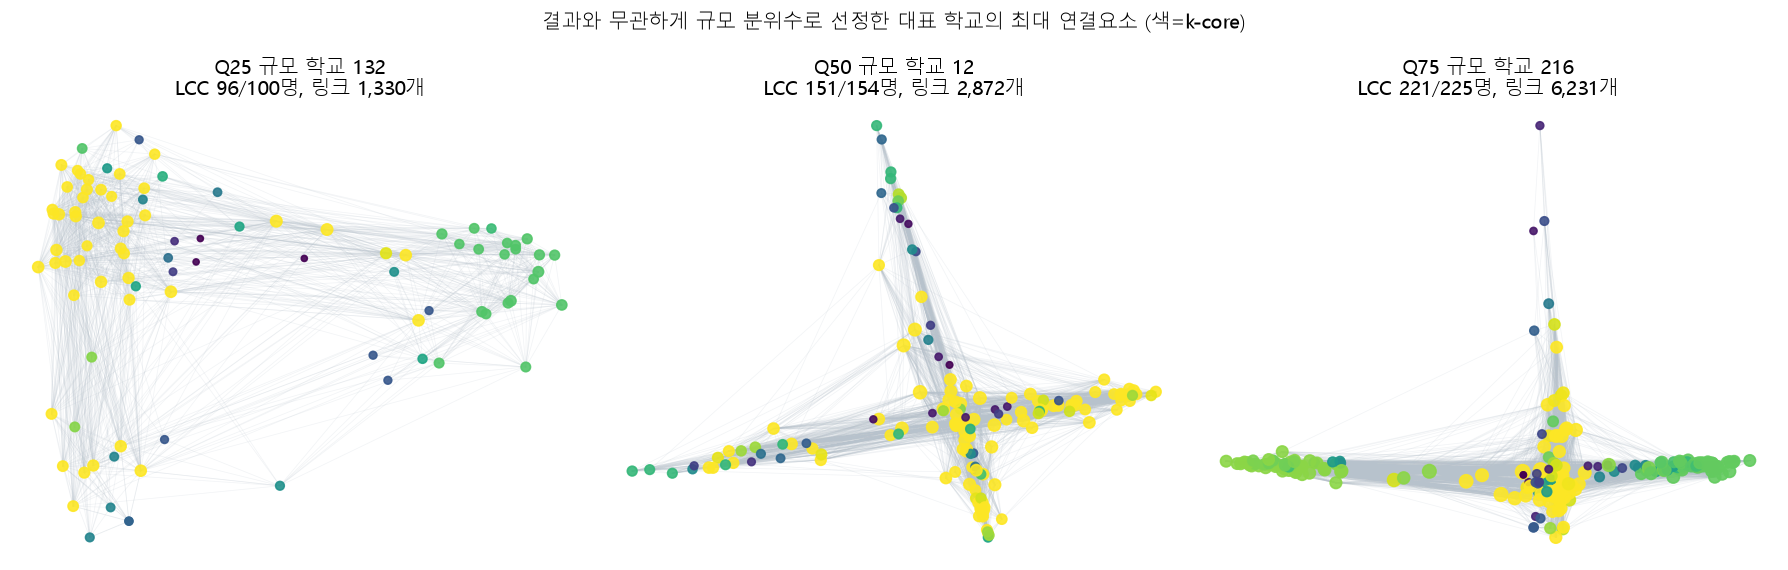

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/25_representative_school_topology.png')

In [26]:
def core_numbers_from_csr(a):
    import heapq
    deg=np.diff(a.indptr).astype(int)
    current=deg.copy(); removed=np.zeros(a.shape[0],dtype=bool); core=np.zeros(a.shape[0],dtype=int)
    heap=[(int(d),int(i)) for i,d in enumerate(current)]; heapq.heapify(heap)
    while heap:
        d,v=heapq.heappop(heap)
        if removed[v] or d!=current[v]:
            continue
        removed[v]=True; core[v]=d
        for u in a.indices[a.indptr[v]:a.indptr[v+1]]:
            if not removed[u] and current[u]>d:
                current[u]-=1; heapq.heappush(heap,(int(current[u]),int(u)))
    return core

def sampled_betweenness_from_csr(a,max_sources=32):
    n=a.shape[0]; score=np.zeros(n,dtype=float)
    if n<3: return score
    sources=np.unique(np.linspace(0,n-1,min(max_sources,n),dtype=int))
    for s in sources:
        stack=[]; pred=[[] for _ in range(n)]; sigma=np.zeros(n); sigma[s]=1
        dist=np.full(n,-1,dtype=int); dist[s]=0; q=deque([int(s)])
        while q:
            v=q.popleft(); stack.append(v)
            for w in a.indices[a.indptr[v]:a.indptr[v+1]]:
                if dist[w]<0:
                    dist[w]=dist[v]+1; q.append(int(w))
                if dist[w]==dist[v]+1:
                    sigma[w]+=sigma[v]; pred[w].append(v)
        delta=np.zeros(n)
        while stack:
            w=stack.pop()
            if sigma[w]>0:
                coeff=(1+delta[w])/sigma[w]
                for v in pred[w]: delta[v]+=sigma[v]*coeff
            if w!=s: score[w]+=delta[w]
    score*=n/len(sources)
    score/=((n-1)*(n-2))
    return score

eligible_rep=school_structure[(school_structure.n_users>=40)&(school_structure.accepted_edge_count>0)].copy()
size_targets=eligible_rep.n_users.quantile([.25,.5,.75]).to_dict()
chosen=[]
for quantile,target in size_targets.items():
    remaining=eligible_rep[~eligible_rep.school_id.isin(chosen)]
    sid=int(remaining.loc[(remaining.n_users-target).abs().idxmin(),"school_id"])
    chosen.append(sid)

representative_rows=[]; centrality_node_rows=[]; representative_graphs=[]
for quantile,sid in zip(["Q25","Q50","Q75"],chosen):
    global_idx=node_graph.loc[node_graph.school_id.eq(sid),"node_idx"].to_numpy(np.int32)
    a=accepted_adj[global_idx,:][:,global_idx].tocsr()
    degree=np.diff(a.indptr).astype(float)
    degree_c=degree/max(len(degree)-1,1)
    core=core_numbers_from_csr(a)
    between=sampled_betweenness_from_csr(a,max_sources=32)
    eigen=np.zeros(len(degree),dtype=float)
    if len(degree)>2 and a.nnz>0:
        try:
            _,vec=eigsh(a.astype(float),k=1,which="LA",tol=1e-3,maxiter=3000)
            eigen=np.abs(vec[:,0]); eigen/=eigen.max() if eigen.max()>0 else 1
        except Exception:
            eigen=degree_c.copy()
    ncomp,clabel=connected_components(a,directed=False,return_labels=True)
    counts=np.bincount(clabel); lcc_label=int(np.argmax(counts)); lcc_local=np.where(clabel==lcc_label)[0]
    representative_rows.append({"size_quantile":quantile,"school_id":sid,"n_users":len(degree),
                                "edge_count":int(a.nnz//2),"component_count":ncomp,
                                "largest_component_users":int(counts[lcc_label]),
                                "max_core":int(core.max()) if len(core) else 0,
                                "max_degree":int(degree.max()) if len(degree) else 0,
                                "betweenness_sources":min(32,len(degree))})
    rank_order=np.argsort(-degree)
    rank_map=np.empty(len(degree),dtype=int); rank_map[rank_order]=np.arange(1,len(degree)+1)
    for i in range(len(degree)):
        centrality_node_rows.append({"size_quantile":quantile,"school_id":sid,
                                     "node_alias":f"{quantile}_node_{rank_map[i]:03d}",
                                     "degree":degree[i],"degree_centrality":degree_c[i],
                                     "sampled_betweenness":between[i],"eigenvector_centrality":eigen[i],
                                     "core_number":core[i],"in_largest_component_flag":int(clabel[i]==lcc_label)})
    representative_graphs.append((quantile,sid,a,degree,core,lcc_local))

representative_summary=pd.DataFrame(representative_rows)
representative_centrality=pd.DataFrame(centrality_node_rows)
save_table(representative_summary,"25_representative_school_centrality_summary.csv")
save_table(representative_centrality,"25_representative_school_node_centrality_anonymized.csv")
display(representative_summary)
display(representative_centrality.sort_values(["size_quantile","degree"],ascending=[True,False]).groupby("size_quantile").head(5))

fig,axes=plt.subplots(1,3,figsize=(15,4.8))
for ax,(quantile,sid,a,degree,core,lcc_local) in zip(axes,representative_graphs):
    af=a[lcc_local,:][:,lcc_local].tocsr(); m=af.shape[0]
    if m>=3 and af.nnz>0:
        try:
            lap=sparse.csgraph.laplacian(af.astype(float),normed=True)
            k=min(3,m-1)
            _,vec=eigsh(lap,k=k,which="SM",tol=1e-3,maxiter=3000)
            pos=np.column_stack([vec[:,1] if k>1 else np.arange(m),vec[:,2] if k>2 else np.zeros(m)])
        except Exception:
            theta=np.linspace(0,2*np.pi,m,endpoint=False); pos=np.column_stack([np.cos(theta),np.sin(theta)])
    else:
        theta=np.linspace(0,2*np.pi,max(m,1),endpoint=False); pos=np.column_stack([np.cos(theta),np.sin(theta)])[:m]
    rr,cc=sparse.triu(af,k=1).nonzero()
    for u,v in zip(rr,cc):
        ax.plot(pos[[u,v],0],pos[[u,v],1],color="#B7C2CC",alpha=.18,lw=.45,zorder=1)
    local_degree=degree[lcc_local]; local_core=core[lcc_local]
    sc=ax.scatter(pos[:,0],pos[:,1],s=8+5*np.sqrt(local_degree),c=local_core,cmap="viridis",alpha=.9,zorder=2)
    ax.set_title(f"{quantile} 규모 학교 {sid}\nLCC {m}/{len(degree)}명, 링크 {a.nnz//2:,}개")
    ax.axis("off")
plt.suptitle("결과와 무관하게 규모 분위수로 선정한 대표 학교의 최대 연결요소 (색=k-core)")
savefig("25_representative_school_topology.png")

## 26. 초기 네트워크 구조와 후기 활동

초기 요청량 기준모형과 구조 지표 추가모형의 시간순 홀드아웃 성능을 비교한다.


,model,train_schools,test_schools,test_r2,test_mae_log_scale,selected_alpha
0,요청량 기준 모델,3033,759,-1.9706,1.7610,13.4340
1,구조 지표 추가 모델,3033,759,-1.4160,1.5329,2.0309


,early_structure_metric,schools,spearman_rho_with_late_activity,p_value
0,early_structure_active_user_share,3792,0.2899,0.0000
1,early_structure_average_degree,3792,0.2764,0.0000
2,early_structure_largest_component_share,3792,0.2831,0.0000
3,early_structure_degree_centralization,3792,0.1102,0.0000
4,early_structure_reciprocal_pair_share,3792,0.1053,0.0000


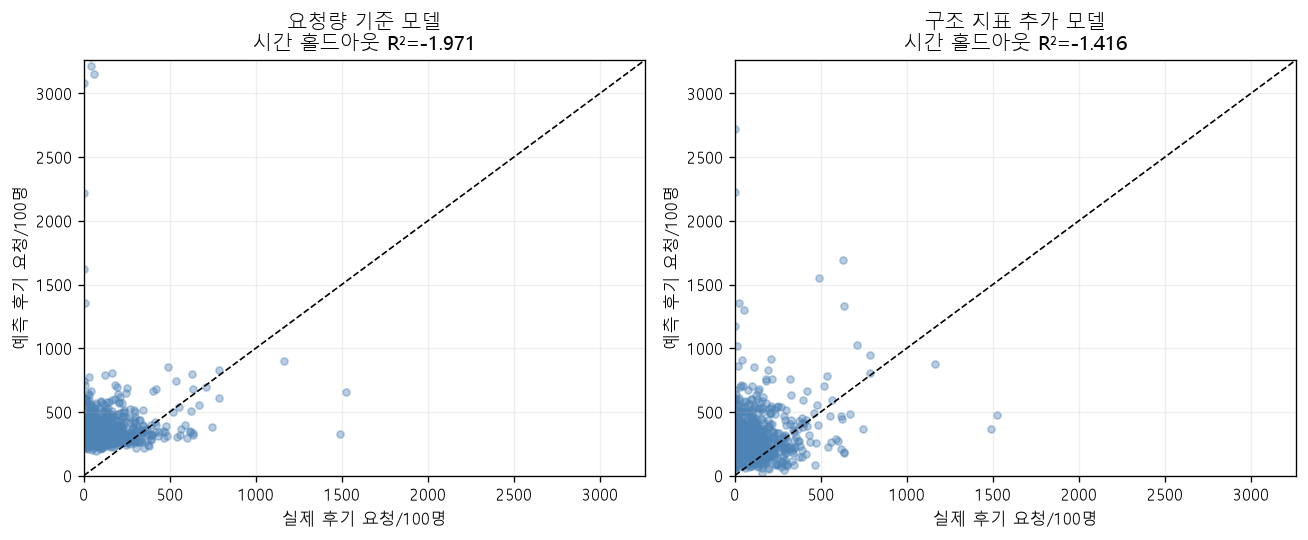

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/26_structure_incremental_prediction.png')

In [27]:
early_structure=(phase_structure[phase_structure.phase.eq("early")]
                 [["school_id","active_user_share","isolate_share","average_degree","density",
                   "largest_component_share","degree_centralization","reciprocal_pair_share"]]
                 .rename(columns=lambda c: c if c=="school_id" else f"early_structure_{c}"))
structure_model=model_df.merge(early_structure,on="school_id",how="inner").copy()
baseline_features=["log_roster_size","d0_day_index","early_new_users_per_100","early_requests_per_100"]
structure_features=["early_structure_active_user_share","early_structure_average_degree",
                    "early_structure_largest_component_share","early_structure_degree_centralization",
                    "early_structure_reciprocal_pair_share"]
target="log_late_request_rate"
sm=structure_model.dropna(subset=baseline_features+structure_features+[target]).sort_values("d0_date").copy()
split=int(len(sm)*.8); train=np.arange(len(sm))<split; test=~train
structure_model_rows=[]; structure_predictions=[]; fitted_models={}
for label,cols in [("요청량 기준 모델",baseline_features),("구조 지표 추가 모델",baseline_features+structure_features)]:
    pipe=make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-4,4,40)))
    pipe.fit(sm.loc[train,cols],sm.loc[train,target])
    pred=pipe.predict(sm.loc[test,cols]); fitted_models[label]=(pipe,cols,pred)
    structure_model_rows.append({"model":label,"train_schools":int(train.sum()),"test_schools":int(test.sum()),
                                 "test_r2":r2_score(sm.loc[test,target],pred),
                                 "test_mae_log_scale":mean_absolute_error(sm.loc[test,target],pred),
                                 "selected_alpha":pipe.named_steps["ridgecv"].alpha_})
    for sid,actual,predicted in zip(sm.loc[test,"school_id"],sm.loc[test,target],pred):
        structure_predictions.append({"model":label,"school_id":sid,
                                      "actual_late_requests_per_100":np.expm1(actual),
                                      "predicted_late_requests_per_100":np.expm1(predicted)})
structure_model_quality=pd.DataFrame(structure_model_rows)
structure_model_predictions=pd.DataFrame(structure_predictions)
save_table(structure_model_quality,"26_structure_incremental_prediction_quality.csv")
save_table(structure_model_predictions,"26_structure_incremental_predictions.csv")

structure_correlations=[]
for col in structure_features:
    rho,p=stats.spearmanr(sm[col],sm[target],nan_policy="omit")
    structure_correlations.append({"early_structure_metric":col,"schools":len(sm),
                                   "spearman_rho_with_late_activity":rho,"p_value":p})
structure_correlations=pd.DataFrame(structure_correlations)
save_table(structure_correlations,"26_early_structure_late_activity_correlations.csv")
display(structure_model_quality.round(4)); display(structure_correlations.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.6))
lim=max(structure_model_predictions.actual_late_requests_per_100.quantile(.98),
        structure_model_predictions.predicted_late_requests_per_100.quantile(.98))
for ax,label in zip(axes,["요청량 기준 모델","구조 지표 추가 모델"]):
    z=structure_model_predictions[structure_model_predictions.model.eq(label)]
    ax.scatter(z.actual_late_requests_per_100,z.predicted_late_requests_per_100,s=18,alpha=.4,color=COLORS["blue"])
    ax.plot([0,lim],[0,lim],color="black",ls="--",lw=1)
    q=structure_model_quality[structure_model_quality.model.eq(label)].iloc[0]
    ax.set_xlim(0,lim); ax.set_ylim(0,lim); ax.grid(alpha=.2)
    ax.set_xlabel("실제 후기 요청/100명"); ax.set_ylabel("예측 후기 요청/100명")
    ax.set_title(f"{label}\n시간 홀드아웃 R²={q.test_r2:.3f}")
savefig("26_structure_incremental_prediction.png")

## 27. 상태 민감도와 학교 세그먼트 결합 준비

최종 수락 링크와 전체 요청 링크 결과를 비교하고, 학교 세그먼트와 결합할 학교 단위 구조표를 저장한다.


,accepted_metric,all_request_metric,schools,accepted_median,all_request_median,spearman_rho,p_value
0,active_user_share,all_request_active_user_share,3897,0.9671,0.9958,0.4648,0.0000
1,average_degree,all_request_average_degree,3897,28.7303,37.6589,0.9751,0.0000
2,density,all_request_density,3897,0.1802,0.2444,0.9692,0.0000


,check,value,expected,pass_flag
0,학교 구조표 school_id 유일성,0,0,1
1,노드 수 보존,677080,677080,1
2,링크 수 보존,10377675,10377675,1
3,활성 비율 범위 오류,0,0,1
4,LCC 비율 범위 오류,0,0,1
5,D0 구간 학교 중복,0,0,1
6,구조 예측 미래정보 사용,0,0 (D+1~7로 D+8~14 예측),1


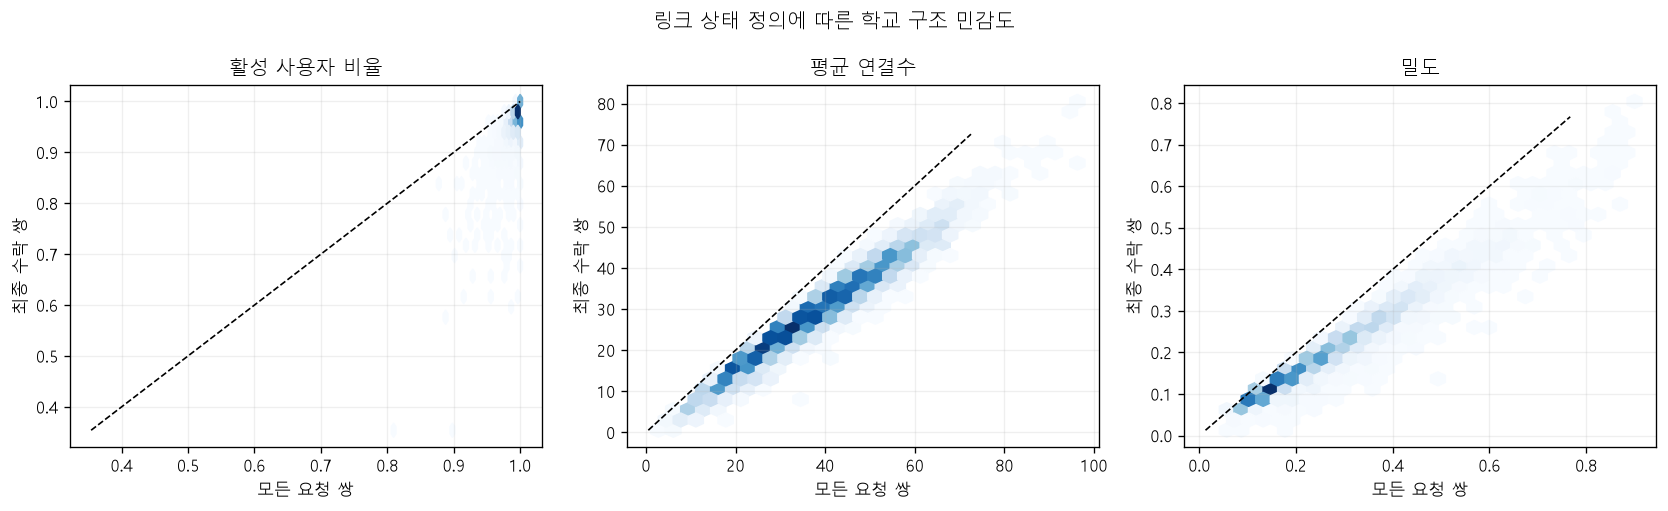

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/network_deep_dive/outputs/figures/27_status_definition_sensitivity.png')

In [28]:
all_request_structure=con.execute('''
WITH canonical AS (
  SELECT DISTINCT ns.school_id,
         LEAST(ns.node_idx,nr.node_idx) AS u_idx,
         GREATEST(ns.node_idx,nr.node_idx) AS v_idx
  FROM pair p
  JOIN graph_nodes ns ON ns.user_id=p.send_user_id
  JOIN graph_nodes nr ON nr.user_id=p.receive_user_id
  WHERE p.analysis_eligible_pair_flag=1 AND p.same_school_current_flag=1
    AND ns.school_id=nr.school_id AND ns.node_idx<>nr.node_idx
), active AS (
  SELECT school_id,u_idx AS node_idx FROM canonical
  UNION
  SELECT school_id,v_idx AS node_idx FROM canonical
), edges AS (
  SELECT school_id,COUNT(*) AS all_request_edge_count FROM canonical GROUP BY 1
), active_count AS (
  SELECT school_id,COUNT(*) AS all_request_active_users FROM active GROUP BY 1
)
SELECT n.school_id,COUNT(*) AS n_users,
       COALESCE(MAX(e.all_request_edge_count),0) AS all_request_edge_count,
       COALESCE(MAX(a.all_request_active_users),0) AS all_request_active_users
FROM graph_nodes n
LEFT JOIN edges e USING(school_id)
LEFT JOIN active_count a USING(school_id)
GROUP BY 1
''').fetchdf()
all_request_structure["all_request_active_user_share"]=all_request_structure.all_request_active_users/all_request_structure.n_users
all_request_structure["all_request_average_degree"]=2*all_request_structure.all_request_edge_count/all_request_structure.n_users
all_request_structure["all_request_density"]=np.where(
    all_request_structure.n_users>1,
    2*all_request_structure.all_request_edge_count/(all_request_structure.n_users*(all_request_structure.n_users-1)),np.nan)

robustness=school_structure[["school_id","n_users","accepted_edge_count","active_user_share","average_degree","density"]].merge(
    all_request_structure,on=["school_id","n_users"],how="left")
robustness_tests=[]
z=robustness[robustness.n_users>=40].copy()
for accepted_col,all_col in [("active_user_share","all_request_active_user_share"),
                             ("average_degree","all_request_average_degree"),("density","all_request_density")]:
    rho,p=stats.spearmanr(z[accepted_col],z[all_col],nan_policy="omit")
    robustness_tests.append({"accepted_metric":accepted_col,"all_request_metric":all_col,"schools":len(z),
                             "accepted_median":z[accepted_col].median(),"all_request_median":z[all_col].median(),
                             "spearman_rho":rho,"p_value":p})
robustness_tests=pd.DataFrame(robustness_tests)
save_table(robustness,"27_status_definition_sensitivity.csv")
save_table(robustness_tests,"27_status_definition_tests.csv")

phase_wide=phase_structure.pivot(index="school_id",columns="phase",
                                 values=["eligible_users","accepted_edge_count","active_user_share",
                                         "average_degree","density","largest_component_share",
                                         "degree_centralization","reciprocal_pair_share"])
phase_wide.columns=[f"{metric}_{phase}" for metric,phase in phase_wide.columns]
phase_wide=phase_wide.reset_index()
school_network_master=(school_structure.merge(
    homophily.drop(columns=["n_users"],errors="ignore"),on="school_id",how="left",suffixes=("","_homophily"))
    .merge(phase_wide,on="school_id",how="left"))
save_table(school_network_master,"27_school_network_master_segment_join_ready.csv")

structural_qa=pd.DataFrame([
  {"check":"학교 구조표 school_id 유일성","value":int(school_structure.school_id.duplicated().sum()),"expected":"0",
   "pass_flag":int(school_structure.school_id.duplicated().sum()==0)},
  {"check":"노드 수 보존","value":int(school_structure.n_users.sum()),"expected":str(n_nodes),
   "pass_flag":int(school_structure.n_users.sum()==n_nodes)},
  {"check":"링크 수 보존","value":int(school_structure.accepted_edge_count.sum()),"expected":str(len(edge_u)),
   "pass_flag":int(school_structure.accepted_edge_count.sum()==len(edge_u))},
  {"check":"활성 비율 범위 오류","value":int((~school_structure.active_user_share.between(0,1)).sum()),"expected":"0",
   "pass_flag":int(school_structure.active_user_share.between(0,1).all())},
  {"check":"LCC 비율 범위 오류","value":int((~school_structure.largest_component_share.between(0,1)).sum()),"expected":"0",
   "pass_flag":int(school_structure.largest_component_share.between(0,1).all())},
  {"check":"D0 구간 학교 중복","value":int(phase_structure.duplicated(["school_id","phase"]).sum()),"expected":"0",
   "pass_flag":int(phase_structure.duplicated(["school_id","phase"]).sum()==0)},
  {"check":"구조 예측 미래정보 사용","value":0,"expected":"0 (D+1~7로 D+8~14 예측)","pass_flag":1},
])
assert structural_qa.pass_flag.eq(1).all(), structural_qa[structural_qa.pass_flag.eq(0)]
save_table(structural_qa,"27_structural_network_final_qa.csv")
display(robustness_tests.round(4)); display(structural_qa)

fig,axes=plt.subplots(1,3,figsize=(14,4.3))
for ax,(accepted_col,all_col,title) in zip(axes,[
    ("active_user_share","all_request_active_user_share","활성 사용자 비율"),
    ("average_degree","all_request_average_degree","평균 연결수"),
    ("density","all_request_density","밀도")]):
    ax.hexbin(z[all_col],z[accepted_col],gridsize=28,mincnt=1,cmap="Blues")
    lo=min(z[all_col].min(),z[accepted_col].min()); hi=max(z[all_col].quantile(.99),z[accepted_col].quantile(.99))
    ax.plot([lo,hi],[lo,hi],color="black",ls="--",lw=1)
    ax.set_xlabel("모든 요청 쌍"); ax.set_ylabel("최종 수락 쌍"); ax.set_title(title); ax.grid(alpha=.2)
plt.suptitle("링크 상태 정의에 따른 학교 구조 민감도")
savefig("27_status_definition_sensitivity.png")

## 28. 결론

가입 직후 관계 편입은 빠르게 발생했지만 관계 활동의 지속성과 구조적 확장은 제한적이었다. 결과는 가입 이후 네트워크 경험에 대한 분석이며 바이럴 유입의 인과 증거로 사용하지 않는다.


In [29]:
timing_sent=speed_summary.loc[speed_summary.metric.eq("가입→첫 요청 발송")].iloc[0]
timing_recv=speed_summary.loc[speed_summary.metric.eq("가입→첫 요청 수신")].iloc[0]
relation_test=quality_test.iloc[0]
pre_life=lifecycle_summary.set_index("signup_phase").loc["40명 이전 가입"]
post_life=lifecycle_summary.set_index("signup_phase").loc["40명 이후 가입"]
early_new_share=float(request_age_pooled[(request_age_pooled.phase.eq("early")) &
                                          (request_age_pooled.sender_age_band.eq("가입 24시간 이내"))]
                      .phase_request_share.iloc[0])
delay_phase=accepted_delay_overall.set_index("phase").median_delay_hours
q1=persistence_summary.iloc[0]; q5=persistence_summary.iloc[-1]
actual_placebo=placebo_tests[(placebo_tests.anchor_offset.eq(0)) &
                             (placebo_tests.metric.eq("requests_per_100"))].iloc[0]
later_placebo=placebo_tests[(placebo_tests.anchor_offset.eq(28)) &
                            (placebo_tests.metric.eq("requests_per_100"))].iloc[0]
structural_base=school_structure[school_structure.n_users>=40]
structural_medians=structural_base[["isolate_share","largest_component_share","average_degree",
                                    "degree_gini","degree_centralization"]].median()
early_active_test=phase_structure_tests[(phase_structure_tests.metric.eq("active_user_share")) &
                                        (phase_structure_tests.comparison.eq("pre->early"))].iloc[0]
late_active_test=phase_structure_tests[(phase_structure_tests.metric.eq("active_user_share")) &
                                       (phase_structure_tests.comparison.eq("early->late"))].iloc[0]
grade_homophily=homophily_tests[homophily_tests.level.eq("grade")].iloc[0]
class_homophily=homophily_tests[homophily_tests.level.eq("class")].iloc[0]
baseline_r2=structure_model_quality.loc[structure_model_quality.model.eq("요청량 기준 모델"),"test_r2"].iloc[0]
structure_r2=structure_model_quality.loc[structure_model_quality.model.eq("구조 지표 추가 모델"),"test_r2"].iloc[0]

findings=pd.DataFrame([
    {"판단":"가입 직후 관계 행동은 매우 빠르게 시작됨",
     "데이터 근거":f"첫 발송 중앙 {timing_sent.median_minutes:.2f}분, 첫 수신 중앙 {timing_recv.median_minutes:.2f}분",
     "해석":"가입자를 관계 화면까지 데려오는 초기 온보딩 동력은 강했다.",
     "제품 재설계 원칙":"첫 연결은 짧고 명확하게 유지하되 강제 발송량보다 실제 상호반응을 우선한다.",
     "성공 지표":"첫 요청까지 시간, 24시간 내 상대 반응 사용자율"},
    {"판단":"D0 직후 요청은 신규 가입자의 온보딩 행동에 크게 의존",
     "데이터 근거":f"D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중 {early_new_share:.1%}",
     "해석":"관계 활동 폭발의 상당 부분은 기존 사용자의 재활성화보다 신규 가입자의 첫날 행동이었다.",
     "제품 재설계 원칙":"가입 당일 행동과 재방문 관계 행동을 별도 루프로 설계한다.",
     "성공 지표":"가입 24시간 이내 요청 비중, 기존 사용자 관계 행동 비중"},
    {"판단":"40명 이후 가입자는 첫날에는 많이 보내지만 둘째 주 지속률은 낮음",
     "데이터 근거":f"첫 7일 발송자 중 D+8~D+14 지속 비율 {pre_life.d8_d14_continuation_share_among_early_senders:.1%}→{post_life.d8_d14_continuation_share_among_early_senders:.1%}; 첫 14일 발송 중 첫 24시간 집중 중앙값 {pre_life.median_first24_share_of_first14d:.1%}→{post_life.median_first24_share_of_first14d:.1%}",
     "해석":"동일한 가입 후 14일 창에서 비교해도 40명 이후 네트워크 경험은 더 강한 일회성 온보딩 버스트 형태였다.",
     "제품 재설계 원칙":"D+2~D+7에 새로운 관계 이유를 공급하는 두 번째 루프가 필요하다.",
     "성공 지표":"7일 이후 관계 행동 지속률, D+2~D+7 고유 상호작용자 수"},
    {"판단":"수신 과부하보다 관계에 이미 편입된 사용자에게 수락이 집중",
     "데이터 근거":f"요청 1건 수신자의 최종 수락 상태 비율 {receiver_test.accepted_share_at_1.iloc[0]:.1%}, 21~50건 수신자는 {receiver_test.accepted_share_at_21_50.iloc[0]:.1%}",
     "해석":"요청을 많이 받을수록 반응이 무너지는 과부하 패턴은 관측되지 않았다. 인기·활성도 선택효과일 수 있다.",
     "제품 재설계 원칙":"수신량 제한보다 관계가 적은 사용자의 첫 상호반응 실패를 우선 관리한다.",
     "성공 지표":"저연결 사용자 수락 상태 비율, 첫 상호 수락까지 시간"},
    {"판단":"초기 폭발 크기는 후기 절대 활동을 거의 구분하지 못함",
     "데이터 근거":f"초기 Q1 후기 중앙 {q1.late_request_rate_median:.1f}, Q5 후기 중앙 {q5.late_request_rate_median:.1f}; 초기-후기 Spearman ρ={persistence_test.spearman_early_vs_late_absolute.iloc[0]:.3f}",
     "해석":"초기에 훨씬 많이 보낸 학교도 2주차에는 비슷한 수준으로 수렴했다.",
     "제품 재설계 원칙":"초기 총요청량을 성공으로 보지 말고 후기 참여자 폭과 재상호작용을 관리한다.",
     "성공 지표":"D+8~D+14 고유 발송자율, 초기 대비 후기 관계 행동 유지"},
    {"판단":"D0 증가는 이후 임의 기준일에서 반복되지 않음",
     "데이터 근거":f"실제 D0 전후 요청률 중앙 변화 {actual_placebo.median_difference:.1f}, D+28 위약일은 {later_placebo.median_difference:.1f}",
     "해석":"D0 주변 관계 활동 변화가 단순한 아무 시점의 변동과 같지는 않았다. 다만 D0의 인과효과를 확정하지는 않는다.",
     "제품 재설계 원칙":"학교 활성화 시점을 운영 트리거로 활용하되 위약·달력 보정을 계속 병행한다.",
     "성공 지표":"활성화 전후 학교 보정 발송자율, 위약 대비 증분"},
    {"판단":"친구요청 수락 지연은 Viral Cycle Time이 아님",
     "데이터 근거":f"최종 수락 상태 갱신 지연 대리값: early 약 {delay_phase.get('early',np.nan):.1f}시간, late 약 {delay_phase.get('late',np.nan):.1f}시간",
     "해석":"이미 가입한 사용자 사이의 상태 갱신 지연이며 신규 가입 전환 주기가 아니다.",
     "제품 재설계 원칙":"K-Factor 대신 네트워크 편입·상호반응·지속성을 별도 지표로 운영한다.",
     "성공 지표":"첫 수신, 최종 수락 상태 비율, 7일 이후 관계 행동"},
    {"판단":"최종 수락 관계망은 대부분 크게 연결됐지만 소수 고립 사용자가 남음",
     "데이터 근거":f"현재 재적 40명 이상 학교 중앙값: 고립 {structural_medians.isolate_share:.1%}, 최대 연결요소 포함 {structural_medians.largest_component_share:.1%}, 평균 연결수 {structural_medians.average_degree:.1f}",
     "해석":"학교별 관계 편입 자체는 전반적으로 강했다. 다만 중앙값만으로 소수 고립 사용자를 지우지 말고 총량과 구조적 포용성을 함께 관리해야 한다.",
     "제품 재설계 원칙":"연결이 많은 허브보다 고립 사용자에게 첫 상호 관계가 만들어지는 경로를 우선한다.",
     "성공 지표":"고립 사용자 비율, 최대 연결요소 포함 비율, 저연결 사용자 첫 상호반응률"},
    {"판단":"D0 직후 구조 확장과 후기 유지가 동일하지 않음",
     "데이터 근거":f"활성 사용자 비율 학교 중앙값 {early_active_test.median_before:.1%}→{early_active_test.median_after:.1%}, 이후 {late_active_test.median_before:.1%}→{late_active_test.median_after:.1%}",
     "해석":"D0 직후 더 많은 사용자가 관계 행동에 참여하더라도 다음 주까지 같은 폭으로 유지되는지는 별도 문제다.",
     "제품 재설계 원칙":"D0 도달을 완료점이 아니라 관계망 품질을 추적하기 시작하는 운영 트리거로 사용한다.",
     "성공 지표":"구간별 활성 사용자율, LCC 포함률, 평균 연결수의 D+8~14 유지"},
    {"판단":"관계는 현재 학년·반 경계를 따라 형성되는 경향을 보임",
     "데이터 근거":f"구성 기대 대비 같은 학년 연결 중앙 초과 {grade_homophily.median_excess_pp:.1f}%p, 같은 반 연결 중앙 초과 {class_homophily.median_excess_pp:.1f}%p",
     "해석":"학교 전체가 균일하게 연결되기보다 기존 오프라인 집단 구조가 온라인 관계망에 반영됐을 가능성이 있다.",
     "제품 재설계 원칙":"반 안의 친밀도는 활용하되 반 밖의 안전한 브리지 경험을 별도로 설계한다.",
     "성공 지표":"같은 반 연결과 교차 반 브리지의 균형, 교차 집단 상호반응률"},
    {"판단":"초기 구조 지표를 추가해도 후기 활동 예측에는 실패",
     "데이터 근거":f"시간 홀드아웃 R²: 요청량 기준 {baseline_r2:.3f}, 구조 지표 추가 {structure_r2:.3f}",
     "해석":"구조 지표 추가로 오차는 줄었지만 두 모델 모두 R²가 음수여서 후기 학교를 안정적으로 일반화하지 못했다. 초기 구조만으로 지속성을 예측할 수 있다는 주장은 기각한다.",
     "제품 재설계 원칙":"초기 관계망 모양만으로 장기 성공을 판정하지 말고 실제 후기 행동을 직접 추적한다.",
     "성공 지표":"구조 지표 추가 홀드아웃 R²·MAE, 후기 활동 예측 안정성"},
])
save_table(findings,"14_network_findings_to_design.csv")
display(findings)

report_lines=[
    "# Network Deep Dive 최종 요약",
    "",
    f"- 분석 가능 사용자: {int(scope.loc[scope.object.eq('사용자 프로필'),'eligible_count'].iloc[0]):,}명",
    f"- 분석 가능 친구요청: {int(scope.loc[scope.object.eq('친구요청 이벤트'),'eligible_count'].iloc[0]):,}건",
    f"- 40명 기능 활성화 도달 학교: {int(reached.reached_40_schools.iloc[0]):,}개",
    f"- D-14~D+14 완전 관측 학교: {school_event.school_id.nunique():,}개",
    "",
    "## 핵심 결론",
    f"- 가입 후 첫 요청 발송 중앙값은 {timing_sent.median_minutes:.2f}분으로 초기 관계 편입은 매우 빨랐다.",
    f"- D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중은 {early_new_share:.1%}였다.",
    f"- 첫 7일 발송자 중 D+8~D+14 지속률은 40명 이후 가입자 {post_life.d8_d14_continuation_share_among_early_senders:.1%}, 이전 가입자 {pre_life.d8_d14_continuation_share_among_early_senders:.1%}였다.",
    f"- 초기 요청 강도와 후기 절대 요청률의 Spearman 상관은 {persistence_test.spearman_early_vs_late_absolute.iloc[0]:.3f}로 약했다.",
    f"- 실제 D0 요청률 중앙 변화는 {actual_placebo.median_difference:.1f}, D+28 위약일은 {later_placebo.median_difference:.1f}였다.",
    f"- 현재 재적 40명 이상 학교의 최종 수락 관계망에서 고립 사용자 비율 중앙값은 {structural_medians.isolate_share:.1%}, 최대 연결요소 포함 비율 중앙값은 {structural_medians.largest_component_share:.1%}였다.",
    f"- D0 전→초기의 활성 사용자 비율 중앙값은 {early_active_test.median_before:.1%}→{early_active_test.median_after:.1%}, 초기→후기는 {late_active_test.median_before:.1%}→{late_active_test.median_after:.1%}였다.",
    f"- 초기 구조 지표를 추가한 후기 활동 예측의 시간 홀드아웃 R²는 {baseline_r2:.3f}→{structure_r2:.3f}였지만 모두 음수여서 예측에는 실패했다.",
    "- 따라서 네트워크의 핵심 문제는 첫 연결 부족보다 가입 직후 일회성 행동을 지속 관계로 바꾸는 두 번째 루프의 부재에 가깝다.",
    "",
    "## 핵심 주의사항",
    "- 최종 A/P/R 상태는 요청 생성 당시 상태가 아니다.",
    "- 현재 학교와 친구 수는 이벤트 당시 스냅샷이 아니다.",
    "- 구조적 링크는 최종 수락 상태 요청 쌍이며 해당 시점의 전체 친구 목록 자체는 아니다.",
    "- 학년·반 동질성은 현재 스냅샷 기준이라 과거 소속을 확정하지 않는다.",
    "- 역방향 친구요청은 수락 후 우정의 상호성을 뜻하지 않으므로 관계 품질 KPI로 해석하지 않는다.",
    "- 학교 세그먼트 라벨은 저장소에 없어 임의 생성하지 않았으며 school_id 기준 통합 구조표를 별도 저장했다.",
    "- created_at→updated_at은 최종 상태 갱신 지연의 대리값이며 실제 수락시각이 아니다.",
    "- 친구요청은 가입 초대가 아니므로 K-Factor와 Viral Cycle Time으로 계산할 수 없다.",
    "- D0 전후 차이는 위약검정과 전국 달력 보정을 통과했더라도 인과효과로 단정하지 않는다.",
]
(OUTPUT_DIR/"network_deep_dive_summary.md").write_text("\n".join(report_lines),encoding="utf-8")
print("\n".join(report_lines))
print(f"\n모든 결과가 저장되었습니다: {OUTPUT_DIR}")

,판단,데이터 근거,해석,제품 재설계 원칙,성공 지표
0,가입 직후 관계 행동은 매우 빠르게 시작됨,"첫 발송 중앙 0.24분, 첫 수신 중앙 44.69분",가입자를 관계 화면까지 데려오는 초기 온보딩 동력은 강했다.,첫 연결은 짧고 명확하게 유지하되 강제 발송량보다 실제 상호반응을 우선한다.,"첫 요청까지 시간, 24시간 내 상대 반응 사용자율"
1,D0 직후 요청은 신규 가입자의 온보딩 행동에 크게 의존,D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중 69.8%,관계 활동 폭발의 상당 부분은 기존 사용자의 재활성화보다 신규 가입자의 첫날 행동이었다.,가입 당일 행동과 재방문 관계 행동을 별도 루프로 설계한다.,"가입 24시간 이내 요청 비중, 기존 사용자 관계 행동 비중"
2,40명 이후 가입자는 첫날에는 많이 보내지만 둘째 주 지속률은 낮음,첫 7일 발송자 중 D+8~D+14 지속 비율 36.8%→18.7%; 첫 14일 발...,동일한 가입 후 14일 창에서 비교해도 40명 이후 네트워크 경험은 더 강한 일회성...,D+2~D+7에 새로운 관계 이유를 공급하는 두 번째 루프가 필요하다.,"7일 이후 관계 행동 지속률, D+2~D+7 고유 상호작용자 수"
3,수신 과부하보다 관계에 이미 편입된 사용자에게 수락이 집중,"요청 1건 수신자의 최종 수락 상태 비율 33.9%, 21~50건 수신자는 77.0%",요청을 많이 받을수록 반응이 무너지는 과부하 패턴은 관측되지 않았다. 인기·활성도 ...,수신량 제한보다 관계가 적은 사용자의 첫 상호반응 실패를 우선 관리한다.,"저연결 사용자 수락 상태 비율, 첫 상호 수락까지 시간"
4,초기 폭발 크기는 후기 절대 활동을 거의 구분하지 못함,"초기 Q1 후기 중앙 152.9, Q5 후기 중앙 210.3; 초기-후기 Spear...",초기에 훨씬 많이 보낸 학교도 2주차에는 비슷한 수준으로 수렴했다.,초기 총요청량을 성공으로 보지 말고 후기 참여자 폭과 재상호작용을 관리한다.,"D+8~D+14 고유 발송자율, 초기 대비 후기 관계 행동 유지"
5,D0 증가는 이후 임의 기준일에서 반복되지 않음,"실제 D0 전후 요청률 중앙 변화 1385.9, D+28 위약일은 -12.2",D0 주변 관계 활동 변화가 단순한 아무 시점의 변동과 같지는 않았다. 다만 D0의...,학교 활성화 시점을 운영 트리거로 활용하되 위약·달력 보정을 계속 병행한다.,"활성화 전후 학교 보정 발송자율, 위약 대비 증분"
6,친구요청 수락 지연은 Viral Cycle Time이 아님,"최종 수락 상태 갱신 지연 대리값: early 약 4.2시간, late 약 12.5시간",이미 가입한 사용자 사이의 상태 갱신 지연이며 신규 가입 전환 주기가 아니다.,K-Factor 대신 네트워크 편입·상호반응·지속성을 별도 지표로 운영한다.,"첫 수신, 최종 수락 상태 비율, 7일 이후 관계 행동"
7,최종 수락 관계망은 대부분 크게 연결됐지만 소수 고립 사용자가 남음,"현재 재적 40명 이상 학교 중앙값: 고립 3.3%, 최대 연결요소 포함 96.6%...",학교별 관계 편입 자체는 전반적으로 강했다. 다만 중앙값만으로 소수 고립 사용자를 ...,연결이 많은 허브보다 고립 사용자에게 첫 상호 관계가 만들어지는 경로를 우선한다.,"고립 사용자 비율, 최대 연결요소 포함 비율, 저연결 사용자 첫 상호반응률"
8,D0 직후 구조 확장과 후기 유지가 동일하지 않음,"활성 사용자 비율 학교 중앙값 87.5%→94.3%, 이후 94.4%→54.3%",D0 직후 더 많은 사용자가 관계 행동에 참여하더라도 다음 주까지 같은 폭으로 유지...,D0 도달을 완료점이 아니라 관계망 품질을 추적하기 시작하는 운영 트리거로 사용한다.,"구간별 활성 사용자율, LCC 포함률, 평균 연결수의 D+8~14 유지"
9,관계는 현재 학년·반 경계를 따라 형성되는 경향을 보임,"구성 기대 대비 같은 학년 연결 중앙 초과 40.6%p, 같은 반 연결 중앙 초과 ...",학교 전체가 균일하게 연결되기보다 기존 오프라인 집단 구조가 온라인 관계망에 반영됐...,반 안의 친밀도는 활용하되 반 밖의 안전한 브리지 경험을 별도로 설계한다.,"같은 반 연결과 교차 반 브리지의 균형, 교차 집단 상호반응률"


# Network Deep Dive 최종 요약

- 분석 가능 사용자: 677,081명
- 분석 가능 친구요청: 17,147,175건
- 40명 기능 활성화 도달 학교: 3,896개
- D-14~D+14 완전 관측 학교: 3,792개

## 핵심 결론
- 가입 후 첫 요청 발송 중앙값은 0.24분으로 초기 관계 편입은 매우 빨랐다.
- D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중은 69.8%였다.
- 첫 7일 발송자 중 D+8~D+14 지속률은 40명 이후 가입자 18.7%, 이전 가입자 36.8%였다.
- 초기 요청 강도와 후기 절대 요청률의 Spearman 상관은 0.055로 약했다.
- 실제 D0 요청률 중앙 변화는 1385.9, D+28 위약일은 -12.2였다.
- 현재 재적 40명 이상 학교의 최종 수락 관계망에서 고립 사용자 비율 중앙값은 3.3%, 최대 연결요소 포함 비율 중앙값은 96.6%였다.
- D0 전→초기의 활성 사용자 비율 중앙값은 87.5%→94.3%, 초기→후기는 94.4%→54.3%였다.
- 초기 구조 지표를 추가한 후기 활동 예측의 시간 홀드아웃 R²는 -1.971→-1.416였지만 모두 음수여서 예측에는 실패했다.
- 따라서 네트워크의 핵심 문제는 첫 연결 부족보다 가입 직후 일회성 행동을 지속 관계로 바꾸는 두 번째 루프의 부재에 가깝다.

## 핵심 주의사항
- 최종 A/P/R 상태는 요청 생성 당시 상태가 아니다.
- 현재 학교와 친구 수는 이벤트 당시 스냅샷이 아니다.
- 구조적 링크는 최종 수락 상태 요청 쌍이며 해당 시점의 전체 친구 목록 자체는 아니다.
- 학년·반 동질성은 현재 스냅샷 기준이라 과거 소속을 확정하지 않는다.
- 역방향 친구요청은 수락 후 우정의 상호성을 뜻하지 않으므로 관계 품질 KPI로 해석하지 않는다.
- 학교 세그먼트 라벨은 저장소에 없어 임의 생성하지 않았으며 school_id 기준 통합 구조표를 별도 저장했다.
- created_at→updated_at은 최종 상태 갱신 지